In [17]:
# Core Libraries
import os
import re
import glob
from functools import reduce

import numpy as np
import pandas as pd

# Data Collection & NLP
import yfinance as yf
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from transformers import pipeline
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display

# Statistics & Econometrics
import scipy.stats as stats
from scipy.stats import skew, kurtosis
from statsmodels.stats.stattools import jarque_bera

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import (
    het_breuschpagan,
    acorr_ljungbox
)

# Machine Learning & Preprocessing
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# Regression Tables
from stargazer.stargazer import Stargazer


## 1. Extracting Data from Academic Torrents and Yahoo Finance

#### 1.1 Extracting the Data from the .zst Files form Academic Torrents -> code is included in academic_torrents_data_extraction.ipynb

### 1.2 Obtaining the Gold Price and the ETF Data for the Control Variables

In [18]:
gold_ticker = "GC=F"

start_date = "2019-01-01"
end_date   = "2025-12-31"

gold_data = yf.download(
    gold_ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=True
)

# keeping the relevant column
gold_spot = gold_data[["Adj Close"]].copy()

# rename column
gold_spot.rename(
    columns={"Adj Close": "Gold_Spot_Price"},
    inplace=True
)

gold_spot = gold_spot.reset_index()
gold_spot.columns = gold_spot.columns.droplevel(1)
gold_spot = gold_spot.rename(columns={"Date": "date"})


[*********************100%***********************]  1 of 1 completed


In [19]:
# obtaining the control varibales VIX, USD index, S&P500 index and 10Y US Treasury Yield
tickers = [
    "^VIX", 
    "^GSPC", 
    "DX-Y.NYB", 
    "^TNX"
    ]

start_date = "2019-01-01"
end_date = "2025-12-31"

for ticker in tickers:
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=False,
    )
    data = data[["Adj Close"]].copy()
    data.rename(columns={"Adj Close": ticker}, inplace=True)
    data.reset_index(inplace=True)
    data.columns = data.columns.droplevel(1)
    data.rename(columns={"Date": "date"}, inplace=True)
    gold_spot = pd.merge(gold_spot, data, on="date", how="left")

gold_spot = gold_spot.rename(columns={"^VIX": "VIX", "^GSPC": "S&P_500", "DX-Y.NYB": "USD_Index", "^TNX": "10Y_UST_Yield"})
gold_spot

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,date,Gold_Spot_Price,VIX,S&P_500,USD_Index,10Y_UST_Yield
0,2019-01-02,1281.000000,23.219999,2510.030029,96.820000,2.661
1,2019-01-03,1291.800049,25.450001,2447.889893,96.309998,2.554
2,2019-01-04,1282.699951,21.379999,2531.939941,96.190002,2.659
3,2019-01-07,1286.800049,21.400000,2549.689941,95.709999,2.682
4,2019-01-08,1283.199951,20.469999,2574.409912,95.900002,2.716
...,...,...,...,...,...,...
1756,2025-12-23,4482.799805,14.000000,6909.790039,97.940002,4.169
1757,2025-12-24,4480.600098,13.470000,6932.049805,97.980003,4.136
1758,2025-12-26,4529.100098,13.600000,6929.939941,98.019997,4.136
1759,2025-12-29,4325.100098,14.200000,6905.740234,98.040001,4.116


In [20]:
gold_spot.head(10)

Price,date,Gold_Spot_Price,VIX,S&P_500,USD_Index,10Y_UST_Yield
0,2019-01-02,1281.000000,23.219999,2510.030029,96.820000,2.661
1,2019-01-03,1291.800049,25.450001,2447.889893,96.309998,2.554
2,2019-01-04,1282.699951,21.379999,2531.939941,96.190002,2.659
3,2019-01-07,1286.800049,21.400000,2549.689941,95.709999,2.682
4,2019-01-08,1283.199951,20.469999,2574.409912,95.900002,2.716
5,2019-01-09,1289.300049,19.980000,2584.959961,95.220001,2.728
6,2019-01-10,1284.699951,19.500000,2596.639893,95.540001,2.731
7,2019-01-11,1287.099976,18.190001,2596.260010,95.669998,2.701
8,2019-01-14,1289.099976,19.070000,2582.610107,95.589996,2.710
9,2019-01-15,1286.199951,18.600000,2610.300049,95.970001,2.711


In [21]:
# obtaining the data for the ETF volume control variable
tickers = [
    "GLD",          # SPDR Gold Shares
    "IAU",          # iShares Gold Trust
    "PHAU.L",       # WisdomTree Physical Gold
    "SGLN.L",       # iShares Physical Gold ETC
    "SGLD.L",       # Invesco Physical Gold ETC
    "RMAU.L",       # Royal Mint Physical Gold ETC
    "GOLD.AS",      # Amundi Physical Gold ETC
    "4GLD.DE",      # Xetra-Gold
    "GOLD.AX",      # ETFS Physical Gold (Australia)
    "GOLDBEES.NS"   # Nippon India ETF Gold BeES
]

start_date = "2019-01-01"
end_date   = "2025-12-31"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    # progress=True
)

# extracting the trading volume
volume_data = data["Volume"].copy()

volume_data.columns = [
    col.replace(".", "_") for col in volume_data.columns
]

# suming trading volume across all ETFs for each day
volume_data["VolETF_t"] = volume_data.sum(axis=1)

# converting the volume to log
volume_data["logVolETF_t"] = np.log(
    volume_data["VolETF_t"] + 1
)

# lagging by one trading day
volume_data["logVolETF_t_minus_1"] = (
    volume_data["logVolETF_t"].shift(1)
)

volume_data.reset_index(inplace=True)

volume_data = volume_data[["Date", "logVolETF_t"]].copy()
volume_data = volume_data.rename(columns={"Date": "date"})

[*********************100%***********************]  10 of 10 completed


## 2. Importing the Sentiment Data Dataset

In [22]:
# Obtaining the directory where the current notebook is located
current_dir = os.getcwd()

# Finding the CSV file
csv_file = glob.glob(os.path.join(current_dir, "test_raw_gold_sentiment_data.csv"))

# Reading the CSV into a dataframe
combined_reddit_df = pd.read_csv(csv_file[0])

# Preview
print(combined_reddit_df.head())


  Unnamed: 0.1 Unnamed: 0 post_type       id title  \
0       128712       4177   comment  jdaqsbv   NaN   
1       234242      46336   comment  fsgjqt8   NaN   
2        28108      28108   comment  g0y4xug   NaN   
3       149187      24652   comment  mgsy4o1   NaN   
4       214510      26604   comment  flnr1hp   NaN   

                                                text     created_datetime  
0                          Get your gold corn 🌽 here  2023-03-23 01:15:40  
1  NOOOO NOT MY EPIC REDDITERINOS NOT MY DOWNVOTE...  2020-05-31 21:06:48  
2  SLV or GLD. I’d stay away from FSLY. Baba repo...  2020-08-10 00:56:31  
3     Does it not look like a big plateau right now?  2025-03-09 04:42:07  
4  Age and earning potential are your true safety...  2020-03-27 15:50:28  


In [23]:
# checking the datatypes of the columns
combined_reddit_df.dtypes

Unnamed: 0.1        object
Unnamed: 0          object
post_type           object
id                  object
title               object
text                object
created_datetime    object
dtype: object

In [24]:
# converting the date column to datetime type
combined_reddit_df["created_datetime"] = pd.to_datetime(
    combined_reddit_df["created_datetime"]
)
# keeping only the time
combined_reddit_df["created_datetime"] = (
    combined_reddit_df["created_datetime"]
    .dt.date
)
combined_reddit_df = combined_reddit_df.sort_values("created_datetime").reset_index(drop=True)
combined_reddit_df = combined_reddit_df.drop(columns=["Unnamed: 0","id"])



In [25]:
# dropping duplicated columns
combined_reddit_df = combined_reddit_df.drop_duplicates()

In [26]:
combined_reddit_df.dtypes

Unnamed: 0.1        object
post_type           object
title               object
text                object
created_datetime    object
dtype: object

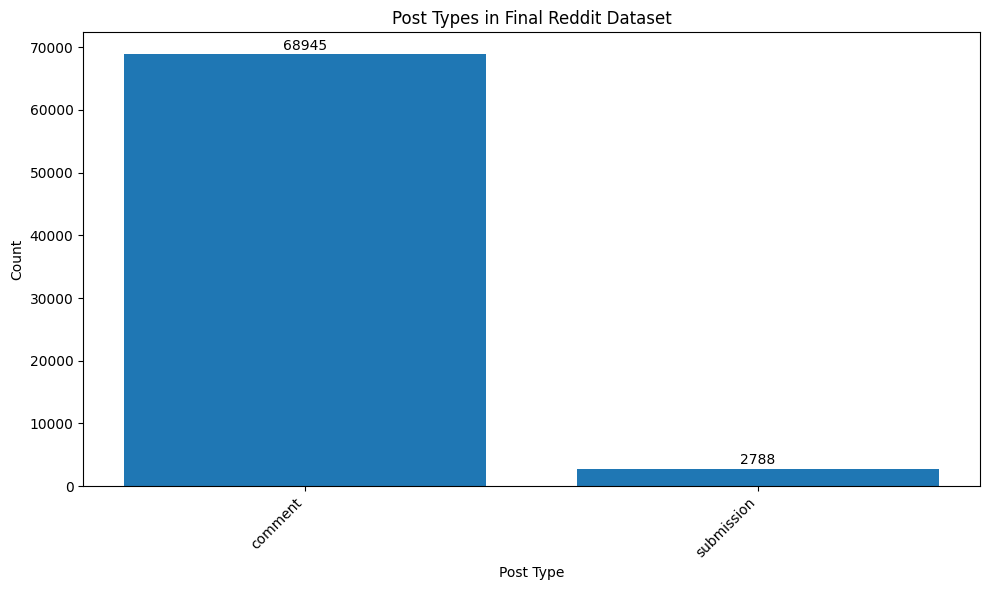

In [27]:
# visualizing the post types
column_name = "post_type"
value_counts = combined_reddit_df[column_name].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(value_counts.index, value_counts.values)
for bar in bars:
    height = bar.get_height()

    ax.annotate(
        f"{height}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 1),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

ax.set_xlabel("Post Type")
ax.set_ylabel("Count")
ax.set_title("Post Types in Final Reddit Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

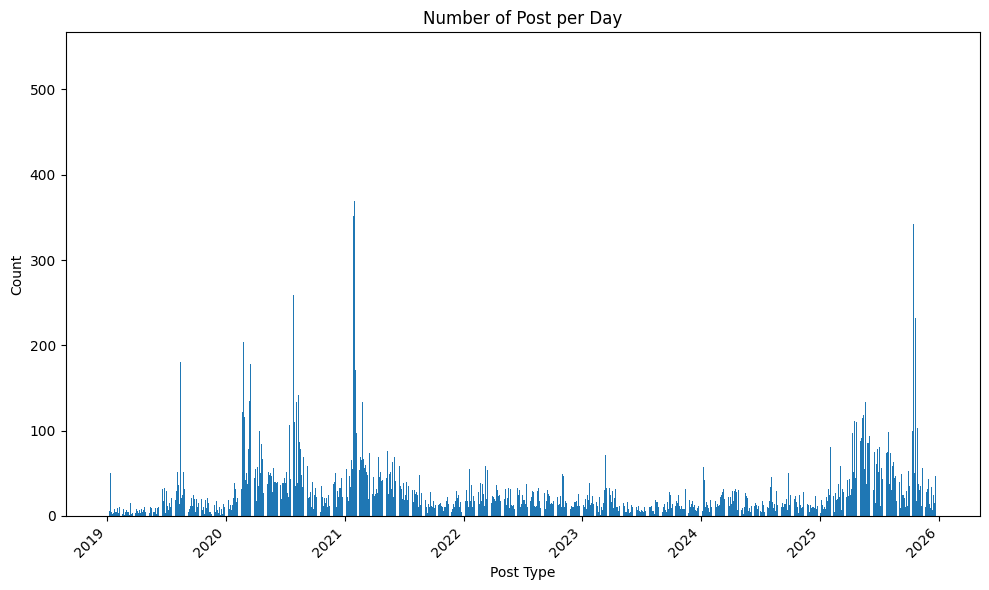

In [28]:
column_name = "created_datetime"
value_counts = combined_reddit_df[column_name].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(value_counts.index, value_counts.values)

ax.set_xlabel("Post Type")
ax.set_ylabel("Count")
ax.set_title("Number of Post per Day")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

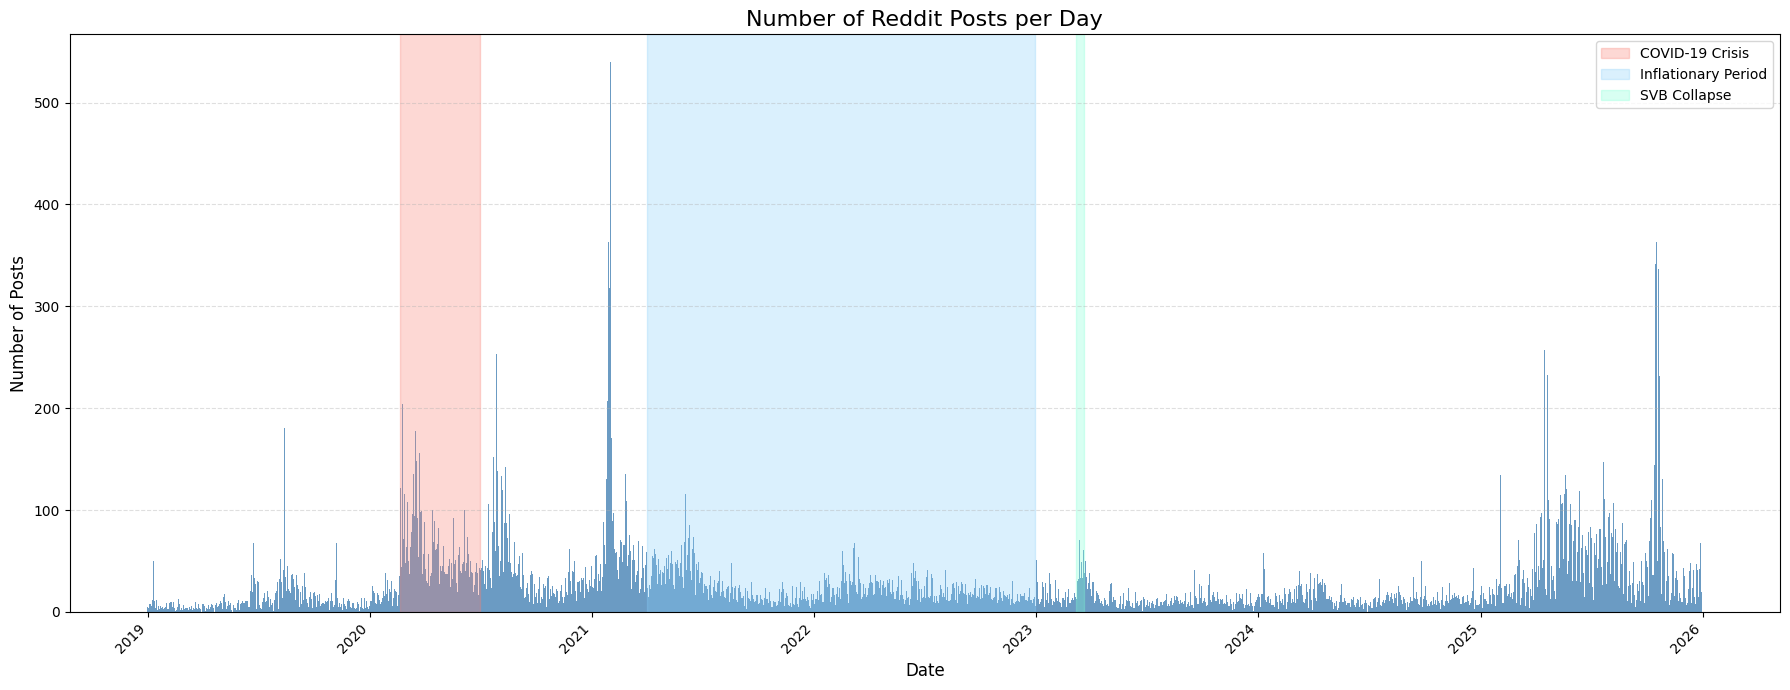

In [29]:
combined_reddit_df[column_name] = pd.to_datetime(combined_reddit_df[column_name])

value_counts = (
    combined_reddit_df[column_name]
    .dt.date
    .value_counts()
    .sort_index()
)
value_counts.index = pd.to_datetime(value_counts.index)

crisis_periods = [
    ("COVID-19 Crisis", "2020-02-20", "2020-06-30"),
    ("Inflationary Period", "2021-04-01", "2022-12-31"),
    ("SVB Collapse", "2023-03-08", "2023-03-20"),
]

fig, ax = plt.subplots(figsize=(18, 7))
ax.bar(
    value_counts.index,
    value_counts.values,
    color="steelblue",
    width=1.0,
    alpha=0.8
)
colors = ["salmon", "lightskyblue", "aquamarine"]
for (label, start, end), color in zip(crisis_periods, colors):
    ax.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color=color,
        alpha=0.3,
        label=label
    )
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Number of Posts", fontsize=12)
ax.set_title("Number of Reddit Posts per Day", fontsize=16)
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

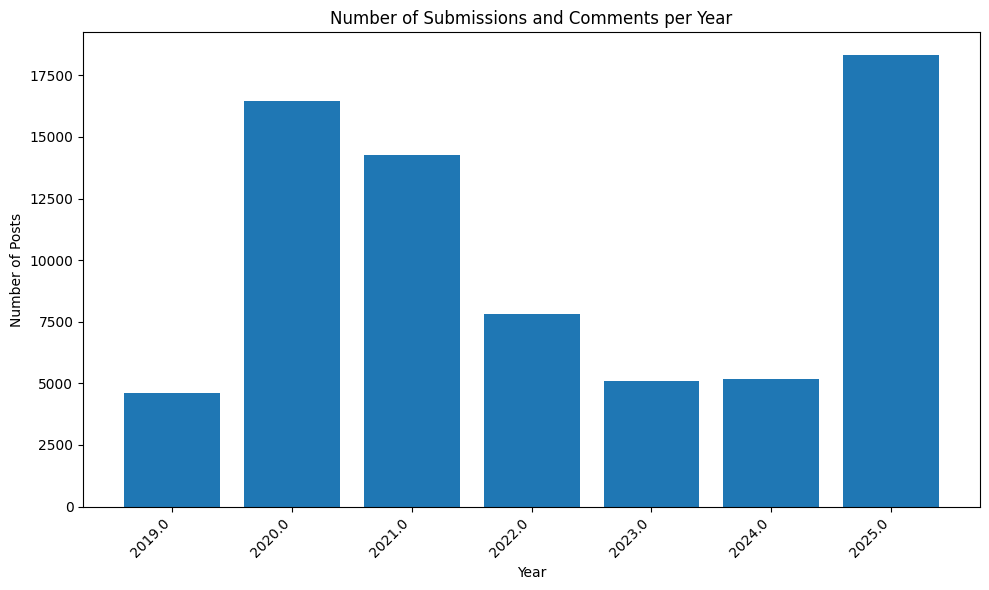

In [30]:
# visualizing the number of submissions and comments in each year
combined_reddit_df["created_datetime"] = pd.to_datetime(
    combined_reddit_df["created_datetime"]
)
combined_reddit_df["year"] = (
    combined_reddit_df["created_datetime"]
    .dt.year
)

value_counts = (
    combined_reddit_df["year"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    value_counts.index.astype(str),
    value_counts.values
)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Posts")
ax.set_title(
    "Number of Submissions and Comments per Year"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [31]:
combined_reddit_df = combined_reddit_df.drop(columns={"year"})

## 3. Data Preprocessing

#### 3.1 Combining the Title and Text Columns

In [32]:
# combining the text and the title columns
combined_reddit_df["combined_text"] = combined_reddit_df.apply(
    lambda row: row["text"]
    if pd.isna(row["title"])
    else f"{row['title']} {row['text']}",
    axis=1
)
combined_reddit_df.head(10)

,Unnamed: 0.1,post_type,title,text,created_datetime,combined_text
0,247927,comment,NaN,Never. Delete this post now. Before they find ...,2019-01-01,Never. Delete this post now. Before they find ...
1,247938,comment,NaN,Also the whole robinhood gold thing,2019-01-01,Also the whole robinhood gold thing
2,247934,comment,NaN,Shitty late night infomercials have given prec...,2019-01-01,Shitty late night infomercials have given prec...
3,247926,comment,NaN,"gtfo SEC. If Goldman does it's ""good relations...",2019-01-01,"gtfo SEC. If Goldman does it's ""good relations..."
4,247939,comment,NaN,Thinking of buying some OTM GDX calls tomorrow...,2019-01-01,Thinking of buying some OTM GDX calls tomorrow...
5,247966,comment,NaN,What are good stocks to hold or short during a...,2019-01-02,What are good stocks to hold or short during a...
6,247982,comment,NaN,"&gt; It's about the ""Hit Product"" in 2019 CBD....",2019-01-02,"&gt; It's about the ""Hit Product"" in 2019 CBD...."
7,247961,comment,NaN,Gold and Dollar are both up. This price action...,2019-01-02,Gold and Dollar are both up. This price action...
8,247944,comment,NaN,One oz of gold can be turned into about 100sq ...,2019-01-02,One oz of gold can be turned into about 100sq ...
9,247998,comment,NaN,Just woke my gf up laughing in bed. If this is...,2019-01-03,Just woke my gf up laughing in bed. If this is...


#### 3.2 Extracting the Submission and Comments With More Than 10 and Less Than 300 Words

In [33]:
def word_count(text):
    """Function that counts words in a given text, treating NaN as 0 words."""
    if pd.isna(text):
        return 0
    return len(str(text).split())

combined_reddit_df["title_word_count"] = combined_reddit_df["combined_text"].apply(word_count)

# keeping rows where the combined text is between 5 and 300 words 
filtered_reddit_df = combined_reddit_df[
    (
        (
            combined_reddit_df["combined_text"].isna()
        ) |
        (
            (combined_reddit_df["title_word_count"] >= 10) &
            (combined_reddit_df["title_word_count"] <= 300)
        )
    )
]

print(f"Original rows: {len(combined_reddit_df)}")
print(f"Filtered rows: {len(filtered_reddit_df)}")

Original rows: 71740
Filtered rows: 52815


In [34]:
filtered_reddit_df

,Unnamed: 0.1,post_type,title,text,created_datetime,combined_text,title_word_count
0,247927,comment,NaN,Never. Delete this post now. Before they find ...,2019-01-01,Never. Delete this post now. Before they find ...,41
2,247934,comment,NaN,Shitty late night infomercials have given prec...,2019-01-01,Shitty late night infomercials have given prec...,100
3,247926,comment,NaN,"gtfo SEC. If Goldman does it's ""good relations...",2019-01-01,"gtfo SEC. If Goldman does it's ""good relations...",17
4,247939,comment,NaN,Thinking of buying some OTM GDX calls tomorrow...,2019-01-01,Thinking of buying some OTM GDX calls tomorrow...,33
5,247966,comment,NaN,What are good stocks to hold or short during a...,2019-01-02,What are good stocks to hold or short during a...,19
...,...,...,...,...,...,...,...
71735,$GOLD,NaN,NaN,NaN,NaT,NaN,0
71736,$FTS,NaN,NaN,NaN,NaT,NaN,0
71737,$CTSH,NaN,NaN,NaN,NaT,NaN,0
71738,$TTEK,NaN,NaN,NaN,NaT,NaN,0


#### 3.3 Extracting Submissions and Comments Based on Specified Patterns

In [35]:
# sentiment patterns to INCLUDE
sentiment_patterns = [
    r"\bi feel\b",
    r"\bi am feeling\b",
    r"\bi'm feeling\b",
    r"\bim feeling\b",
    r"\bi dont feel\b",
    r"\bi don't feel\b",
    r"\bi am\b",
    r"\bi'm\b",
    r"\bim\b",
    r"\bmakes me\b",
    r"\bi think\b",
    r"\bi believe\b",
    r"\bi love\b",
    r"\bi hate\b",
    r"\bi like\b",
    r"\bi dislike\b",
    r"\bi enjoy\b",
    r"\bi prefer\b",
    r"\bi fear\b",
    r"\bi worry\b",
    r"\bi hope\b",
    r"\bi expect\b",

    # trading sentiment
    r"\bi'm bullish\b",
    r"\bi'm bearish\b",
    r"\bi am bullish\b",
    r"\bi am bearish\b",
    r"\bfeels bullish\b",
    r"\bfeels bearish\b",
    r"\blooks bullish\b",
    r"\blooks bearish\b",
    r"\bthis scares me\b",
    r"\bthis worries me\b",
    r"\bthis excites me\b",

    # market language
    r"\bbearish\b",
    r"\bbullish\b",
    r"\bbuying\b",
    r"\bselling\b",
    r"\blong\b",
    r"\bshort\b",
    r"precious metals\b",
    r"metals\b",

    # gold / commodity related
    r"\bminers\b",
    r"\bmining\b",
    r"\bgold\b",
    r"\bbullion\b",
    r"\bgld\b",
    r"\bslv\b",
    r"\bgoldsqueeze\b",
    r"\binflation\b",
    r"\bhedge\b",
    r"\bsafe haven\b",
    r"\bstore of value\b",
    r"\bcommodity\b",
    r"\bcommodities\b",
    r"\bfiat\b",
    r"\bcurrency debasement\b",
    r"\bcentral banks?\b",
    r"\breal yields?\b",
    r"\bxau\b",
    r"\bounces?\b",
    r"\buy bars\b",
]

# sentiment patterns to EXCLUDE
exclude_patterns = [
    r"\bgoldman\b",
    r"\bgolden\b",
    r"\bgoldie\b",
    r"\bheart of gold\b",
    r"\bgold digger\b",
    r"\bgold standard games\b",
    r"\bgolden retriever\b",
    r"\bgolden state\b",
    r"\bgold medal\b",
    r"\bgold award\b",
    r"\breddit gold\b",

]

# combining title and text for regex search
filtered_reddit_df["combined_text"] = (
    filtered_reddit_df["title"].fillna("") + " " +
    filtered_reddit_df["text"].fillna("")
)

# regex combination
combined_pattern = "|".join(sentiment_patterns)
exclude_pattern = "|".join(exclude_patterns)

# keeping relevant sentiment rows
filtered_sentiment_df = filtered_reddit_df[
    filtered_reddit_df["combined_text"]
    .str.contains(combined_pattern, case=False, na=False, regex=True)
]

# removing unrelated matches
filtered_sentiment_df = filtered_sentiment_df[
    ~filtered_sentiment_df["combined_text"]
    .str.contains(exclude_pattern, case=False, na=False, regex=True)
]

# removing URLs
filtered_sentiment_df["combined_text"] = (
    filtered_sentiment_df["combined_text"]
    .str.replace(
        r"http\S+|www\S+|https\S+",
        "",
        regex=True
    )
)


filtered_sentiment_df = filtered_sentiment_df.drop_duplicates(
    subset=["combined_text"]
)

print(f"Original rows: {len(filtered_reddit_df)}")
print(f"Rows with explicit sentiment expressions: {len(filtered_sentiment_df)}")

filtered_sentiment_df

/var/folders/04/65nvv_ld27j0dndh3hxb04hc0000gn/T/ipykernel_49263/1738861714.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_reddit_df["combined_text"] = (


Original rows: 52815
Rows with explicit sentiment expressions: 37913


,Unnamed: 0.1,post_type,title,text,created_datetime,combined_text,title_word_count
0,247927,comment,NaN,Never. Delete this post now. Before they find ...,2019-01-01,Never. Delete this post now. Before they find...,41
2,247934,comment,NaN,Shitty late night infomercials have given prec...,2019-01-01,Shitty late night infomercials have given pre...,100
4,247939,comment,NaN,Thinking of buying some OTM GDX calls tomorrow...,2019-01-01,Thinking of buying some OTM GDX calls tomorro...,33
5,247966,comment,NaN,What are good stocks to hold or short during a...,2019-01-02,What are good stocks to hold or short during ...,19
6,247982,comment,NaN,"&gt; It's about the ""Hit Product"" in 2019 CBD....",2019-01-02,"&gt; It's about the ""Hit Product"" in 2019 CBD...",49
...,...,...,...,...,...,...,...
71727,187739,comment,NaN,Damn that's crazy how do you lose money on sil...,2025-12-31,Damn that's crazy how do you lose money on si...,19
71729,187773,comment,NaN,If you buy calls or puts on slv or gld you wil...,2025-12-31,If you buy calls or puts on slv or gld you wi...,31
71730,187820,comment,NaN,"To me, all the confluences shows that precious...",2025-12-31,"To me, all the confluences shows that preciou...",15
71731,187831,comment,NaN,"But seriously, SLV is easy to day trade becaus...",2025-12-31,"But seriously, SLV is easy to day trade becau...",15


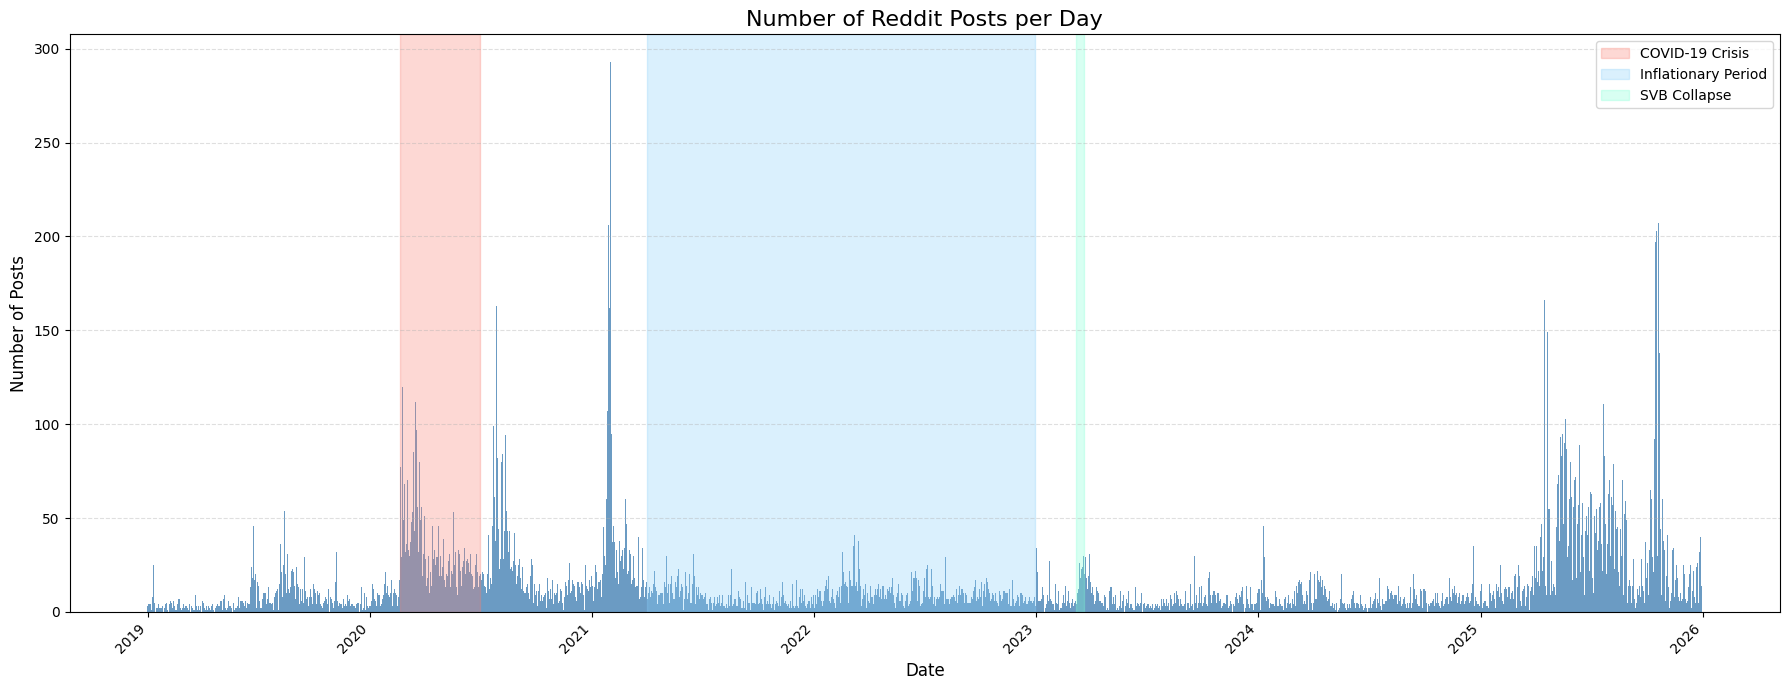

In [36]:
filtered_sentiment_df["created_datetime"] = pd.to_datetime(filtered_sentiment_df["created_datetime"])

value_counts = (
    filtered_sentiment_df["created_datetime"]
    .dt.date
    .value_counts()
    .sort_index()
)
value_counts.index = pd.to_datetime(value_counts.index)

crisis_periods = [
    ("COVID-19 Crisis", "2020-02-20", "2020-06-30"),
    ("Inflationary Period", "2021-04-01", "2022-12-31"),
    ("SVB Collapse", "2023-03-08", "2023-03-20"),
]

fig, ax = plt.subplots(figsize=(18, 7))
ax.bar(
    value_counts.index,
    value_counts.values,
    color="steelblue",
    width=1.0,
    alpha=0.8
)
colors = ["salmon", "lightskyblue", "aquamarine"]
for (label, start, end), color in zip(crisis_periods, colors):
    ax.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color=color,
        alpha=0.3,
        label=label
    )
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Number of Posts", fontsize=12)
ax.set_title("Number of Reddit Posts per Day", fontsize=16)
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

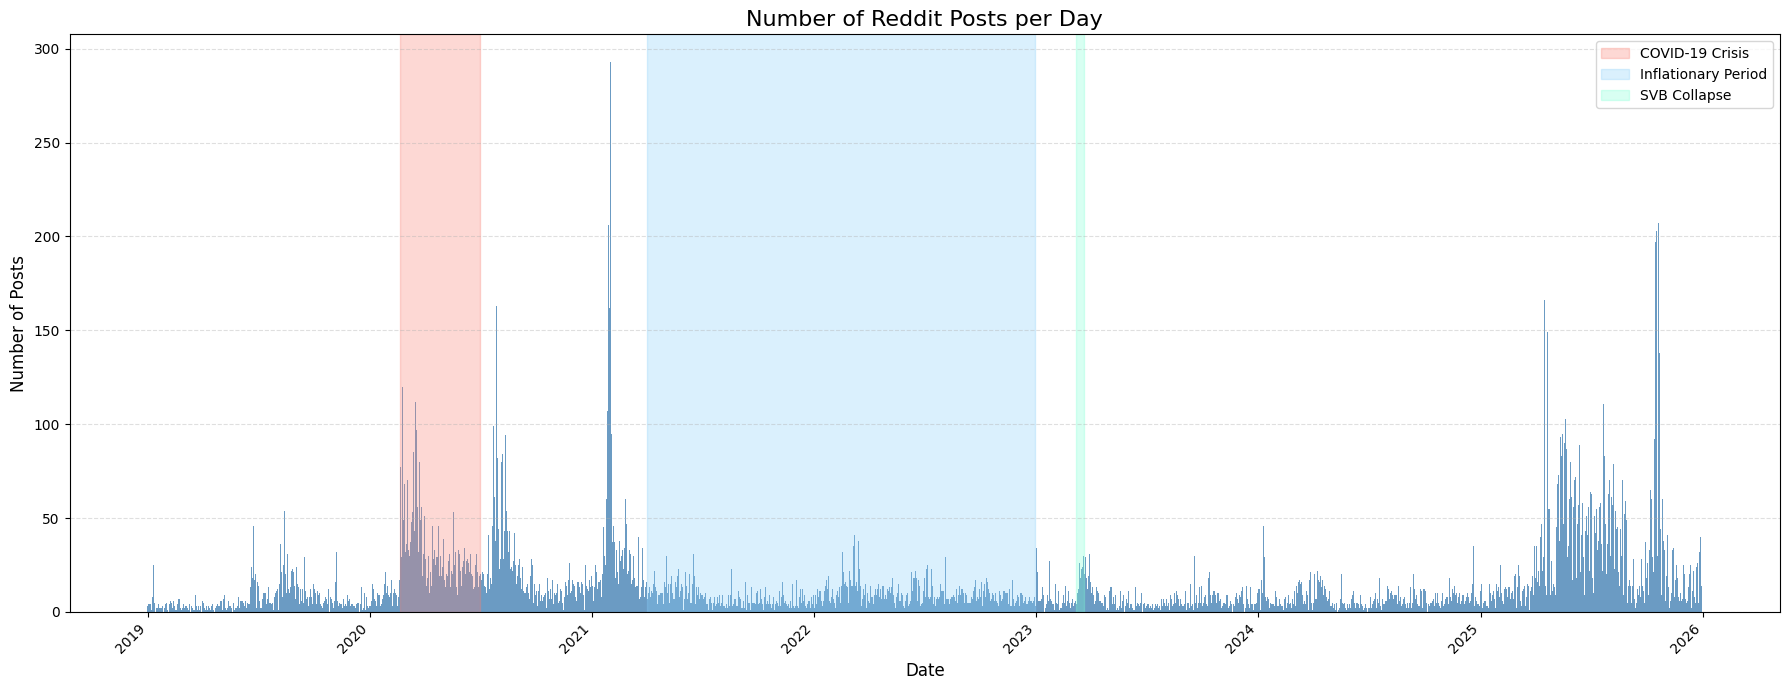

In [37]:
filtered_sentiment_df["created_datetime"] = pd.to_datetime(filtered_sentiment_df["created_datetime"])

value_counts = (
    filtered_sentiment_df["created_datetime"]
    .dt.date
    .value_counts()
    .sort_index()
)
value_counts.index = pd.to_datetime(value_counts.index)

crisis_periods = [
    ("COVID-19 Crisis", "2020-02-20", "2020-06-30"),
    ("Inflationary Period", "2021-04-01", "2022-12-31"),
    ("SVB Collapse", "2023-03-08", "2023-03-20"),
]

fig, ax = plt.subplots(figsize=(18, 7))
ax.bar(
    value_counts.index,
    value_counts.values,
    color="steelblue",
    width=1.0,
    alpha=0.8
)
colors = ["salmon", "lightskyblue", "aquamarine"]
for (label, start, end), color in zip(crisis_periods, colors):
    ax.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color=color,
        alpha=0.3,
        label=label
    )
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Number of Posts", fontsize=12)
ax.set_title("Number of Reddit Posts per Day", fontsize=16)
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [38]:
filtered_sentiment_df

,Unnamed: 0.1,post_type,title,text,created_datetime,combined_text,title_word_count
0,247927,comment,NaN,Never. Delete this post now. Before they find ...,2019-01-01,Never. Delete this post now. Before they find...,41
2,247934,comment,NaN,Shitty late night infomercials have given prec...,2019-01-01,Shitty late night infomercials have given pre...,100
4,247939,comment,NaN,Thinking of buying some OTM GDX calls tomorrow...,2019-01-01,Thinking of buying some OTM GDX calls tomorro...,33
5,247966,comment,NaN,What are good stocks to hold or short during a...,2019-01-02,What are good stocks to hold or short during ...,19
6,247982,comment,NaN,"&gt; It's about the ""Hit Product"" in 2019 CBD....",2019-01-02,"&gt; It's about the ""Hit Product"" in 2019 CBD...",49
...,...,...,...,...,...,...,...
71727,187739,comment,NaN,Damn that's crazy how do you lose money on sil...,2025-12-31,Damn that's crazy how do you lose money on si...,19
71729,187773,comment,NaN,If you buy calls or puts on slv or gld you wil...,2025-12-31,If you buy calls or puts on slv or gld you wi...,31
71730,187820,comment,NaN,"To me, all the confluences shows that precious...",2025-12-31,"To me, all the confluences shows that preciou...",15
71731,187831,comment,NaN,"But seriously, SLV is easy to day trade becaus...",2025-12-31,"But seriously, SLV is easy to day trade becau...",15


In [39]:
filtered_sentiment_df = filtered_sentiment_df.drop(columns={"title", "text", "title_word_count"})

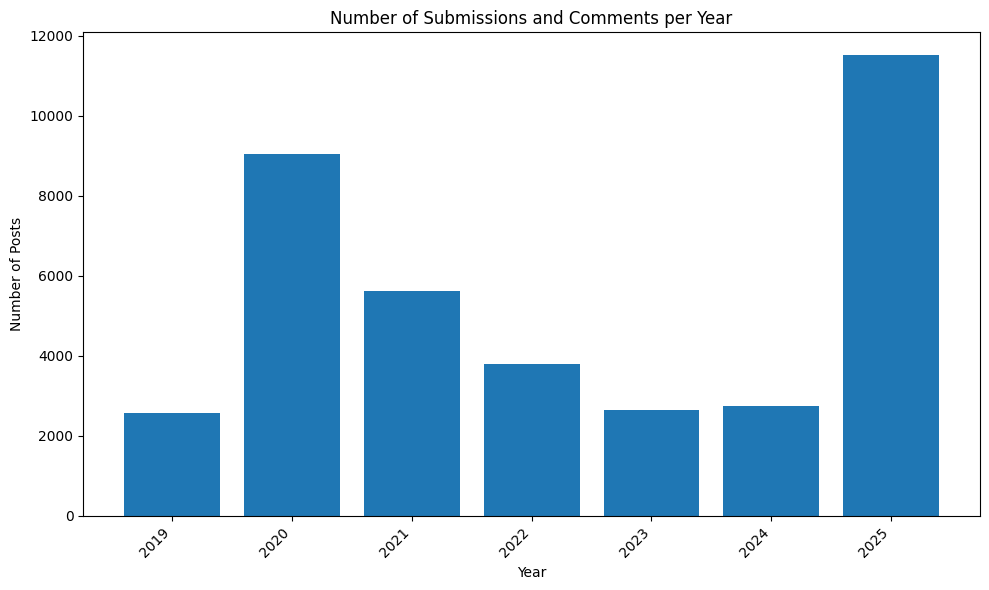

In [40]:
# visualizing the number of submissions and comments in each year
filtered_sentiment_df["created_datetime"] = pd.to_datetime(
    filtered_reddit_df["created_datetime"]
)
filtered_sentiment_df["year"] = (
    filtered_sentiment_df["created_datetime"]
    .dt.year
)

value_counts = (
    filtered_sentiment_df["year"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    value_counts.index.astype(str),
    value_counts.values
)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Posts")
ax.set_title(
    "Number of Submissions and Comments per Year"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Applying Sentiment Analysis

#### 4.1 VADER

In [41]:
# downloading VADER lexicon
nltk.download("vader_lexicon")

# initializing VADER
sia = SentimentIntensityAnalyzer()

filtered_sentiment_df["created_datetime"] = pd.to_datetime(
    filtered_sentiment_df["created_datetime"]
)

# getting sentiment score for each row
filtered_sentiment_df["sentiment_score"] = filtered_sentiment_df["combined_text"].apply(
    lambda text: sia.polarity_scores(str(text))["compound"]
)

# extracting the date only
filtered_sentiment_df["date"] = filtered_sentiment_df["created_datetime"].dt.date

# Aggregate:
# - average sentiment per day
# - number of gold-related posts/comments per day
daily_vader_sentiment = (
    filtered_sentiment_df
    .groupby("date")
    .agg(
        average_daily_sentiment=("sentiment_score", "mean"),
        gold_related_posts=("combined_text", "count")
    )
    .reset_index()
)

daily_vader_sentiment = daily_vader_sentiment.sort_values("date")
daily_vader_sentiment.head()


[nltk_data] Error loading vader_lexicon: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>


,date,average_daily_sentiment,gold_related_posts
0,2019-01-01,-0.041567,3
1,2019-01-02,0.443150,4
2,2019-01-03,0.312830,10
3,2019-01-04,0.210750,4
4,2019-01-05,0.164333,3


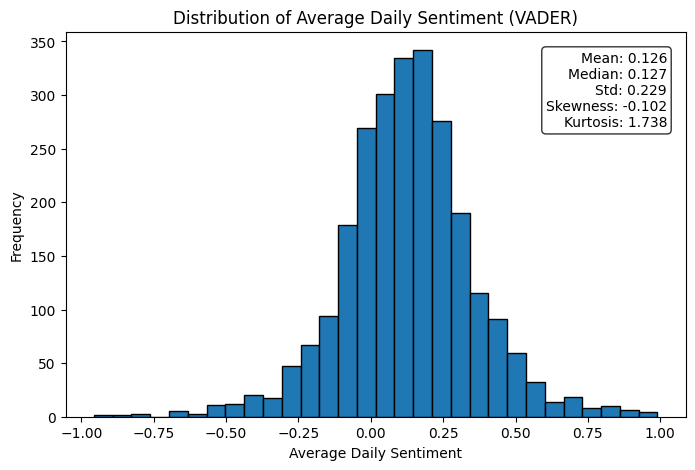

In [42]:
# plotting the distribution of the sentiment data

# sentiment series
sent = daily_vader_sentiment["average_daily_sentiment"].dropna()

# calculate statistics
mean_val = sent.mean()
median_val = sent.median()
std_val = sent.std()
skew_val = skew(sent)
kurt_val = kurtosis(sent)   # excess kurtosis (0 = normal)

# plot histogram
plt.figure(figsize=(8,5))
plt.hist(sent, bins=30, edgecolor="black")

plt.xlabel("Average Daily Sentiment")
plt.ylabel("Frequency")
plt.title("Distribution of Average Daily Sentiment (VADER)")

# statistics box
stats_text = (
    f"Mean: {mean_val:.3f}\n"
    f"Median: {median_val:.3f}\n"
    f"Std: {std_val:.3f}\n"
    f"Skewness: {skew_val:.3f}\n"
    f"Kurtosis: {kurt_val:.3f}"
)

plt.text(
    0.97, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.show()

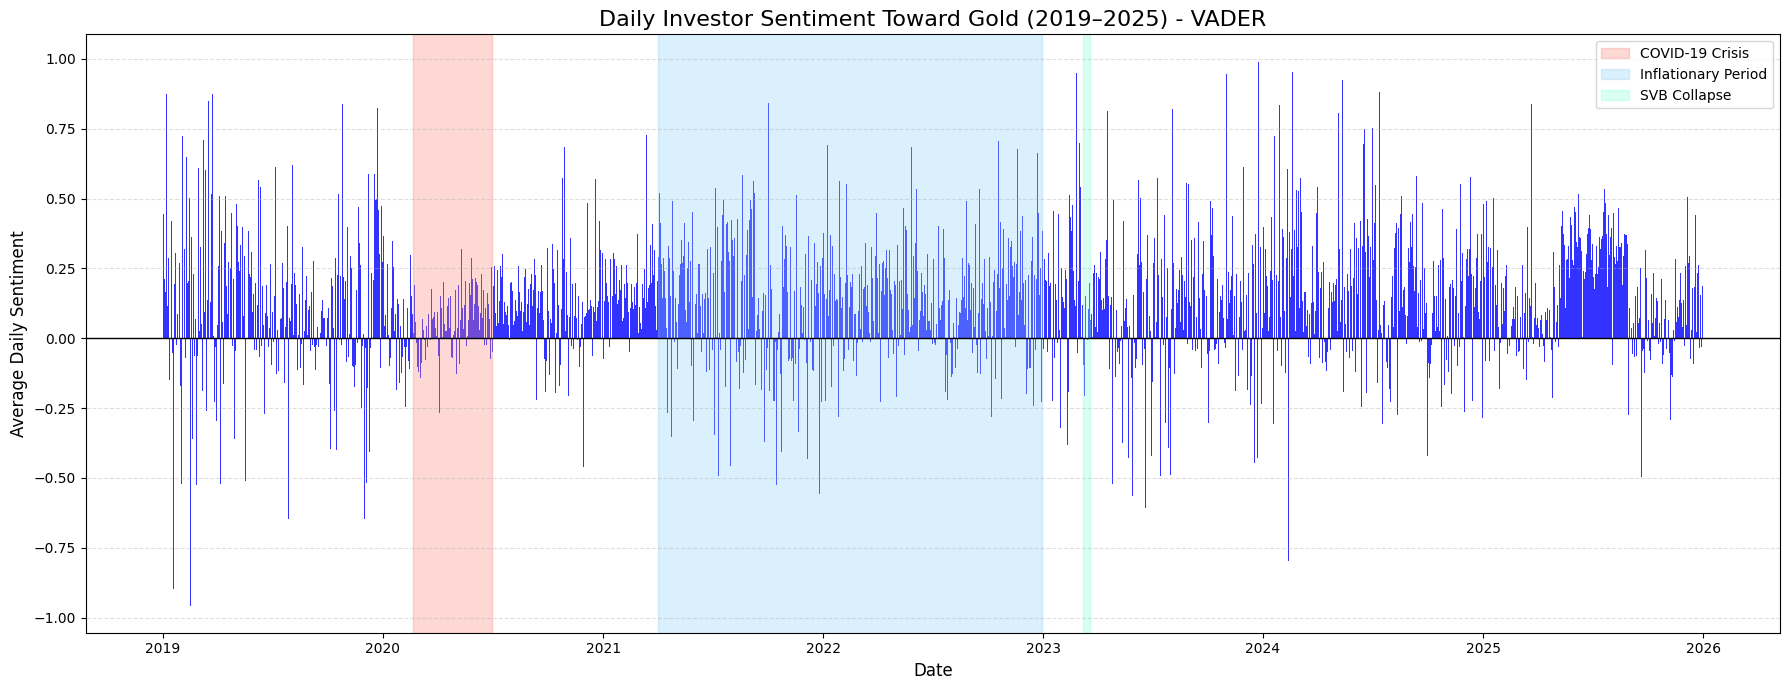

In [43]:
df = daily_vader_sentiment
df["date"] = pd.to_datetime(df["date"])

# Crisis periods
crisis_periods = [
    ("COVID-19 Crisis", "2020-02-20", "2020-06-30"),
    ("Inflationary Period", "2021-04-01", "2022-12-31"),
    ("SVB Collapse", "2023-03-08", "2023-03-20"),
]
fig, ax = plt.subplots(figsize=(18, 7))
ax.bar(
    df["date"],
    df["average_daily_sentiment"],
    color="blue",
    width=1.0,
    alpha=0.8
)
colors = ["salmon", "lightskyblue", "aquamarine"]
for (label, start, end), color in zip(crisis_periods, colors):
    ax.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color=color,
        alpha=0.3,
        label=label
    )
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Daily Investor Sentiment Toward Gold (2019–2025) - VADER", fontsize=16)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Average Daily Sentiment", fontsize=12)
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

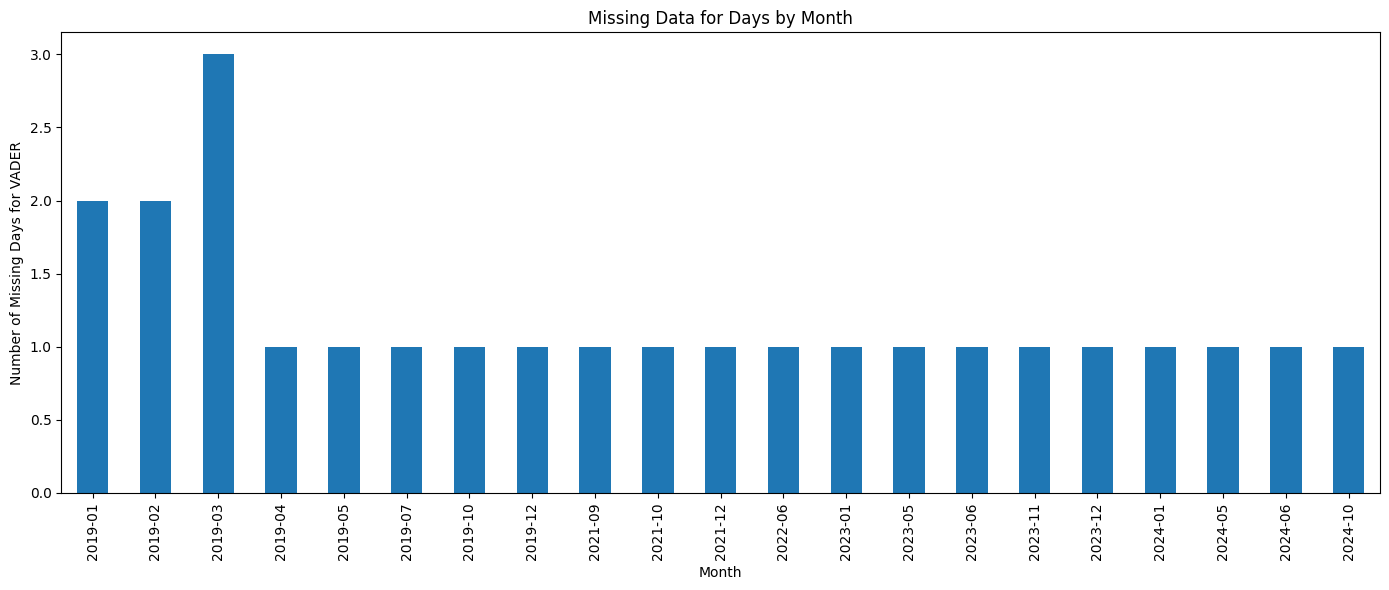

In [44]:
# extracting the daily dates
daily_vader_sentiment["date"] = pd.to_datetime(
    daily_vader_sentiment["date"],
    errors="coerce"
)

daily_vader_sentiment["date"] = (
    daily_vader_sentiment["date"].dt.date
)

full_dates = pd.date_range(
    start=daily_vader_sentiment["date"].min(),
    end=daily_vader_sentiment["date"].max(),
    freq="D"
)

# existing dates
existing_dates = pd.to_datetime(
    daily_vader_sentiment["date"].dropna().unique()
)

# missing dates
missing_dates = sorted(
    set(full_dates) - set(existing_dates)
)

# converting missing dates to dataframe
missing_df = pd.DataFrame({
    "missing_date": pd.to_datetime(missing_dates)
})

# handling if there are no missing values
if missing_df.empty:

    print("No missing dates found.")

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.text(
        0.5,
        0.5,
        "No Missing Dates",
        ha="center",
        va="center",
        fontsize=16
    )

    ax.set_axis_off()

    plt.title("Missing Data for Days by Month")
    plt.show()

else:

    # extracting month period
    missing_df["month"] = (
        missing_df["missing_date"]
        .dt.to_period("M")
    )

    # counting missing days per month
    monthly_missing_counts = (
        missing_df["month"]
        .value_counts()
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(14, 6))

    monthly_missing_counts.plot(
        kind="bar",
        ax=ax
    )

    ax.set_xlabel("Month")
    ax.set_ylabel(
        "Number of Missing Days for VADER"
    )

    ax.set_title(
        "Missing Data for Days by Month"
    )

    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

In [45]:
daily_vader_sentiment

,date,average_daily_sentiment,gold_related_posts
0,2019-01-01,-0.041567,3
1,2019-01-02,0.443150,4
2,2019-01-03,0.312830,10
3,2019-01-04,0.210750,4
4,2019-01-05,0.164333,3
...,...,...,...
2527,2025-12-27,0.153381,32
2528,2025-12-28,0.193967,24
2529,2025-12-29,-0.030998,40
2530,2025-12-30,0.020379,14


In [46]:
daily_vader_sentiment["log_gold_posts"] = np.log(daily_vader_sentiment["gold_related_posts"])
daily_vader_sentiment

,date,average_daily_sentiment,gold_related_posts,log_gold_posts
0,2019-01-01,-0.041567,3,1.098612
1,2019-01-02,0.443150,4,1.386294
2,2019-01-03,0.312830,10,2.302585
3,2019-01-04,0.210750,4,1.386294
4,2019-01-05,0.164333,3,1.098612
...,...,...,...,...
2527,2025-12-27,0.153381,32,3.465736
2528,2025-12-28,0.193967,24,3.178054
2529,2025-12-29,-0.030998,40,3.688879
2530,2025-12-30,0.020379,14,2.639057


#### 4.1.1 Create Weighted Sentiment (JUST FOR EXAMINATION)

In [47]:
# weighted sentiment
daily_vader_sentiment["weighted_sentiment"] = (
    daily_vader_sentiment["average_daily_sentiment"]
    * daily_vader_sentiment["log_gold_posts"]
)

# # standardizing sentiment
# daily_vader_sentiment["sentiment_z"] = (
#     daily_vader_sentiment["average_daily_sentiment"]
#     - daily_vader_sentiment["average_daily_sentiment"].mean()
# ) / daily_vader_sentiment["average_daily_sentiment"].std()

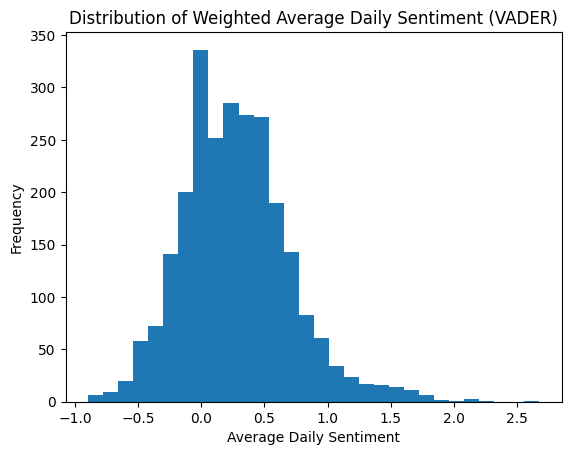

In [48]:
# plotting the distribution
plt.hist(daily_vader_sentiment["weighted_sentiment"], bins=30)
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Frequency")
plt.title("Distribution of Weighted Average Daily Sentiment (VADER)")
plt.show()

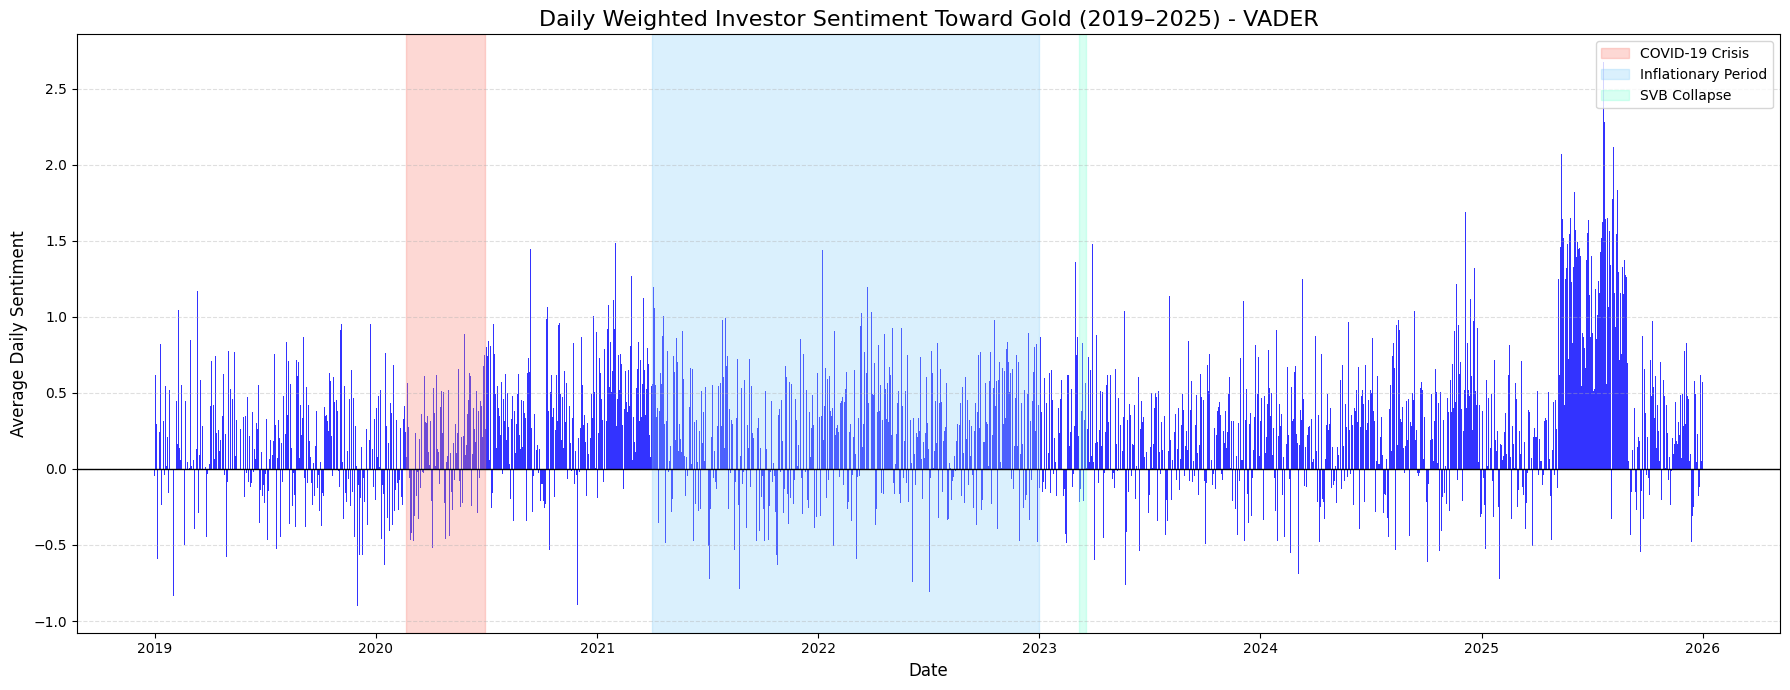

In [49]:
df = daily_vader_sentiment
df["date"] = pd.to_datetime(df["date"])

# crisis periods
crisis_periods = [
    ("COVID-19 Crisis", "2020-02-20", "2020-06-30"),
    ("Inflationary Period", "2021-04-01", "2022-12-31"),
    ("SVB Collapse", "2023-03-08", "2023-03-20"),
]

fig, ax = plt.subplots(figsize=(18, 7))
ax.bar(
    df["date"],
    df["weighted_sentiment"],
    color="blue",
    width=1.0,
    alpha=0.8
)
colors = ["salmon", "lightskyblue", "aquamarine"]
for (label, start, end), color in zip(crisis_periods, colors):
    ax.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color=color,
        alpha=0.3,
        label=label
    )
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Daily Weighted Investor Sentiment Toward Gold (2019–2025) - VADER", fontsize=16)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Average Daily Sentiment", fontsize=12)
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

#### 4.2 FinBERT

In [50]:
# defining the finbert pipeline
finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    top_k=None
)

# ensure datetime format
filtered_sentiment_df["created_datetime"] = pd.to_datetime(
    filtered_sentiment_df["created_datetime"]
)

# retrieving finbert output
def get_raw_finbert_output(text):
    try:
        text = str(text)

        # handling of FinBERT token limit
        result = finbert(
            text,
            truncation=True,
            max_length=512
        )

        return result

    except Exception as e:
        return np.nan

tqdm.pandas()

# raw FinBERT output
filtered_sentiment_df["raw_finbert_output"] = (
    filtered_sentiment_df["combined_text"]
    .progress_apply(get_raw_finbert_output)
)

finbert_raw_output_df = filtered_sentiment_df[
    [
        "created_datetime",
        "combined_text",
        "raw_finbert_output"
    ]
]

print(finbert_raw_output_df.head())

# extracting negative and positive sentiment
def extract_finbert_scores(raw_output):
    try:
        # structure:
        # [[{...}, {...}, {...}]]

        scores_list = raw_output[0]

        scores = {
            item["label"].lower(): item["score"]
            for item in scores_list
        }

        positive = scores.get("positive", 0)
        negative = scores.get("negative", 0)
        neutral = scores.get("neutral", 0)

        # dominant sentiment
        sentiment = max(scores, key=scores.get)

        # continuous sentiment score
        sentiment_score = positive - negative

        return pd.Series([
            positive,
            negative,
            neutral,
            sentiment,
            sentiment_score
        ])

    except Exception as e:
        return pd.Series([np.nan, np.nan, np.nan, np.nan, np.nan])

# separate dataframe for processed sentiment
finbert_processed_df = filtered_sentiment_df.copy()

finbert_processed_df[
    [
        "positive",
        "negative",
        "neutral",
        "sentiment",
        "sentiment_score"
    ]
] = finbert_processed_df["raw_finbert_output"].apply(
    extract_finbert_scores
)

# create date column
finbert_processed_df["date"] = (
    finbert_processed_df["created_datetime"].dt.date
)

# final post output
finbert_output_df = finbert_processed_df[
    [
        "created_datetime",
        "combined_text",
        "positive",
        "negative",
        "neutral",
        "sentiment",
        "sentiment_score"
    ]
]

print(finbert_output_df.head())

# daily aggregation dataframe
daily_finbert_sentiment = (
    finbert_processed_df
    .groupby("date")
    .agg(
        average_daily_sentiment=("sentiment_score", "mean"),
        gold_related_posts=("combined_text", "count")
    )
    .reset_index()
)

# sort by date
daily_finbert_sentiment = (
    daily_finbert_sentiment
    .sort_values("date")
)

print(daily_finbert_sentiment.head())

100%|██████████| 37913/37913 [05:29<00:00, 115.11it/s]


  created_datetime                                      combined_text  \
0       2019-01-01   Never. Delete this post now. Before they find...   
2       2019-01-01   Shitty late night infomercials have given pre...   
4       2019-01-01   Thinking of buying some OTM GDX calls tomorro...   
5       2019-01-02   What are good stocks to hold or short during ...   
6       2019-01-02   &gt; It's about the "Hit Product" in 2019 CBD...   

                                  raw_finbert_output  
0  [[{'label': 'neutral', 'score': 0.782629489898...  
2  [[{'label': 'negative', 'score': 0.66472411155...  
4  [[{'label': 'neutral', 'score': 0.615302860736...  
5  [[{'label': 'neutral', 'score': 0.892755627632...  
6  [[{'label': 'neutral', 'score': 0.906329333782...  
  created_datetime                                      combined_text  \
0       2019-01-01   Never. Delete this post now. Before they find...   
2       2019-01-01   Shitty late night infomercials have given pre...   
4       2019

In [51]:
finbert_output_df_pos = finbert_output_df[finbert_output_df["sentiment"]=="positive"]
finbert_output_df_pos = finbert_output_df_pos.sort_values(by="positive",ascending=False)
pd.set_option('display.max_colwidth', None)
print(finbert_output_df_pos.iloc[4]["combined_text"])

 gld 1dte atm bull spreads are up 50% since open


In [52]:
finbert_output_df_neg = finbert_output_df[finbert_output_df["sentiment"]=="negative"]
finbert_output_df_neg = finbert_output_df_neg.sort_values(by="negative",ascending=False)
pd.set_option('display.max_colwidth', None)
print(finbert_output_df_neg.iloc[2]["combined_text"])

 Two workers died and five are missing after a mud rush at a Freeport-McMoRan mine in Indonesia earlier this month.

The miner lowered its third-quarter sales estimates for copper by 4% and gold by 6% due to the incident.

Freeport-McMoRan’s stock fell 16.95% and copper futures rose 4% after the announcement, reflecting supply concerns.


/var/folders/04/65nvv_ld27j0dndh3hxb04hc0000gn/T/ipykernel_49263/3168848642.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


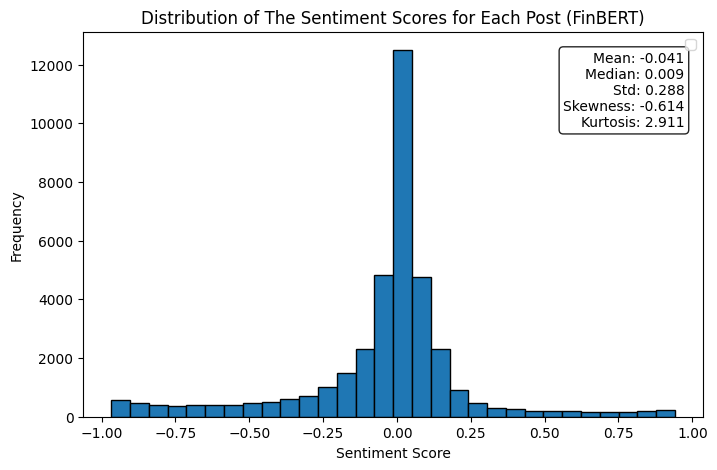

In [53]:
# sentiment series
sent = finbert_output_df["sentiment_score"].dropna()

# calculate statistics
mean_val = sent.mean()
median_val = sent.median()
std_val = sent.std()
skew_val = skew(sent)
kurt_val = kurtosis(sent)   # excess kurtosis

# plot histogram
plt.figure(figsize=(8,5))
plt.hist(sent, bins=30, edgecolor="black")


plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Distribution of The Sentiment Scores for Each Post (FinBERT)")

# statistics box
stats_text = (
    f"Mean: {mean_val:.3f}\n"
    f"Median: {median_val:.3f}\n"
    f"Std: {std_val:.3f}\n"
    f"Skewness: {skew_val:.3f}\n"
    f"Kurtosis: {kurt_val:.3f}"
)

plt.text(
    0.97, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
)

plt.legend()
plt.show()

In [54]:
finbert_output_df[finbert_output_df["sentiment_score"] < -0.5]

,created_datetime,combined_text,positive,negative,neutral,sentiment,sentiment_score
2,2019-01-01,Shitty late night infomercials have given precious metals a bad name. GLD is definitely a horrible investment though. It's written into their legal contracts that you can't actually ask for physical gold from the fund. It will tank during a currency crisis because people will pull their money out. Much better to just buy stock in miners if you can't buy physical for whatever reason (mainly for retirement accounts).\n\nI hate having to sort through gold news though. Too much misinformation in general; bearish from the wider market and bullish from goldbugs. I've got a position in silver currently regardless.,0.027007,0.664724,0.308269,negative,-0.637717
7,2019-01-02,Gold and Dollar are both up. This price action is very confusing to be honest.\n\nThe market is still hungover from NYE,0.050604,0.870223,0.079173,negative,-0.819620
12,2019-01-03,He also claims gold will lose 99 percent of its value because....,0.015195,0.906990,0.077815,negative,-0.891794
25,2019-01-04,"Yessir I appreciate it. I closed all my puts and kept my gold calls as Powell seemed to soften up. Got some cash I’m not gonna FOMO with, down 8k on the day but I’ve been down worse lmao.",0.120488,0.797684,0.081827,negative,-0.677196
143,2019-01-12,"I came to talk about the market, but all everyone wants to talk about is how this post has had like thousands of dollars spent on gold on it. \n\nA lot of us individually make and usually lose the annual salary of a grocery store clerk on a daily basis. Dropping some cash to increment a counter actually doesn't sound so bad. \n\nI guess we will talk stocks Monday.",0.015206,0.802067,0.182727,negative,-0.786861
...,...,...,...,...,...,...,...
71623,2025-12-29,Yall worse than Yukon Cornelious n here with all the SIlver n Gold in here.,0.026979,0.876471,0.096549,negative,-0.849492
71627,2025-12-29,Is it too much to ask for gold to recover 1%? You can still be down 3.5% you piece of shit. Who are the morons selling gold at a time like this??,0.014028,0.921191,0.064782,negative,-0.907163
71649,2025-12-29,"Dollar value is declining, silver following gold, industry demand for silver... I am in bro, but since \~2023",0.016623,0.919706,0.063671,negative,-0.903082
71664,2025-12-29,"Closed my Gold puts too early losing about 3k. \nBought calls after dump, minus 300$ already lol",0.033286,0.858119,0.108594,negative,-0.824833


In [55]:
daily_finbert_sentiment[daily_finbert_sentiment["average_daily_sentiment"] == 0]

,date,average_daily_sentiment,gold_related_posts


/var/folders/04/65nvv_ld27j0dndh3hxb04hc0000gn/T/ipykernel_49263/3131788825.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


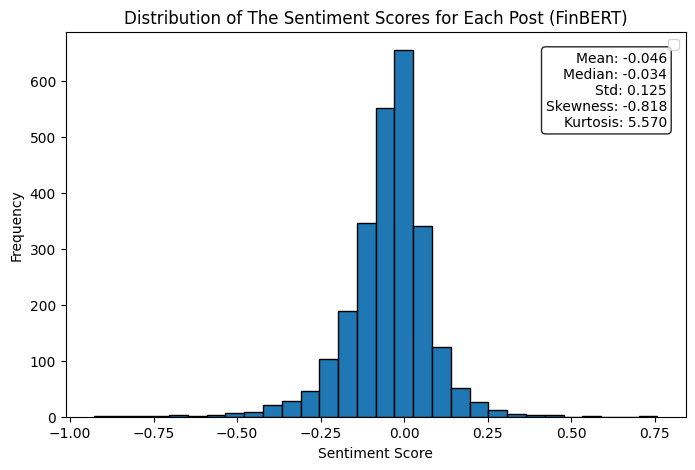

In [56]:
# sentiment series
sent = daily_finbert_sentiment["average_daily_sentiment"].dropna()

# calculate statistics
mean_val = sent.mean()
median_val = sent.median()
std_val = sent.std()
skew_val = skew(sent)
kurt_val = kurtosis(sent)   # excess kurtosis

# plot histogram
plt.figure(figsize=(8,5))
plt.hist(sent, bins=30, edgecolor="black")


plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Distribution of The Sentiment Scores for Each Post (FinBERT)")

# statistics box
stats_text = (
    f"Mean: {mean_val:.3f}\n"
    f"Median: {median_val:.3f}\n"
    f"Std: {std_val:.3f}\n"
    f"Skewness: {skew_val:.3f}\n"
    f"Kurtosis: {kurt_val:.3f}"
)

plt.text(
    0.97, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
)

plt.legend()
plt.show()

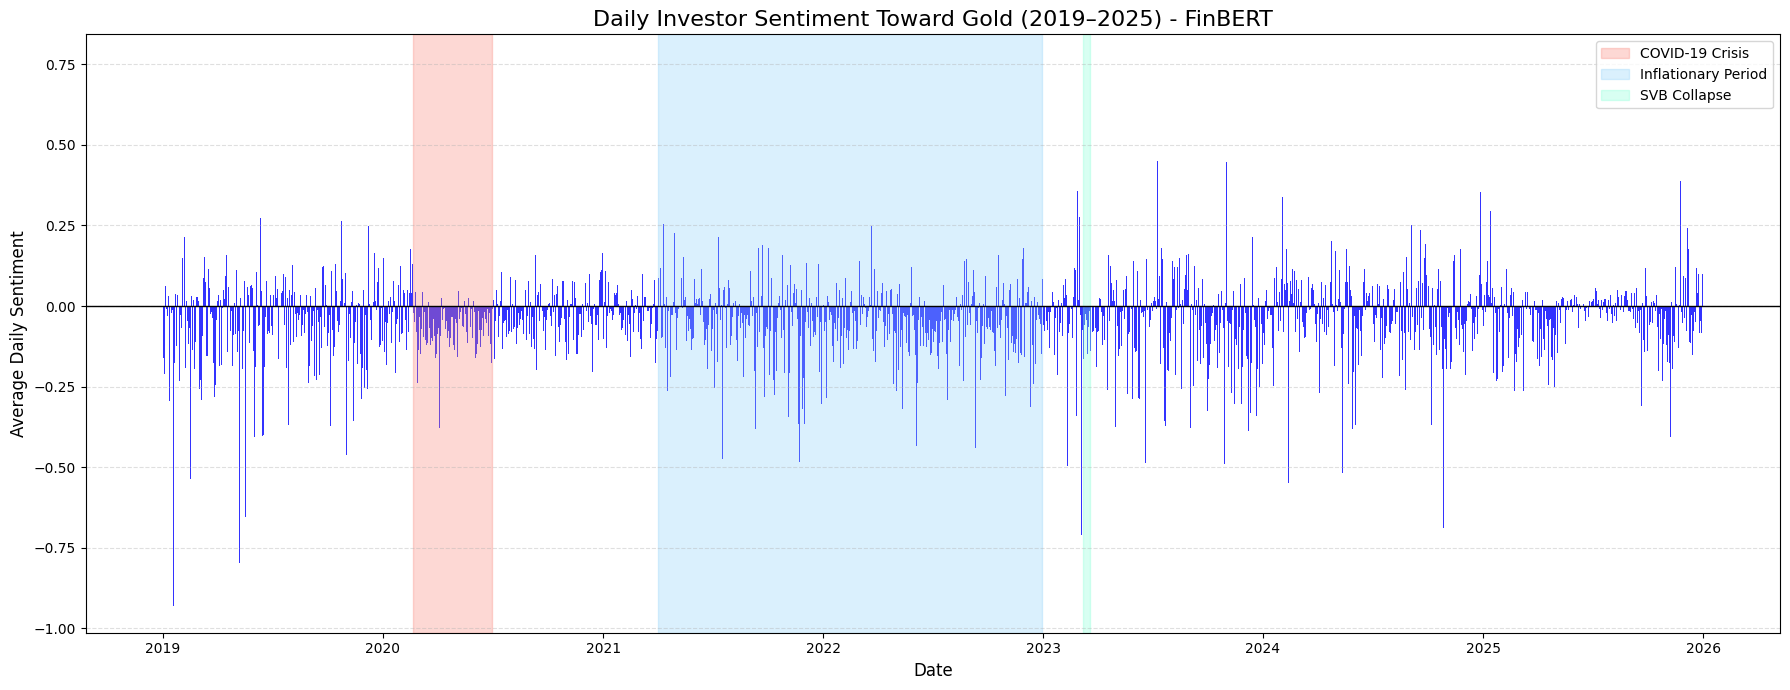

In [57]:
df = daily_finbert_sentiment
df["date"] = pd.to_datetime(df["date"])

# crisis periods
crisis_periods = [
    ("COVID-19 Crisis", "2020-02-20", "2020-06-30"),
    ("Inflationary Period", "2021-04-01", "2022-12-31"),
    ("SVB Collapse", "2023-03-08", "2023-03-20"),
]

fig, ax = plt.subplots(figsize=(18, 7))
ax.bar(
    df["date"],
    df["average_daily_sentiment"],
    color="blue",
    width=1.0,
    alpha=0.8
)
colors = ["salmon", "lightskyblue", "aquamarine"]
for (label, start, end), color in zip(crisis_periods, colors):
    ax.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color=color,
        alpha=0.3,
        label=label
    )
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Daily Investor Sentiment Toward Gold (2019–2025) - FinBERT", fontsize=16)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Average Daily Sentiment", fontsize=12)
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

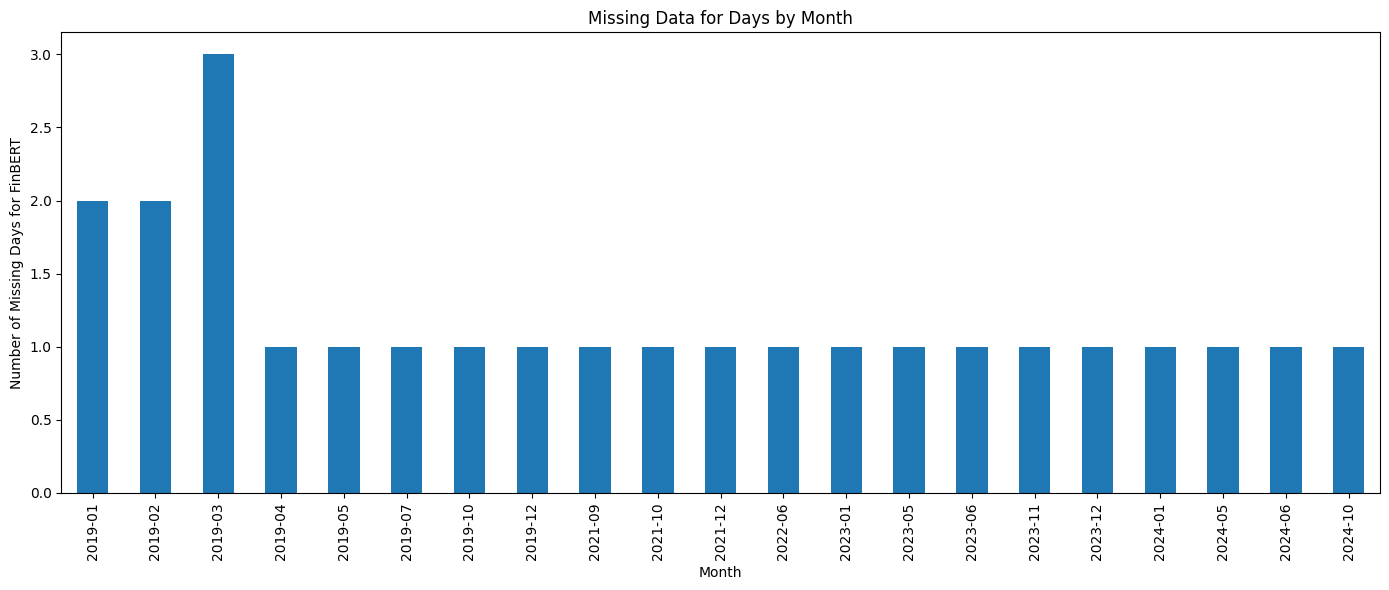

In [58]:
# extracting the daily dates
daily_finbert_sentiment["date"] = pd.to_datetime(
    daily_finbert_sentiment["date"],
    errors="coerce"
)

daily_finbert_sentiment["date"] = (
    daily_finbert_sentiment["date"].dt.date
)

full_dates = pd.date_range(
    start=daily_finbert_sentiment["date"].min(),
    end=daily_finbert_sentiment["date"].max(),
    freq="D"
)

# existing dates
existing_dates = pd.to_datetime(
    daily_finbert_sentiment["date"].dropna().unique()
)

# missing dates
missing_dates = sorted(
    set(full_dates) - set(existing_dates)
)

# converting missing dates to dataframe
missing_df = pd.DataFrame({
    "missing_date": pd.to_datetime(missing_dates)
})

# handling of no missing values
if missing_df.empty:

    print("No missing dates found.")

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.text(
        0.5,
        0.5,
        "No Missing Dates",
        ha="center",
        va="center",
        fontsize=16
    )

    ax.set_axis_off()

    plt.title("Missing Data for Days by Month")
    plt.show()

else:

    # extracting month period
    missing_df["month"] = (
        missing_df["missing_date"]
        .dt.to_period("M")
    )

    # counting missing days per month
    monthly_missing_counts = (
        missing_df["month"]
        .value_counts()
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(14, 6))

    monthly_missing_counts.plot(
        kind="bar",
        ax=ax
    )

    ax.set_xlabel("Month")

    ax.set_ylabel(
        "Number of Missing Days for FinBERT"
    )

    ax.set_title(
        "Missing Data for Days by Month"
    )

    plt.xticks(rotation=90)

    plt.tight_layout()

    plt.show()

In [59]:
daily_finbert_sentiment["log_gold_posts"] = np.log(daily_finbert_sentiment["gold_related_posts"])
daily_finbert_sentiment

,date,average_daily_sentiment,gold_related_posts,log_gold_posts
0,2019-01-01,-0.170056,3,1.098612
1,2019-01-02,-0.160799,4,1.386294
2,2019-01-03,-0.126003,10,2.302585
3,2019-01-04,-0.209705,4,1.386294
4,2019-01-05,0.062152,3,1.098612
...,...,...,...,...
2527,2025-12-27,-0.046648,32,3.465736
2528,2025-12-28,-0.023254,24,3.178054
2529,2025-12-29,-0.084610,40,3.688879
2530,2025-12-30,-0.070863,14,2.639057


#### 4.2.1 Creating Weighted Sentiment (JUST FOR EXAMINATION)

In [60]:
# weighted sentiment
daily_finbert_sentiment["weighted_sentiment"] = (
    daily_finbert_sentiment["average_daily_sentiment"]
    * daily_finbert_sentiment["log_gold_posts"]
)

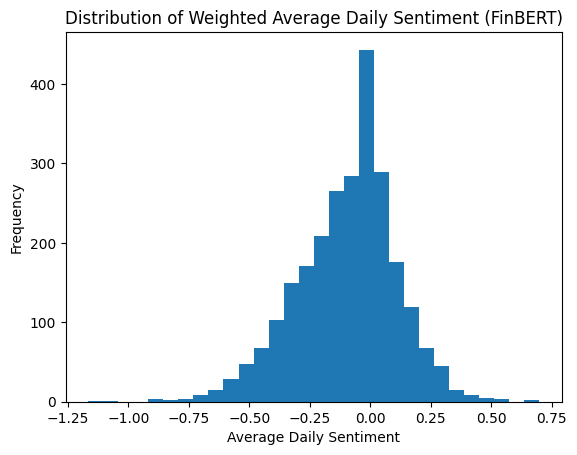

In [61]:
# plotting the distribution
plt.hist(daily_finbert_sentiment["weighted_sentiment"], bins=30)
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Frequency")
plt.title("Distribution of Weighted Average Daily Sentiment (FinBERT)")
plt.show()

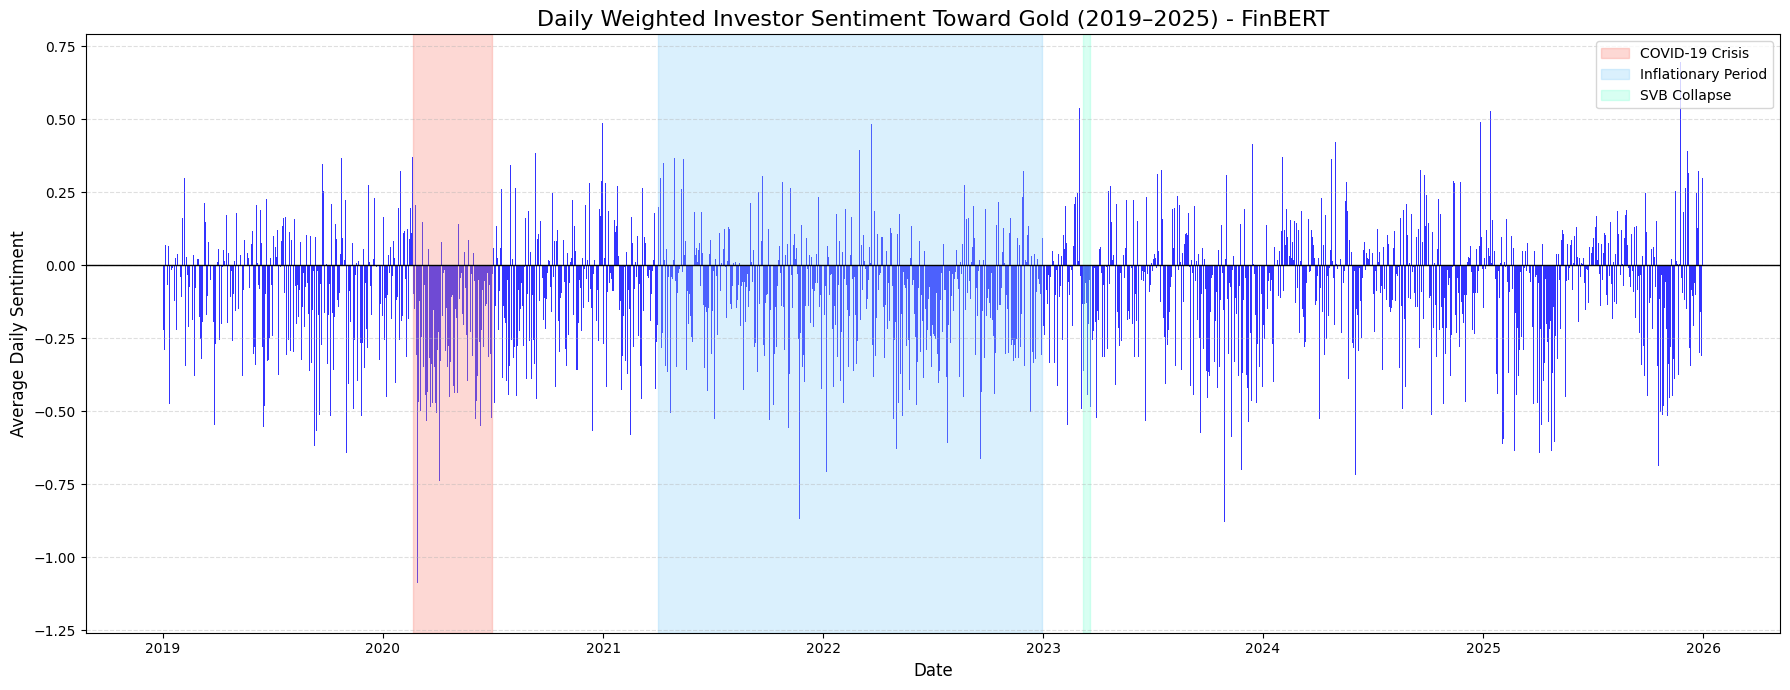

In [62]:
df = daily_finbert_sentiment
df["date"] = pd.to_datetime(df["date"])

# crisis periods
crisis_periods = [
    ("COVID-19 Crisis", "2020-02-20", "2020-06-30"),
    ("Inflationary Period", "2021-04-01", "2022-12-31"),
    ("SVB Collapse", "2023-03-08", "2023-03-20"),
]

fig, ax = plt.subplots(figsize=(18, 7))
ax.bar(
    df["date"],
    df["weighted_sentiment"],
    color="blue",
    width=1.0,
    alpha=0.8
)
colors = ["salmon", "lightskyblue", "aquamarine"]
for (label, start, end), color in zip(crisis_periods, colors):
    ax.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color=color,
        alpha=0.3,
        label=label
    )
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Daily Weighted Investor Sentiment Toward Gold (2019–2025) - FinBERT", fontsize=16)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Average Daily Sentiment", fontsize=12)
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Aggregating the Final Dataframe for Analysis

#### 5.1 VADER

In [63]:
dfs = [daily_vader_sentiment, volume_data, gold_spot]

merged_vader_df = reduce(lambda left, right: pd.merge(left, right, on='date'), dfs)
merged_vader_df = merged_vader_df.drop(columns={"weighted_sentiment"})
merged_vader_df

,date,average_daily_sentiment,gold_related_posts,log_gold_posts,logVolETF_t,Gold_Spot_Price,VIX,S&P_500,USD_Index,10Y_UST_Yield
0,2019-01-02,0.443150,4,1.386294,17.126246,1281.000000,23.219999,2510.030029,96.820000,2.661
1,2019-01-03,0.312830,10,2.302585,17.300438,1291.800049,25.450001,2447.889893,96.309998,2.554
2,2019-01-04,0.210750,4,1.386294,17.215232,1282.699951,21.379999,2531.939941,96.190002,2.659
3,2019-01-07,0.873600,1,0.000000,16.639853,1286.800049,21.400000,2549.689941,95.709999,2.682
4,2019-01-08,-0.341200,3,1.098612,16.626597,1283.199951,20.469999,2574.409912,95.900002,2.716
...,...,...,...,...,...,...,...,...,...,...
1746,2025-12-23,0.060914,44,3.784190,18.031587,4482.799805,14.000000,6909.790039,97.940002,4.169
1747,2025-12-24,0.263750,26,3.258097,17.931119,4480.600098,13.470000,6932.049805,97.980003,4.136
1748,2025-12-26,-0.034025,36,3.583519,17.997190,4529.100098,13.600000,6929.939941,98.019997,4.136
1749,2025-12-29,-0.030998,40,3.688879,18.539363,4325.100098,14.200000,6905.740234,98.040001,4.116


#### 5.2 FinBERT

In [64]:
dfs2 = [daily_finbert_sentiment, volume_data, gold_spot]

merged_finbert_df = reduce(lambda left, right: pd.merge(left, right, on='date'), dfs2)
merged_finbert_df = merged_finbert_df.drop(columns={"weighted_sentiment"})
merged_finbert_df

,date,average_daily_sentiment,gold_related_posts,log_gold_posts,logVolETF_t,Gold_Spot_Price,VIX,S&P_500,USD_Index,10Y_UST_Yield
0,2019-01-02,-0.160799,4,1.386294,17.126246,1281.000000,23.219999,2510.030029,96.820000,2.661
1,2019-01-03,-0.126003,10,2.302585,17.300438,1291.800049,25.450001,2447.889893,96.309998,2.554
2,2019-01-04,-0.209705,4,1.386294,17.215232,1282.699951,21.379999,2531.939941,96.190002,2.659
3,2019-01-07,-0.009005,1,0.000000,16.639853,1286.800049,21.400000,2549.689941,95.709999,2.682
4,2019-01-08,-0.011035,3,1.098612,16.626597,1283.199951,20.469999,2574.409912,95.900002,2.716
...,...,...,...,...,...,...,...,...,...,...
1746,2025-12-23,-0.064270,44,3.784190,18.031587,4482.799805,14.000000,6909.790039,97.940002,4.169
1747,2025-12-24,0.098789,26,3.258097,17.931119,4480.600098,13.470000,6932.049805,97.980003,4.136
1748,2025-12-26,-0.083398,36,3.583519,17.997190,4529.100098,13.600000,6929.939941,98.019997,4.136
1749,2025-12-29,-0.084610,40,3.688879,18.539363,4325.100098,14.200000,6905.740234,98.040001,4.116


## 6. Methodology Implementation

#### 6.1 Preparing the Data for Time Series Modeling

#### VADER Data

In [65]:
df = merged_vader_df.copy()

# ensuring that the date column is datetime
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# transform to log changes
df["gold_return"] = (
    np.log(df["Gold_Spot_Price"]) -
    np.log(df["Gold_Spot_Price"].shift(1))
)

df["VIX"] = (
    np.log(df["VIX"]) -
    np.log(df["VIX"].shift(1))
)

df["S&P_500"] = (
    np.log(df["S&P_500"]) -
    np.log(df["S&P_500"].shift(1))
)

df["USD_Index"] = (
    np.log(df["USD_Index"]) -
    np.log(df["USD_Index"].shift(1))
)



df["10Y_UST_Yield"] = (
    np.log(df["10Y_UST_Yield"]) -
    np.log(df["10Y_UST_Yield"].shift(1))
)

# implementing lag sentiment to avoid lookahead bias
df["sentiment_lag1"] = df["average_daily_sentiment"].shift(1)
df["volsent_lag1"] = df["gold_related_posts"].shift(1)
df["logVolETF_lag1"] = df["logVolETF_t"].shift(1)
df["10Y_UST_Yield_lag1"] = df["10Y_UST_Yield"].shift(1)
df["VIX_lag1"] = df["VIX"].shift(1)
df["S&P_500_lag1"] = df["S&P_500"].shift(1)
df["USD_Index_lag1"] = df["USD_Index"].shift(1)

# lagged sentiment for AR terms
max_lag = 10
for lag in range(0, max_lag + 1):
    df[f"return_lag{lag}"] = df["gold_return"].shift(lag)

final_vader_model = df.copy()
final_vader_model


,date,average_daily_sentiment,gold_related_posts,log_gold_posts,logVolETF_t,Gold_Spot_Price,VIX,S&P_500,USD_Index,10Y_UST_Yield,...,return_lag1,return_lag2,return_lag3,return_lag4,return_lag5,return_lag6,return_lag7,return_lag8,return_lag9,return_lag10
0,2019-01-02,0.443150,4,1.386294,17.126246,1281.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-03,0.312830,10,2.302585,17.300438,1291.800049,0.091702,-0.025068,-0.005281,-0.041041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-04,0.210750,4,1.386294,17.215232,1282.699951,-0.174260,0.033759,-0.001247,0.040289,...,0.008396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-07,0.873600,1,0.000000,16.639853,1286.800049,0.000935,0.006986,-0.005003,0.008613,...,-0.007069,0.008396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-08,-0.341200,3,1.098612,16.626597,1283.199951,-0.044431,0.009649,0.001983,0.012597,...,0.003191,-0.007069,0.008396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1746,2025-12-23,0.060914,44,3.784190,18.031587,4482.799805,-0.005698,0.004540,-0.003567,0.000000,...,0.018897,0.005034,-0.001842,0.009940,-0.000511,0.001534,0.003401,0.021010,-0.002452,0.004646
1747,2025-12-24,0.263750,26,3.258097,17.931119,4480.600098,-0.038592,0.003216,0.000408,-0.007947,...,0.008558,0.018897,0.005034,-0.001842,0.009940,-0.000511,0.001534,0.003401,0.021010,-0.002452
1748,2025-12-26,-0.034025,36,3.583519,17.997190,4529.100098,0.009605,-0.000304,0.000408,0.000000,...,-0.000491,0.008558,0.018897,0.005034,-0.001842,0.009940,-0.000511,0.001534,0.003401,0.021010
1749,2025-12-29,-0.030998,40,3.688879,18.539363,4325.100098,0.043172,-0.003498,0.000204,-0.004847,...,0.010766,-0.000491,0.008558,0.018897,0.005034,-0.001842,0.009940,-0.000511,0.001534,0.003401


In [66]:
df.columns

Index(['date', 'average_daily_sentiment', 'gold_related_posts',
       'log_gold_posts', 'logVolETF_t', 'Gold_Spot_Price', 'VIX', 'S&P_500',
       'USD_Index', '10Y_UST_Yield', 'gold_return', 'sentiment_lag1',
       'volsent_lag1', 'logVolETF_lag1', '10Y_UST_Yield_lag1', 'VIX_lag1',
       'S&P_500_lag1', 'USD_Index_lag1', 'return_lag0', 'return_lag1',
       'return_lag2', 'return_lag3', 'return_lag4', 'return_lag5',
       'return_lag6', 'return_lag7', 'return_lag8', 'return_lag9',
       'return_lag10'],
      dtype='object')

In [67]:
df[["date","VIX","VIX_lag1"]].head(10)

,date,VIX,VIX_lag1
0,2019-01-02,NaN,NaN
1,2019-01-03,0.091702,NaN
2,2019-01-04,-0.174260,0.091702
3,2019-01-07,0.000935,-0.174260
4,2019-01-08,-0.044431,0.000935
5,2019-01-09,-0.024229,-0.044431
6,2019-01-10,-0.024317,-0.024229
7,2019-01-11,-0.069542,-0.024317
8,2019-01-15,0.022290,-0.069542
9,2019-01-16,0.023380,0.022290


#### FinBERT Data

In [68]:
df2 = merged_finbert_df.copy()

# ensuring date column is datetime
df2["date"] = pd.to_datetime(df2["date"])
df2 = df2.sort_values("date").reset_index(drop=True)

# transforming to log changes
df2["gold_return"] = (
    np.log(df2["Gold_Spot_Price"]) -
    np.log(df2["Gold_Spot_Price"].shift(1))
)

df2["VIX"] = (
    np.log(df2["VIX"]) -
    np.log(df2["VIX"].shift(1))
)

df2["S&P_500"] = (
    np.log(df2["S&P_500"]) -
    np.log(df2["S&P_500"].shift(1))
)

df2["USD_Index"] = (
    np.log(df2["USD_Index"]) -
    np.log(df2["USD_Index"].shift(1))
)

df2["10Y_UST_Yield"] = (
    np.log(df2["10Y_UST_Yield"]) -
    np.log(df2["10Y_UST_Yield"].shift(1))
)


# implementing lag sentiment to avoid lookahead bias
df2["sentiment_lag1"] = df2["average_daily_sentiment"].shift(1)
df2["volsent_lag1"] = df2["gold_related_posts"].shift(1)
df2["logVolETF_lag1"] = df2["logVolETF_t"].shift(1)
df2["10Y_UST_Yield_lag1"] = df2["10Y_UST_Yield"].shift(1)
df2["VIX_lag1"] = df2["VIX"].shift(1)
df2["S&P_500_lag1"] = df2["S&P_500"].shift(1)
df2["USD_Index_lag1"] = df2["USD_Index"].shift(1)

# lagged sentiment for AR terms
max_lag = 10
for lag in range(0, max_lag + 1):
    df2[f"return_lag{lag}"] = df2["gold_return"].shift(lag)

final_finbert_model = df2.copy()
final_finbert_model

,date,average_daily_sentiment,gold_related_posts,log_gold_posts,logVolETF_t,Gold_Spot_Price,VIX,S&P_500,USD_Index,10Y_UST_Yield,...,return_lag1,return_lag2,return_lag3,return_lag4,return_lag5,return_lag6,return_lag7,return_lag8,return_lag9,return_lag10
0,2019-01-02,-0.160799,4,1.386294,17.126246,1281.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-03,-0.126003,10,2.302585,17.300438,1291.800049,0.091702,-0.025068,-0.005281,-0.041041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-04,-0.209705,4,1.386294,17.215232,1282.699951,-0.174260,0.033759,-0.001247,0.040289,...,0.008396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-07,-0.009005,1,0.000000,16.639853,1286.800049,0.000935,0.006986,-0.005003,0.008613,...,-0.007069,0.008396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-08,-0.011035,3,1.098612,16.626597,1283.199951,-0.044431,0.009649,0.001983,0.012597,...,0.003191,-0.007069,0.008396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1746,2025-12-23,-0.064270,44,3.784190,18.031587,4482.799805,-0.005698,0.004540,-0.003567,0.000000,...,0.018897,0.005034,-0.001842,0.009940,-0.000511,0.001534,0.003401,0.021010,-0.002452,0.004646
1747,2025-12-24,0.098789,26,3.258097,17.931119,4480.600098,-0.038592,0.003216,0.000408,-0.007947,...,0.008558,0.018897,0.005034,-0.001842,0.009940,-0.000511,0.001534,0.003401,0.021010,-0.002452
1748,2025-12-26,-0.083398,36,3.583519,17.997190,4529.100098,0.009605,-0.000304,0.000408,0.000000,...,-0.000491,0.008558,0.018897,0.005034,-0.001842,0.009940,-0.000511,0.001534,0.003401,0.021010
1749,2025-12-29,-0.084610,40,3.688879,18.539363,4325.100098,0.043172,-0.003498,0.000204,-0.004847,...,0.010766,-0.000491,0.008558,0.018897,0.005034,-0.001842,0.009940,-0.000511,0.001534,0.003401


#### 6.2 Pre-Regression Diagnostic Checks

#### 6.2.1 Statonarity Check (ADF Test)

#### VADER

In [69]:
df = final_vader_model

adf_variables = [
    "gold_return",
    "sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

for col in adf_variables:

    series = df[col].dropna()

    result = adfuller(series)

    adf_stat = result[0]
    p_value = result[1]

    print(f"\nVariable: {col}")
    print(f"ADF Statistic: {adf_stat:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Interpretation: Stationary series (reject unit root).")
    else:
        print("Interpretation: Non-stationary series (fail to reject unit root).")
    


Variable: gold_return
ADF Statistic: -17.8672
P-value: 0.0000
Interpretation: Stationary series (reject unit root).

Variable: sentiment_lag1
ADF Statistic: -6.9338
P-value: 0.0000
Interpretation: Stationary series (reject unit root).

Variable: volsent_lag1
ADF Statistic: -5.6064
P-value: 0.0000
Interpretation: Stationary series (reject unit root).

Variable: logVolETF_lag1
ADF Statistic: -4.6883
P-value: 0.0001
Interpretation: Stationary series (reject unit root).

Variable: VIX_lag1
ADF Statistic: -23.2878
P-value: 0.0000
Interpretation: Stationary series (reject unit root).

Variable: S&P_500_lag1
ADF Statistic: -13.0413
P-value: 0.0000
Interpretation: Stationary series (reject unit root).

Variable: USD_Index_lag1
ADF Statistic: -18.7243
P-value: 0.0000
Interpretation: Stationary series (reject unit root).

Variable: 10Y_UST_Yield_lag1
ADF Statistic: -7.3187
P-value: 0.0000
Interpretation: Stationary series (reject unit root).


#### FinBERT

In [70]:
df2 = final_finbert_model

adf_variables = [
    "gold_return",
    "sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

for col in adf_variables:

    series = df2[col].dropna()

    result = adfuller(series)

    adf_stat = result[0]
    p_value = result[1]

    print(f"\nVariable: {col}")
    print(f"ADF Statistic: {adf_stat:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Interpretation: Stationary series (reject unit root).")
    else:
        print("Interpretation: Non-stationary series (fail to reject unit root).")


Variable: gold_return
ADF Statistic: -17.8672
P-value: 0.0000
Interpretation: Stationary series (reject unit root).

Variable: sentiment_lag1
ADF Statistic: -38.3248
P-value: 0.0000
Interpretation: Stationary series (reject unit root).

Variable: volsent_lag1
ADF Statistic: -5.6064
P-value: 0.0000
Interpretation: Stationary series (reject unit root).

Variable: logVolETF_lag1
ADF Statistic: -4.6883
P-value: 0.0001
Interpretation: Stationary series (reject unit root).

Variable: VIX_lag1
ADF Statistic: -23.2878
P-value: 0.0000
Interpretation: Stationary series (reject unit root).

Variable: S&P_500_lag1
ADF Statistic: -13.0413
P-value: 0.0000
Interpretation: Stationary series (reject unit root).

Variable: USD_Index_lag1
ADF Statistic: -18.7243
P-value: 0.0000
Interpretation: Stationary series (reject unit root).

Variable: 10Y_UST_Yield_lag1
ADF Statistic: -7.3187
P-value: 0.0000
Interpretation: Stationary series (reject unit root).


#### 6.2.2 Conducting AIC and BIC Test

#### VADER

In [71]:
# determining the optimal AR lag structure
max_lags = 10

aic_results = []
bic_results = []

for lag in range(1, max_lags + 1):

    X_vars = [
        "logVolETF_lag1",
        "volsent_lag1",
        "sentiment_lag1",
        "VIX_lag1",
        "S&P_500_lag1",
        "USD_Index_lag1",
        "10Y_UST_Yield_lag1"
    ]

    # dynamically adding lagged returns
    for i in range(1, lag + 1):
        X_vars.append(f"return_lag{i}")

    X = df[X_vars]

    X = sm.add_constant(X)

    y = df["gold_return"]

    temp_df = pd.concat([y, X], axis=1).dropna()

    y_temp = temp_df["gold_return"]

    X_temp = temp_df.drop(columns=["gold_return"])

    # estimating regression model
    model = sm.OLS(y_temp, X_temp).fit()

    aic_results.append(model.aic)
    bic_results.append(model.bic)

lag_selection_df = pd.DataFrame({
    "Lag": range(1, max_lags + 1),
    "AIC": aic_results,
    "BIC": bic_results
})

lag_selection_df

,Lag,AIC,BIC
0,1,-11015.459111,-10966.278523
1,2,-11006.842800,-10952.203434
2,3,-10997.543813,-10937.446819
3,4,-10991.315064,-10925.761594
4,5,-10982.280157,-10911.271363
5,6,-10978.746809,-10902.283844
6,7,-10972.294894,-10890.378911
7,8,-10963.027411,-10875.659566
8,9,-10953.940750,-10861.122199
9,10,-10944.826045,-10846.557945




OPTIMAL LAG SELECTION
AIC selects lag: 1
BIC selects lag: 1

Interpretation:
- AIC usually favors more complex models.
- BIC penalizes complexity more heavily.
- BIC often produces more parsimonious models.
- AIC is often preferred for forecasting applications.

Chosen lag length for regression: 1


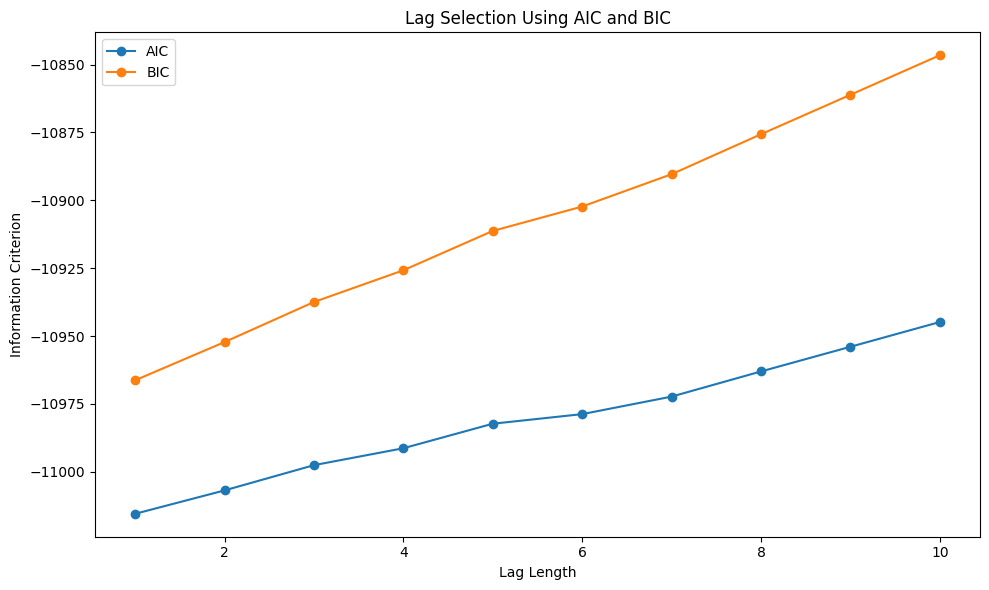

In [72]:
# selecting optimal lag
optimal_aic_lag = lag_selection_df.loc[
    lag_selection_df["AIC"].idxmin(),
    "Lag"
]

optimal_bic_lag = lag_selection_df.loc[
    lag_selection_df["BIC"].idxmin(),
    "Lag"
]

print("\n")
print("=" * 40)
print("OPTIMAL LAG SELECTION")
print("=" * 40)

print(f"AIC selects lag: {optimal_aic_lag}")
print(f"BIC selects lag: {optimal_bic_lag}")

print("\nInterpretation:")
print("- AIC usually favors more complex models.")
print("- BIC penalizes complexity more heavily.")
print("- BIC often produces more parsimonious models.")
print("- AIC is often preferred for forecasting applications.")

chosen_lag_vader = optimal_bic_lag

print(f"\nChosen lag length for regression: {chosen_lag_vader}")

plt.figure(figsize=(10, 6))
plt.plot(
    lag_selection_df["Lag"],
    lag_selection_df["AIC"],
    marker="o",
    label="AIC"
)
plt.plot(
    lag_selection_df["Lag"],
    lag_selection_df["BIC"],
    marker="o",
    label="BIC"
)
plt.xlabel("Lag Length")
plt.ylabel("Information Criterion")
plt.title("Lag Selection Using AIC and BIC")
plt.legend()
plt.tight_layout()
plt.show()

#### FinBERT

In [73]:
# determining the optimal AR lag structure
max_lags_fin = 10

aic_results2 = []
bic_results2 = []

for lag in range(1, max_lags_fin + 1):

    X_vars2 = [
        "logVolETF_lag1",
        "volsent_lag1",
        "sentiment_lag1",
        "VIX_lag1",
        "S&P_500_lag1",
        "USD_Index_lag1",
        "10Y_UST_Yield_lag1"
    ]

    # dynamically adding lagged returns
    for i in range(1, lag + 1):
        X_vars2.append(f"return_lag{i}")

    X2 = df2[X_vars2]

    X2 = sm.add_constant(X2)

    y2 = df2["gold_return"]

    temp_df2 = pd.concat([y2, X2], axis=1).dropna()

    y_temp2 = temp_df2["gold_return"]

    X_temp2 = temp_df2.drop(columns=["gold_return"])

    # estimating regression model
    model2 = sm.OLS(y_temp2, X_temp2).fit()

    aic_results2.append(model2.aic)
    bic_results2.append(model2.bic)

lag_selection_finbert_df = pd.DataFrame({
    "Lag": range(1, max_lags + 1),
    "AIC": aic_results2,
    "BIC": bic_results2
})

lag_selection_finbert_df

,Lag,AIC,BIC
0,1,-11017.300135,-10968.119546
1,2,-11008.626822,-10953.987456
2,3,-10999.342889,-10939.245895
3,4,-10993.164581,-10927.611111
4,5,-10984.147441,-10913.138646
5,6,-10980.724318,-10904.261352
6,7,-10974.255632,-10892.339649
7,8,-10965.018592,-10877.650747
8,9,-10955.938868,-10863.120317
9,10,-10946.804362,-10848.536262




OPTIMAL LAG SELECTION
AIC selects lag: 1
BIC selects lag: 1

Interpretation:
- AIC usually favors more complex models.
- BIC penalizes complexity more heavily.
- BIC often produces more parsimonious models.
- AIC is often preferred for forecasting applications.

Chosen lag length for regression: 1


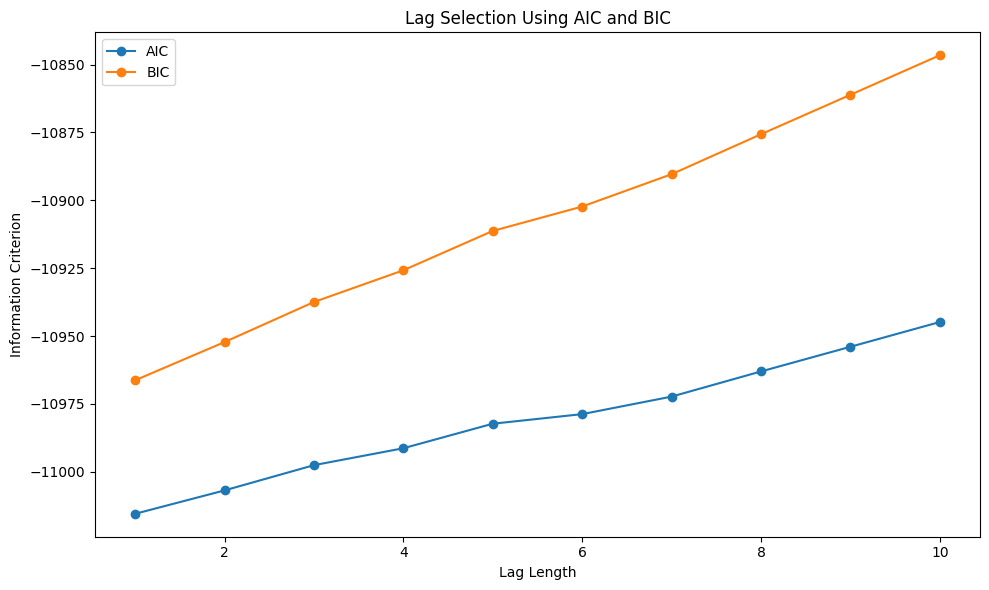

In [74]:
# selecting optimal lag
optimal_aic_finbert_lag = lag_selection_finbert_df.loc[
    lag_selection_finbert_df["AIC"].idxmin(),
    "Lag"
]

optimal_bic_finbert_lag = lag_selection_finbert_df.loc[
    lag_selection_finbert_df["BIC"].idxmin(),
    "Lag"
]

print("\n")
print("=" * 40)
print("OPTIMAL LAG SELECTION")
print("=" * 40)

print(f"AIC selects lag: {optimal_aic_finbert_lag}")
print(f"BIC selects lag: {optimal_bic_finbert_lag}")

print("\nInterpretation:")
print("- AIC usually favors more complex models.")
print("- BIC penalizes complexity more heavily.")
print("- BIC often produces more parsimonious models.")
print("- AIC is often preferred for forecasting applications.")

chosen_lag_finbert = optimal_bic_finbert_lag

print(f"\nChosen lag length for regression: {chosen_lag_finbert}")

plt.figure(figsize=(10, 6))
plt.plot(
    lag_selection_df["Lag"],
    lag_selection_df["AIC"],
    marker="o",
    label="AIC"
)
plt.plot(
    lag_selection_df["Lag"],
    lag_selection_df["BIC"],
    marker="o",
    label="BIC"
)
plt.xlabel("Lag Length")
plt.ylabel("Information Criterion")
plt.title("Lag Selection Using AIC and BIC")
plt.legend()
plt.tight_layout()
plt.show()

#### 6.2.3 Correlation Matrix

#### VADER

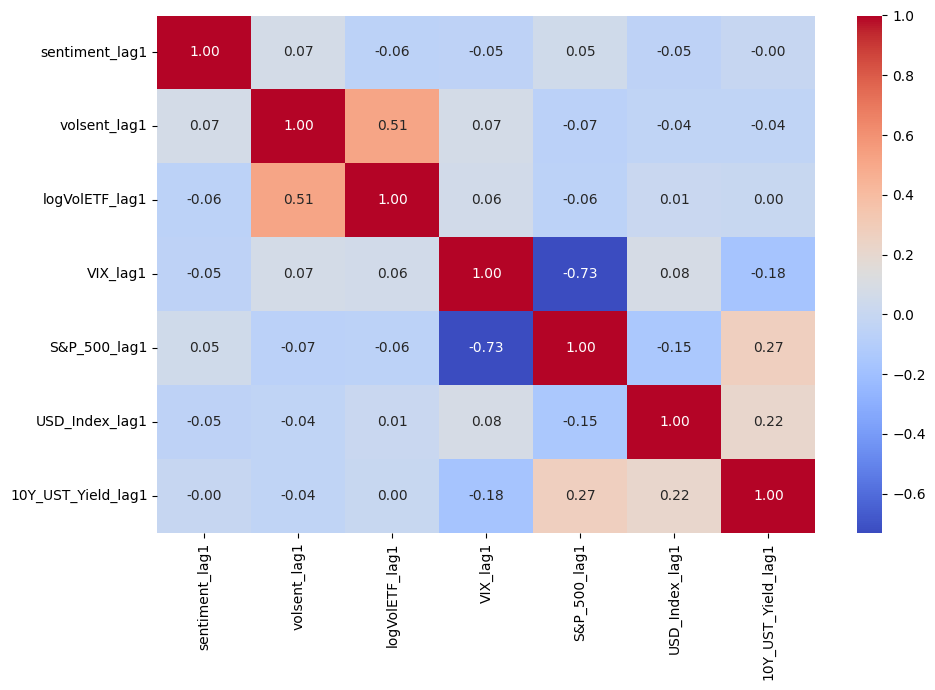

In [75]:
corr_vars = [
    "sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
# plt.title("Correlation Matrix of Explanatory Variables")
plt.tight_layout()
plt.show()

#### Correlation Between Sentiment and Gold Returns (Aggregate Sentiment, Positive Sentiment, Negative Sentiment)

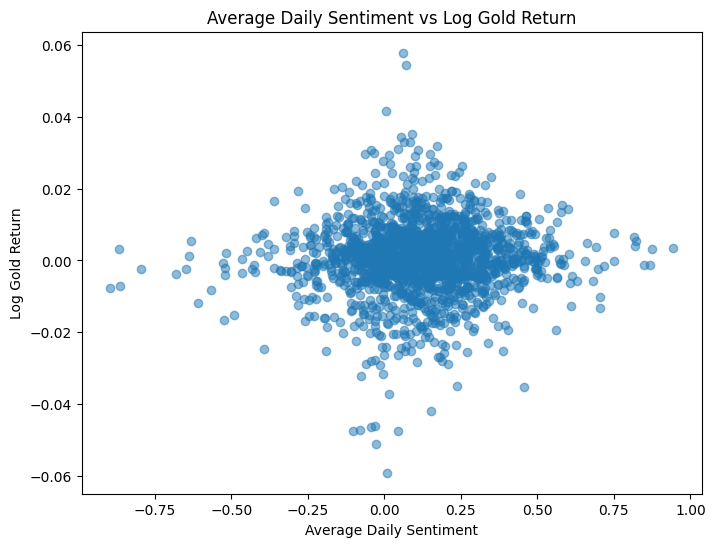

In [76]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["average_daily_sentiment"],
    df["gold_return"],
    alpha=0.5
)

plt.xlabel("Average Daily Sentiment")
plt.ylabel("Log Gold Return")
plt.title("Average Daily Sentiment vs Log Gold Return")
plt.show()

#### FinBERT

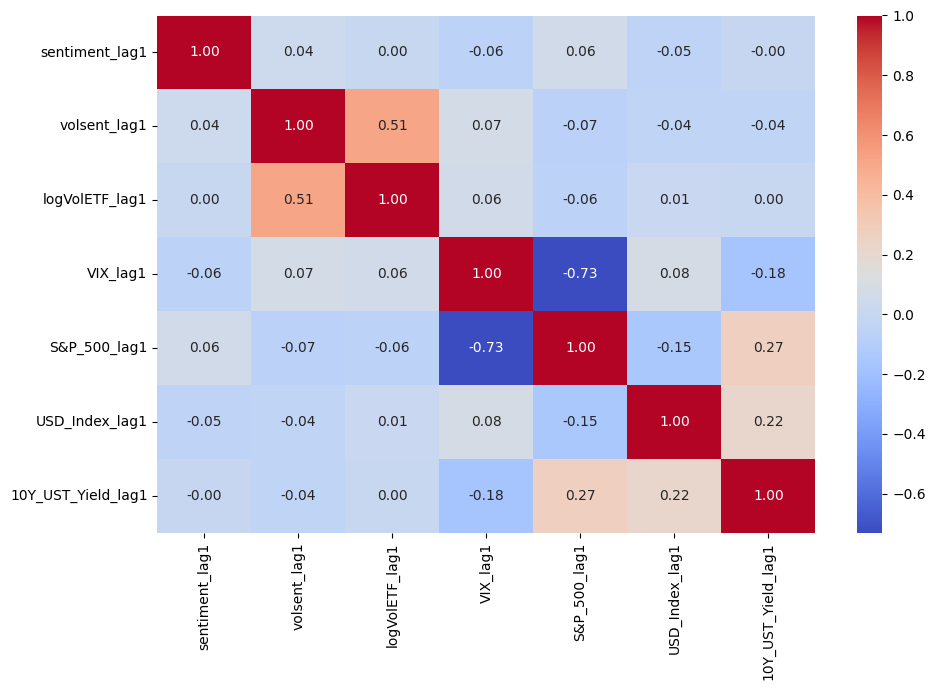

In [77]:
corr_vars = [
    "sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

corr_matrix = df2[corr_vars].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
# plt.title("Correlation Matrix of Explanatory Variables")
plt.tight_layout()
plt.show()

#### Correlation Between Sentiment and Gold Returns (Aggregate Sentiment, Positive Sentiment, Negative Sentiment)

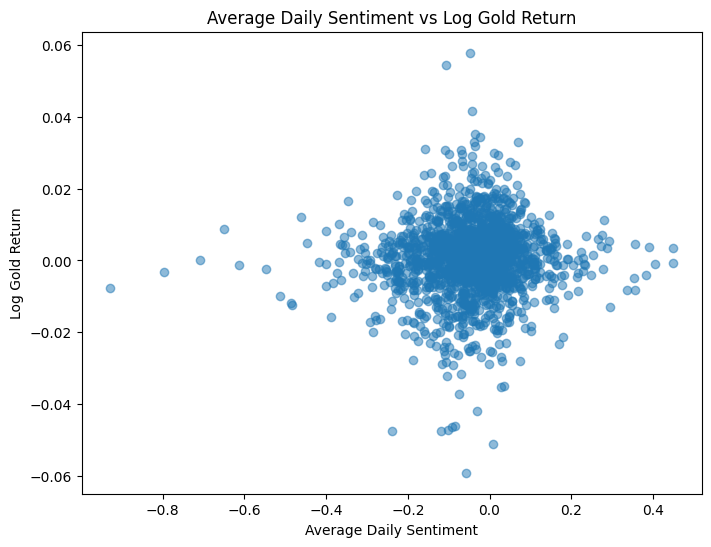

In [78]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df2["average_daily_sentiment"],
    df2["gold_return"],
    alpha=0.5
)

plt.xlabel("Average Daily Sentiment")
plt.ylabel("Log Gold Return")
plt.title("Average Daily Sentiment vs Log Gold Return")
plt.show()

#### 6.2.4 VIF Test (Testing Multicollinearity)

#### VADER

In [79]:
X_vif = df[corr_vars].dropna()

vif_df = pd.DataFrame()

vif_df["Variable"] = X_vif.columns

vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_df)

print("\nInterpretation:")
print("VIF < 5  -> acceptable multicollinearity")
print("VIF > 10 -> problematic multicollinearity")

             Variable       VIF
0      sentiment_lag1  1.338909
1        volsent_lag1  1.620040
2      logVolETF_lag1  1.884806
3            VIX_lag1  2.158379
4        S&P_500_lag1  2.337895
5      USD_Index_lag1  1.107179
6  10Y_UST_Yield_lag1  1.166331

Interpretation:
VIF < 5  -> acceptable multicollinearity
VIF > 10 -> problematic multicollinearity


#### FinBERT

In [80]:
X_vif = df2[corr_vars].dropna()

vif_df = pd.DataFrame()

vif_df["Variable"] = X_vif.columns

vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_df)

print("\nInterpretation:")
print("VIF < 5  -> acceptable multicollinearity")
print("VIF > 10 -> problematic multicollinearity")

             Variable       VIF
0      sentiment_lag1  1.160513
1        volsent_lag1  1.616187
2      logVolETF_lag1  1.795425
3            VIX_lag1  2.157624
4        S&P_500_lag1  2.338622
5      USD_Index_lag1  1.106806
6  10Y_UST_Yield_lag1  1.166413

Interpretation:
VIF < 5  -> acceptable multicollinearity
VIF > 10 -> problematic multicollinearity


## 7. Regression Analysis & Results

#### 7.1 Baseline Model

In [81]:
# defining baseline explanatory variables
baseline_X_vars = [
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

# adding optimal AR lags
for i in range(1, chosen_lag_vader + 1):
    baseline_X_vars.append(
        f"return_lag{i}"
    )

# scaling variables
baseline_cols_to_scale = (
    ["gold_return"] + baseline_X_vars
)

baseline_scaler = StandardScaler()

df[baseline_cols_to_scale] = (
    baseline_scaler.fit_transform(
        df[baseline_cols_to_scale]
    )
)

# defining dependent and explanatory variables
y_baseline = df["gold_return"]

X_baseline = df[
    baseline_X_vars
]

X_baseline = sm.add_constant(
    X_baseline
)

# creating estimation dataframe and removing missing values
baseline_df = pd.concat(
    [y_baseline, X_baseline],
    axis=1
).dropna()

# final regression inputs
y_baseline_model = baseline_df[
    "gold_return"
]

X_baseline_model = baseline_df.drop(
    columns=["gold_return"]
)

# estimating baseline model with HAC standard errors
baseline_ols = sm.OLS(
    y_baseline_model,
    X_baseline_model
)

baseline_results = baseline_ols.fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5}
)

# displaying results
print(
    baseline_results.summary()
)


                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     2.977
Date:                Mon, 25 May 2026   Prob (F-statistic):            0.00677
Time:                        16:19:24   Log-Likelihood:                -2459.2
No. Observations:                1745   AIC:                             4932.
Df Residuals:                    1738   BIC:                             4971.
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0003      0

#### 7.2 Sentiment Augmented Model

#### VADER

In [82]:
df = df.copy()

# defining sentiment-augmented explanatory variables (VADER)
vader_sentiment_X_vars = [
    "sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

# adding optimal AR lags
for i in range(1, chosen_lag_vader + 1):
    vader_sentiment_X_vars.append(
        f"return_lag{i}"
    )

# scaling variables
vader_sentiment_cols_to_scale = (
    ["gold_return"] + vader_sentiment_X_vars
)

vader_sentiment_scaler = StandardScaler()

df[vader_sentiment_cols_to_scale] = (
    vader_sentiment_scaler.fit_transform(
        df[vader_sentiment_cols_to_scale]
    )
)

# defining dependent and explanatory variables
y_vader_sentiment = df["gold_return"]

X_vader_sentiment = df[
    vader_sentiment_X_vars
]

X_vader_sentiment = sm.add_constant(
    X_vader_sentiment
)

# creating estimation dataframe and removing missing values
vader_sentiment_df = pd.concat(
    [y_vader_sentiment, X_vader_sentiment],
    axis=1
).dropna()

# final regression inputs
y_vader_sentiment_model = (
    vader_sentiment_df["gold_return"]
)

X_vader_sentiment_model = (
    vader_sentiment_df.drop(
        columns=["gold_return"]
    )
)

# estimating sentiment-augmented model with HAC standard errors
vader_sentiment_ols = sm.OLS(
    y_vader_sentiment_model,
    X_vader_sentiment_model
)

vader_sentiment_results = (
    vader_sentiment_ols.fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
)

# displaying results
print(
    vader_sentiment_results.summary()
)

                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     2.541
Date:                Mon, 25 May 2026   Prob (F-statistic):            0.00944
Time:                        16:19:24   Log-Likelihood:                -2458.1
No. Observations:                1745   AIC:                             4934.
Df Residuals:                    1736   BIC:                             4983.
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0003      0

#### DIVIDED SENTIMENT

In [83]:
# dividing sentiment into positive and negative components
df = df.copy()

df["positive_sentiment"] = (
    df["average_daily_sentiment"].clip(lower=0)
)

df["negative_sentiment"] = (
    df["average_daily_sentiment"].clip(upper=0)
)

# creating lagged sentiment variables
df["positive_sentiment_lag1"] = (
    df["positive_sentiment"].shift(1)
)

df["negative_sentiment_lag1"] = (
    df["negative_sentiment"].shift(1)
)

# defining divided sentiment explanatory variables (VADER)
vader_divided_sentiment_X_vars = [
    "positive_sentiment_lag1",
    "negative_sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

# adding optimal AR lags
for i in range(1, chosen_lag_vader + 1):
    vader_divided_sentiment_X_vars.append(
        f"return_lag{i}"
    )

# scaling variables
vader_divided_sentiment_cols_to_scale = (
    ["gold_return"] +
    vader_divided_sentiment_X_vars
)

vader_divided_sentiment_scaler = (
    StandardScaler()
)

df[vader_divided_sentiment_cols_to_scale] = (
    vader_divided_sentiment_scaler.fit_transform(
        df[
            vader_divided_sentiment_cols_to_scale
        ]
    )
)

# defining dependent and explanatory variables
y_vader_divided_sentiment = (
    df["gold_return"]
)

X_vader_divided_sentiment = (
    df[
        vader_divided_sentiment_X_vars
    ]
)

X_vader_divided_sentiment = (
    sm.add_constant(
        X_vader_divided_sentiment
    )
)

# creating estimation dataframe and removing missing values
vader_divided_sentiment_df = (
    pd.concat(
        [
            y_vader_divided_sentiment,
            X_vader_divided_sentiment
        ],
        axis=1
    ).dropna()
)

# final regression inputs
y_vader_divided_sentiment_model = (
    vader_divided_sentiment_df[
        "gold_return"
    ]
)

X_vader_divided_sentiment_model = (
    vader_divided_sentiment_df.drop(
        columns=["gold_return"]
    )
)

# estimating model with HAC standard errors
vader_divided_sentiment_ols = (
    sm.OLS(
        y_vader_divided_sentiment_model,
        X_vader_divided_sentiment_model
    )
)

vader_divided_sentiment_results = (
    vader_divided_sentiment_ols.fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
)


# displaying results
print(
    vader_divided_sentiment_results.summary()
)

# wald test
print("\n")
print("=" * 60)
print("WALD TEST: POSITIVE VS NEGATIVE SENTIMENT")
print("=" * 60)

wald_test_vader = (
    vader_divided_sentiment_results.wald_test(
        "positive_sentiment_lag1 = negative_sentiment_lag1"
    )
)

print(wald_test_vader)

print("\nInterpretation:")
print("- Rejecting the null suggests asymmetric sentiment effects.")
print("- This means positive and negative sentiment have")
print("  statistically different explanatory power.")

                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     2.272
Date:                Mon, 25 May 2026   Prob (F-statistic):             0.0158
Time:                        16:19:24   Log-Likelihood:                -2458.1
No. Observations:                1745   AIC:                             4936.
Df Residuals:                    1735   BIC:                             4991.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


#### FinBERT

In [84]:
df2 = df2.copy()

# defining sentiment-augmented explanatory variables (FINBERT)
finbert_sentiment_X_vars = [
    "sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

# adding optimal AR lags
for i in range(1, chosen_lag_finbert + 1):
    finbert_sentiment_X_vars.append(
        f"return_lag{i}"
    )

# scaling and standardizing variables
finbert_sentiment_cols_to_scale = (
    ["gold_return"] +
    finbert_sentiment_X_vars
)

finbert_sentiment_scaler = (
    StandardScaler()
)

df2[finbert_sentiment_cols_to_scale] = (
    finbert_sentiment_scaler.fit_transform(
        df2[
            finbert_sentiment_cols_to_scale
        ]
    )
)

# defining dependent and explanatory variables
y_finbert_sentiment = (
    df2["gold_return"]
)

X_finbert_sentiment = (
    df2[
        finbert_sentiment_X_vars
    ]
)

X_finbert_sentiment = (
    sm.add_constant(
        X_finbert_sentiment
    )
)

# creating estimation dataframe and removing missing values
finbert_sentiment_df = (
    pd.concat(
        [
            y_finbert_sentiment,
            X_finbert_sentiment
        ],
        axis=1
    ).dropna()
)

# final regression inputs
y_finbert_sentiment_model = (
    finbert_sentiment_df[
        "gold_return"
    ]
)

X_finbert_sentiment_model = (
    finbert_sentiment_df.drop(
        columns=["gold_return"]
    )
)

# estimating model with HAC standard errors
finbert_sentiment_ols = (
    sm.OLS(
        y_finbert_sentiment_model,
        X_finbert_sentiment_model
    )
)

finbert_sentiment_results = (
    finbert_sentiment_ols.fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
)

# displaying results
print(
    finbert_sentiment_results.summary()
)

                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     2.920
Date:                Mon, 25 May 2026   Prob (F-statistic):            0.00306
Time:                        16:19:24   Log-Likelihood:                -2457.2
No. Observations:                1745   AIC:                             4932.
Df Residuals:                    1736   BIC:                             4982.
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0003      0

#### DIVIDED SENTIMENT

In [85]:
# dividing sentiment into positive and negative components
df2 = df2.copy()

df2["positive_sentiment"] = (
    df2["average_daily_sentiment"].clip(lower=0)
)

df2["negative_sentiment"] = (
    df2["average_daily_sentiment"].clip(upper=0)
)

# creating lagged sentiment variables
df2["positive_sentiment_lag1"] = (
    df2["positive_sentiment"].shift(1)
)

df2["negative_sentiment_lag1"] = (
    df2["negative_sentiment"].shift(1)
)

# defining divided sentiment explanatory variables (FINBERT)
finbert_divided_sentiment_X_vars = [
    "positive_sentiment_lag1",
    "negative_sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

# adding optimal AR lags
for i in range(1, chosen_lag_finbert + 1):
    finbert_divided_sentiment_X_vars.append(
        f"return_lag{i}"
    )

# scaling and standardizing variables
finbert_divided_sentiment_cols_to_scale = (
    ["gold_return"] +
    finbert_divided_sentiment_X_vars
)

finbert_divided_sentiment_scaler = (
    StandardScaler()
)

df2[finbert_divided_sentiment_cols_to_scale] = (
    finbert_divided_sentiment_scaler.fit_transform(
        df2[
            finbert_divided_sentiment_cols_to_scale
        ]
    )
)

# defining dependent and explanatory variables
y_finbert_divided_sentiment = (
    df2["gold_return"]
)

X_finbert_divided_sentiment = (
    df2[
        finbert_divided_sentiment_X_vars
    ]
)

X_finbert_divided_sentiment = (
    sm.add_constant(
        X_finbert_divided_sentiment
    )
)

# creating estimation dataframe and removing missing values
finbert_divided_sentiment_df = (
    pd.concat(
        [
            y_finbert_divided_sentiment,
            X_finbert_divided_sentiment
        ],
        axis=1
    ).dropna()
)

# final regression inputs
y_finbert_divided_sentiment_model = (
    finbert_divided_sentiment_df[
        "gold_return"
    ]
)

X_finbert_divided_sentiment_model = (
    finbert_divided_sentiment_df.drop(
        columns=["gold_return"]
    )
)

# estimating model with HAC standard errors
finbert_divided_sentiment_ols = (
    sm.OLS(
        y_finbert_divided_sentiment_model,
        X_finbert_divided_sentiment_model
    )
)

finbert_divided_sentiment_results = (
    finbert_divided_sentiment_ols.fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
)

# displaying results
print(
    finbert_divided_sentiment_results.summary()
)

# wald test
print("\n")
print("=" * 60)
print("WALD TEST: POSITIVE VS NEGATIVE SENTIMENT")
print("=" * 60)

wald_test_finbert = (
    finbert_divided_sentiment_results.wald_test(
        "positive_sentiment_lag1 = negative_sentiment_lag1"
    )
)

print(wald_test_finbert)

print("\nInterpretation:")
print("- Rejecting the null suggests asymmetric sentiment effects.")
print("- Positive and negative sentiment have statistically")
print("  different explanatory power for future gold returns.")

                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     3.042
Date:                Mon, 25 May 2026   Prob (F-statistic):            0.00128
Time:                        16:19:24   Log-Likelihood:                -2456.0
No. Observations:                1745   AIC:                             4932.
Df Residuals:                    1735   BIC:                             4987.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


## Visualization of the Results in Tables

In [86]:
# create stargazer object
full_stargazer = Stargazer([
    baseline_results,
    vader_sentiment_results,
    vader_divided_sentiment_results,
    finbert_sentiment_results,
    finbert_divided_sentiment_results
])

# title
full_stargazer.title(
    "Regression Results: Baseline and Reddit Sentiment Models for Gold Returns"
)

# column names
full_stargazer.custom_columns(
    [
        "Baseline",
        "VADER\nCombined",
        "VADER\nSeparated",
        "FinBERT\nCombined",
        "FinBERT\nSeparated"
    ],
    [1, 1, 1, 1, 1]
)

# defining significance levels
full_stargazer.significance_levels(
    [.10, .05, .01]
)

# renaming AR lags dynamically
lag_names = {}

for i in range(
    1,
    max(
        chosen_lag_vader,
        chosen_lag_finbert
    ) + 1
):
    lag_names[
        f"return_lag{i}"
    ] = f"Gold Return (t-{i})"

# renaming covariates
full_stargazer.rename_covariates({
    "const": "Constant",
    "sentiment_lag1": "Sentiment (t-1)",
    "positive_sentiment_lag1": "Positive Sentiment (t-1)",
    "negative_sentiment_lag1": "Negative Sentiment (t-1)",
    "volsent_lag1": "Sentiment Volume (t-1)",
    "logVolETF_lag1": "ETF Volume (t-1)",
    "VIX_lag1": "VIX (t-1)",
    "S&P_500_lag1": "S&P 500 (t-1)",
    "USD_Index_lag1": "USD Index (t-1)",
    "10Y_UST_Yield_lag1": "10Y Treasury Yield (t-1)",
    **lag_names
})

# cleaner appearance
full_stargazer.show_degrees_of_freedom(False)
full_stargazer.show_f_statistic = False
full_stargazer.show_residual_std_err = False

# rendering outputs
latex_output = full_stargazer.render_latex()
html_output = full_stargazer.render_html()

# replacing empty LaTeX cells with --
latex_output = re.sub(
    r'&\s*&',
    '& -- &',
    latex_output
)

# replacing empty HTML cells with --
html_output = html_output.replace(
    "<td></td>",
    "<td>--</td>"
)

# displaying HTML
print(
    "Full Regression Comparison Table:"
)

display(
    HTML(
        html_output
    )
)

# exporting latex
with open(
    "full_regression_comparison.tex",
    "w"
) as f:
    f.write(
        latex_output
    )

# exporting html
with open(
    "full_regression_comparison.html",
    "w",
    encoding="utf-8"
) as f:
    f.write(
        html_output
    )

# confirmation
print("\nTable exported successfully:")
print("- full_regression_comparison.tex")
print("- full_regression_comparison.html")

Full Regression Comparison Table:



Table exported successfully:
- full_regression_comparison.tex
- full_regression_comparison.html


#### 7.3 Comparison

#### VADER

In [87]:
# generating predictions
baseline_pred = baseline_results.predict(
    X_baseline_model
)

vader_sentiment_pred = (
    vader_sentiment_results.predict(
        X_vader_sentiment_model
    )
)

vader_divided_sentiment_pred = (
    vader_divided_sentiment_results.predict(
        X_vader_divided_sentiment_model
    )
)

# performance metrics
baseline_rmse = np.sqrt(
    mean_squared_error(
        y_baseline_model,
        baseline_pred
    )
)

vader_sentiment_rmse = np.sqrt(
    mean_squared_error(
        y_vader_sentiment_model,
        vader_sentiment_pred
    )
)

vader_divided_sentiment_rmse = np.sqrt(
    mean_squared_error(
        y_vader_divided_sentiment_model,
        vader_divided_sentiment_pred
    )
)

baseline_mae = mean_absolute_error(
    y_baseline_model,
    baseline_pred
)

vader_sentiment_mae = mean_absolute_error(
    y_vader_sentiment_model,
    vader_sentiment_pred
)

vader_divided_sentiment_mae = (
    mean_absolute_error(
        y_vader_divided_sentiment_model,
        vader_divided_sentiment_pred
    )
)

# comparison table
vader_comparison_df = pd.DataFrame({
    "Metric": [
        "R-squared",
        "Adjusted R-squared",
        "AIC",
        "BIC",
        "RMSE",
        "MAE"
    ],

    "Baseline Model": [
        baseline_results.rsquared,
        baseline_results.rsquared_adj,
        baseline_results.aic,
        baseline_results.bic,
        baseline_rmse,
        baseline_mae
    ],

    "Sentiment Model": [
        vader_sentiment_results.rsquared,
        vader_sentiment_results.rsquared_adj,
        vader_sentiment_results.aic,
        vader_sentiment_results.bic,
        vader_sentiment_rmse,
        vader_sentiment_mae
    ],

    "Divided Sentiment Model": [
        vader_divided_sentiment_results.rsquared,
        vader_divided_sentiment_results.rsquared_adj,
        vader_divided_sentiment_results.aic,
        vader_divided_sentiment_results.bic,
        vader_divided_sentiment_rmse,
        vader_divided_sentiment_mae
    ]
})

print("\nInterpretation:")
print("- Higher R-squared indicates greater explanatory power.")
print("- Lower AIC/BIC indicates better model fit.")
print("- Lower RMSE and MAE indicate better prediction accuracy.")
print("- Improvements in the sentiment model suggest incremental information content from Reddit sentiment.")

vader_comparison_df


Interpretation:
- Higher R-squared indicates greater explanatory power.
- Lower AIC/BIC indicates better model fit.
- Lower RMSE and MAE indicate better prediction accuracy.
- Improvements in the sentiment model suggest incremental information content from Reddit sentiment.


,Metric,Baseline Model,Sentiment Model,Divided Sentiment Model
0,R-squared,0.019951,0.021088,0.021102
1,Adjusted R-squared,0.016567,0.016577,0.016024
2,AIC,4932.310493,4934.284355,4936.259312
3,BIC,4970.562062,4983.464943,4990.904410
4,RMSE,0.990366,0.989791,0.989784
5,MAE,0.712686,0.712410,0.712360


#### FinBERT

In [88]:
# generating predictions
baseline_pred_finbert = (
    baseline_results.predict(
        X_baseline_model
    )
)

finbert_sentiment_pred = (
    finbert_sentiment_results.predict(
        X_finbert_sentiment_model
    )
)

finbert_divided_sentiment_pred = (
    finbert_divided_sentiment_results.predict(
        X_finbert_divided_sentiment_model
    )
)

# performance metrics
baseline_rmse_finbert = np.sqrt(
    mean_squared_error(
        y_baseline_model,
        baseline_pred_finbert
    )
)

finbert_sentiment_rmse = np.sqrt(
    mean_squared_error(
        y_finbert_sentiment_model,
        finbert_sentiment_pred
    )
)

finbert_divided_sentiment_rmse = (
    np.sqrt(
        mean_squared_error(
            y_finbert_divided_sentiment_model,
            finbert_divided_sentiment_pred
        )
    )
)

baseline_mae_finbert = (
    mean_absolute_error(
        y_baseline_model,
        baseline_pred_finbert
    )
)

finbert_sentiment_mae = (
    mean_absolute_error(
        y_finbert_sentiment_model,
        finbert_sentiment_pred
    )
)

finbert_divided_sentiment_mae = (
    mean_absolute_error(
        y_finbert_divided_sentiment_model,
        finbert_divided_sentiment_pred
    )
)

# comparison table
finbert_comparison_df = pd.DataFrame({
    "Metric": [
        "R-squared",
        "Adjusted R-squared",
        "AIC",
        "BIC",
        "RMSE",
        "MAE"
    ],

    "Baseline Model": [
        baseline_results.rsquared,
        baseline_results.rsquared_adj,
        baseline_results.aic,
        baseline_results.bic,
        baseline_rmse_finbert,
        baseline_mae_finbert
    ],

    "Sentiment Model": [
        finbert_sentiment_results.rsquared,
        finbert_sentiment_results.rsquared_adj,
        finbert_sentiment_results.aic,
        finbert_sentiment_results.bic,
        finbert_sentiment_rmse,
        finbert_sentiment_mae
    ],

    "Divided Sentiment Model": [
        finbert_divided_sentiment_results.rsquared,
        finbert_divided_sentiment_results.rsquared_adj,
        finbert_divided_sentiment_results.aic,
        finbert_divided_sentiment_results.bic,
        finbert_divided_sentiment_rmse,
        finbert_divided_sentiment_mae
    ]
})

print("\nInterpretation:")
print("- Higher R-squared indicates greater explanatory power.")
print("- Lower AIC/BIC indicates better model fit.")
print("- Lower RMSE and MAE indicate better in-sample fit.")
print("- Improvements in the sentiment model suggest incremental information content from Reddit sentiment.")

finbert_comparison_df


Interpretation:
- Higher R-squared indicates greater explanatory power.
- Lower AIC/BIC indicates better model fit.
- Lower RMSE and MAE indicate better in-sample fit.
- Improvements in the sentiment model suggest incremental information content from Reddit sentiment.


,Metric,Baseline Model,Sentiment Model,Divided Sentiment Model
0,R-squared,0.019951,0.022120,0.023527
1,Adjusted R-squared,0.016567,0.017614,0.018462
2,AIC,4932.310493,4932.443332,4931.931369
3,BIC,4970.562062,4981.623920,4986.576467
4,RMSE,0.990366,0.989269,0.988558
5,MAE,0.712686,0.712163,0.711472


#### Comparison of Both Models

In [89]:
# aggregated comparison dataframe
all_model_comparison_df = pd.DataFrame({
    "Metric": [
        "R-squared",
        "Adjusted R-squared",
        "AIC",
        "BIC",
        "RMSE",
        "MAE"
    ],

    "Baseline": [
        baseline_results.rsquared,
        baseline_results.rsquared_adj,
        baseline_results.aic,
        baseline_results.bic,
        baseline_rmse,
        baseline_mae
    ],

    "VADER Combined": [
        vader_sentiment_results.rsquared,
        vader_sentiment_results.rsquared_adj,
        vader_sentiment_results.aic,
        vader_sentiment_results.bic,
        vader_sentiment_rmse,
        vader_sentiment_mae
    ],

    "VADER Divided": [
        vader_divided_sentiment_results.rsquared,
        vader_divided_sentiment_results.rsquared_adj,
        vader_divided_sentiment_results.aic,
        vader_divided_sentiment_results.bic,
        vader_divided_sentiment_rmse,
        vader_divided_sentiment_mae
    ],

    "FINBERT Combined": [
        finbert_sentiment_results.rsquared,
        finbert_sentiment_results.rsquared_adj,
        finbert_sentiment_results.aic,
        finbert_sentiment_results.bic,
        finbert_sentiment_rmse,
        finbert_sentiment_mae
    ],

    "FINBERT Divided": [
        finbert_divided_sentiment_results.rsquared,
        finbert_divided_sentiment_results.rsquared_adj,
        finbert_divided_sentiment_results.aic,
        finbert_divided_sentiment_results.bic,
        finbert_divided_sentiment_rmse,
        finbert_divided_sentiment_mae
    ]
})

# improving readability
all_model_comparison_df = (
    all_model_comparison_df.set_index(
        "Metric"
    ).round(4)
)

all_model_comparison_df

,Baseline,VADER Combined,VADER Divided,FINBERT Combined,FINBERT Divided
Metric,,,,,
R-squared,0.0200,0.0211,0.0211,0.0221,0.0235
Adjusted R-squared,0.0166,0.0166,0.0160,0.0176,0.0185
AIC,4932.3105,4934.2844,4936.2593,4932.4433,4931.9314
BIC,4970.5621,4983.4649,4990.9044,4981.6239,4986.5765
RMSE,0.9904,0.9898,0.9898,0.9893,0.9886
MAE,0.7127,0.7124,0.7124,0.7122,0.7115


## 8. Post-Regression Diagnostics

In [90]:
# baseline model residuals
baseline_residuals = (
    baseline_results.resid
)

# VADER model residuals
vader_sentiment_residuals = (
    vader_sentiment_results.resid
)

vader_divided_sentiment_residuals = (
    vader_divided_sentiment_results.resid
)

# FINBERT model residuals
finbert_sentiment_residuals = (
    finbert_sentiment_results.resid
)

finbert_divided_sentiment_residuals = (
    finbert_divided_sentiment_results.resid
)

#### 8.1 Ljung-Box Test

#### Baseline

In [91]:
print("\n")
print("=" * 60)
print("LJUNG-BOX TEST: BASELINE MODEL")
print("=" * 60)

ljung_box_baseline = acorr_ljungbox(
    baseline_residuals,
    lags=[10],
    return_df=True
)

print(ljung_box_baseline)

print("\nInterpretation:")
print("- Null hypothesis: residuals are not autocorrelated.")
print("- P-value > 0.05:")
print("  Fail to reject the null.")
print("  No significant residual autocorrelation detected.")
print("- P-value < 0.05:")
print("  Reject the null.")
print("  Residual autocorrelation remains.")



LJUNG-BOX TEST: BASELINE MODEL
      lb_stat  lb_pvalue
10  11.903133   0.291592

Interpretation:
- Null hypothesis: residuals are not autocorrelated.
- P-value > 0.05:
  Fail to reject the null.
  No significant residual autocorrelation detected.
- P-value < 0.05:
  Reject the null.
  Residual autocorrelation remains.


#### VADER

In [92]:
print("LJUNG-BOX TEST: VADER COMBINED SENTIMENT MODEL")
print("-" * 60)

ljung_box_vader_sentiment = acorr_ljungbox(
    vader_sentiment_residuals,
    lags=[10],
    return_df=True
)

print(ljung_box_vader_sentiment)

print("\nInterpretation:")
print("- Null hypothesis: residuals are not autocorrelated.")
print("- P-value > 0.05 indicates no significant autocorrelation.")
print("- P-value < 0.05 suggests residual autocorrelation.")

print("=" * 60)

print("LJUNG-BOX TEST: VADER DIVIDED SENTIMENT MODEL")
print("-" * 60)

ljung_box_vader_divided = acorr_ljungbox(
    vader_divided_sentiment_residuals,
    lags=[10],
    return_df=True
)

print(ljung_box_vader_divided)

print("\nInterpretation:")
print("- Null hypothesis: residuals are not autocorrelated.")
print("- P-value > 0.05 indicates no significant autocorrelation.")
print("- P-value < 0.05 suggests residual autocorrelation.")


LJUNG-BOX TEST: VADER COMBINED SENTIMENT MODEL
------------------------------------------------------------
      lb_stat  lb_pvalue
10  11.456655   0.323064

Interpretation:
- Null hypothesis: residuals are not autocorrelated.
- P-value > 0.05 indicates no significant autocorrelation.
- P-value < 0.05 suggests residual autocorrelation.
LJUNG-BOX TEST: VADER DIVIDED SENTIMENT MODEL
------------------------------------------------------------
      lb_stat  lb_pvalue
10  11.490881   0.320573

Interpretation:
- Null hypothesis: residuals are not autocorrelated.
- P-value > 0.05 indicates no significant autocorrelation.
- P-value < 0.05 suggests residual autocorrelation.


#### FinBERT

In [93]:
print("LJUNG-BOX TEST: FINBERT COMBINED SENTIMENT MODEL")
print("=" * 60)

ljung_box_finbert_sentiment = acorr_ljungbox(
    finbert_sentiment_residuals,
    lags=[10],
    return_df=True
)

print(ljung_box_finbert_sentiment)

print("\nInterpretation:")
print("- Null hypothesis: residuals are not autocorrelated.")
print("- P-value > 0.05 indicates no significant autocorrelation.")
print("- P-value < 0.05 suggests residual autocorrelation.")



print("LJUNG-BOX TEST: FINBERT DIVIDED SENTIMENT MODEL")
print("-" * 60)

ljung_box_finbert_divided = acorr_ljungbox(
    finbert_divided_sentiment_residuals,
    lags=[10],
    return_df=True
)

print(ljung_box_finbert_divided)

print("\nInterpretation:")
print("- Null hypothesis: residuals are not autocorrelated.")
print("- P-value > 0.05 indicates no significant autocorrelation.")
print("- P-value < 0.05 suggests residual autocorrelation.")

LJUNG-BOX TEST: FINBERT COMBINED SENTIMENT MODEL
     lb_stat  lb_pvalue
10  11.66767   0.307914

Interpretation:
- Null hypothesis: residuals are not autocorrelated.
- P-value > 0.05 indicates no significant autocorrelation.
- P-value < 0.05 suggests residual autocorrelation.
LJUNG-BOX TEST: FINBERT DIVIDED SENTIMENT MODEL
------------------------------------------------------------
      lb_stat  lb_pvalue
10  11.755669   0.301741

Interpretation:
- Null hypothesis: residuals are not autocorrelated.
- P-value > 0.05 indicates no significant autocorrelation.
- P-value < 0.05 suggests residual autocorrelation.


#### 8.2 Breusch-Pagan Test

#### Baseline

In [94]:
print("BREUSCH-PAGAN TEST: BASELINE MODEL")
print("-" * 60)

bp_baseline = het_breuschpagan(
    baseline_residuals,
    X_baseline_model
)

print(f"LM Statistic: {bp_baseline[0]:.4f}")
print(f"LM p-value: {bp_baseline[1]:.4f}")
print(f"F Statistic: {bp_baseline[2]:.4f}")
print(f"F p-value: {bp_baseline[3]:.4f}")

print("\nInterpretation:")
print("- Null hypothesis: homoskedastic residuals.")
print("- P-value > 0.05:")
print("  Fail to reject the null.")
print("  No significant heteroskedasticity detected.")
print("- P-value < 0.05:")
print("  Reject the null.")
print("  Evidence of heteroskedasticity.")

BREUSCH-PAGAN TEST: BASELINE MODEL
------------------------------------------------------------
LM Statistic: 136.8017
LM p-value: 0.0000
F Statistic: 24.6405
F p-value: 0.0000

Interpretation:
- Null hypothesis: homoskedastic residuals.
- P-value > 0.05:
  Fail to reject the null.
  No significant heteroskedasticity detected.
- P-value < 0.05:
  Reject the null.
  Evidence of heteroskedasticity.


#### VADER

In [95]:
print("BREUSCH-PAGAN TEST: VADER COMBINED SENTIMENT MODEL")
print("-" * 60)

bp_vader_sentiment = het_breuschpagan(
    vader_sentiment_residuals,
    X_vader_sentiment_model
)

print(f"LM Statistic: {bp_vader_sentiment[0]:.4f}")
print(f"LM p-value: {bp_vader_sentiment[1]:.4f}")
print(f"F Statistic: {bp_vader_sentiment[2]:.4f}")
print(f"F p-value: {bp_vader_sentiment[3]:.4f}")

print("\nInterpretation:")
print("- Null hypothesis: homoskedastic residuals.")
print("- P-value > 0.05 indicates constant variance.")
print("- P-value < 0.05 indicates heteroskedasticity.")

print("=" * 60)

print("BREUSCH-PAGAN TEST: VADER COMBINED SENTIMENT MODEL")
print("-" * 60)

bp_vader_sentiment = het_breuschpagan(
    vader_sentiment_residuals,
    X_vader_sentiment_model
)

print(f"LM Statistic: {bp_vader_sentiment[0]:.4f}")
print(f"LM p-value: {bp_vader_sentiment[1]:.4f}")
print(f"F Statistic: {bp_vader_sentiment[2]:.4f}")
print(f"F p-value: {bp_vader_sentiment[3]:.4f}")

print("\nInterpretation:")
print("- Null hypothesis: homoskedastic residuals.")
print("- P-value > 0.05 indicates constant variance.")
print("- P-value < 0.05 indicates heteroskedasticity.")


BREUSCH-PAGAN TEST: VADER COMBINED SENTIMENT MODEL
------------------------------------------------------------
LM Statistic: 159.1736
LM p-value: 0.0000
F Statistic: 21.7809
F p-value: 0.0000

Interpretation:
- Null hypothesis: homoskedastic residuals.
- P-value > 0.05 indicates constant variance.
- P-value < 0.05 indicates heteroskedasticity.
BREUSCH-PAGAN TEST: VADER COMBINED SENTIMENT MODEL
------------------------------------------------------------
LM Statistic: 159.1736
LM p-value: 0.0000
F Statistic: 21.7809
F p-value: 0.0000

Interpretation:
- Null hypothesis: homoskedastic residuals.
- P-value > 0.05 indicates constant variance.
- P-value < 0.05 indicates heteroskedasticity.


#### FinBERT

In [96]:
print("\n")
print("=" * 60)
print("BREUSCH-PAGAN TEST: FINBERT COMBINED SENTIMENT MODEL")
print("-" * 60)

bp_finbert_sentiment = het_breuschpagan(
    finbert_sentiment_residuals,
    X_finbert_sentiment_model
)

print(f"LM Statistic: {bp_finbert_sentiment[0]:.4f}")
print(f"LM p-value: {bp_finbert_sentiment[1]:.4f}")
print(f"F Statistic: {bp_finbert_sentiment[2]:.4f}")
print(f"F p-value: {bp_finbert_sentiment[3]:.4f}")

print("\nInterpretation:")
print("- Null hypothesis: homoskedastic residuals.")
print("- P-value > 0.05 indicates constant variance.")
print("- P-value < 0.05 indicates heteroskedasticity.")

print("=" * 60)

print("\n")
print("=" * 60)
print("BREUSCH-PAGAN TEST: FINBERT COMBINED SENTIMENT MODEL")
print("-" * 60)

bp_finbert_sentiment = het_breuschpagan(
    finbert_sentiment_residuals,
    X_finbert_sentiment_model
)

print(f"LM Statistic: {bp_finbert_sentiment[0]:.4f}")
print(f"LM p-value: {bp_finbert_sentiment[1]:.4f}")
print(f"F Statistic: {bp_finbert_sentiment[2]:.4f}")
print(f"F p-value: {bp_finbert_sentiment[3]:.4f}")

print("\nInterpretation:")
print("- Null hypothesis: homoskedastic residuals.")
print("- P-value > 0.05 indicates constant variance.")
print("- P-value < 0.05 indicates heteroskedasticity.")



BREUSCH-PAGAN TEST: FINBERT COMBINED SENTIMENT MODEL
------------------------------------------------------------
LM Statistic: 160.6944
LM p-value: 0.0000
F Statistic: 22.0101
F p-value: 0.0000

Interpretation:
- Null hypothesis: homoskedastic residuals.
- P-value > 0.05 indicates constant variance.
- P-value < 0.05 indicates heteroskedasticity.


BREUSCH-PAGAN TEST: FINBERT COMBINED SENTIMENT MODEL
------------------------------------------------------------
LM Statistic: 160.6944
LM p-value: 0.0000
F Statistic: 22.0101
F p-value: 0.0000

Interpretation:
- Null hypothesis: homoskedastic residuals.
- P-value > 0.05 indicates constant variance.
- P-value < 0.05 indicates heteroskedasticity.


#### 8.3 Residual Distribution

#### Baseline

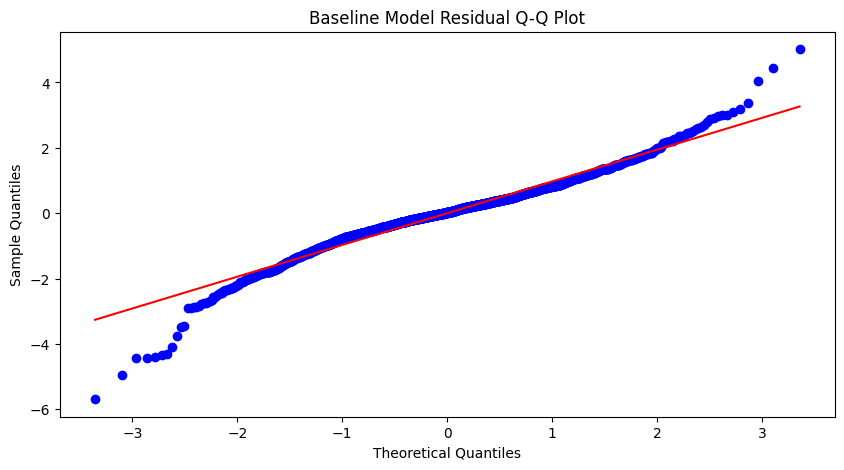

In [97]:
plt.figure(figsize=(10, 5))

stats.probplot(
    baseline_residuals,
    dist="norm",
    plot=plt
)

plt.title(
    "Baseline Model Residual Q-Q Plot"
)

plt.xlabel(
    "Theoretical Quantiles"
)

plt.ylabel(
    "Sample Quantiles"
)

plt.show()

#### VADER Combined

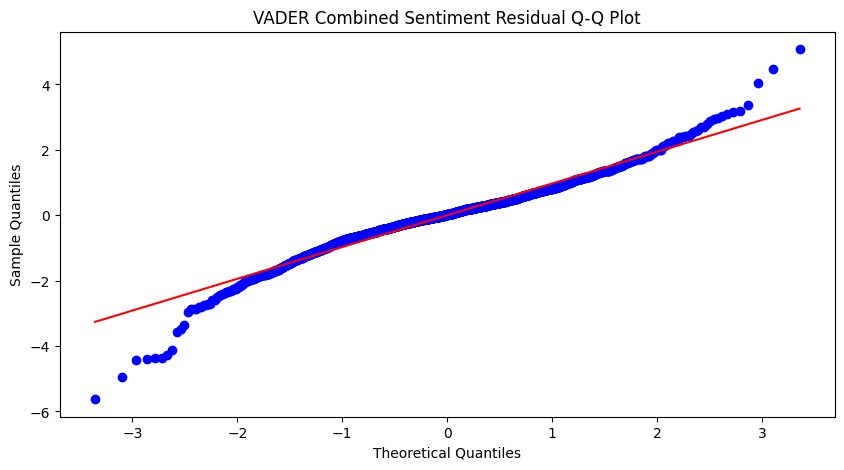

In [98]:
plt.figure(figsize=(10, 5))

stats.probplot(
    vader_sentiment_residuals,
    dist="norm",
    plot=plt
)

plt.title(
    "VADER Combined Sentiment Residual Q-Q Plot"
)

plt.xlabel(
    "Theoretical Quantiles"
)

plt.ylabel(
    "Sample Quantiles"
)

plt.show()

#### VADER Divided

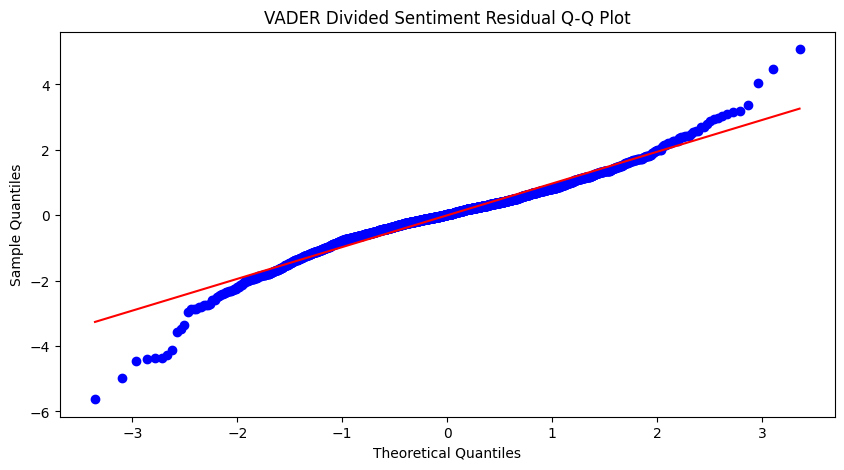

In [99]:
plt.figure(figsize=(10, 5))

stats.probplot(
    vader_divided_sentiment_residuals,
    dist="norm",
    plot=plt
)

plt.title(
    "VADER Divided Sentiment Residual Q-Q Plot"
)

plt.xlabel(
    "Theoretical Quantiles"
)

plt.ylabel(
    "Sample Quantiles"
)

plt.show()

#### FinBERT Combined

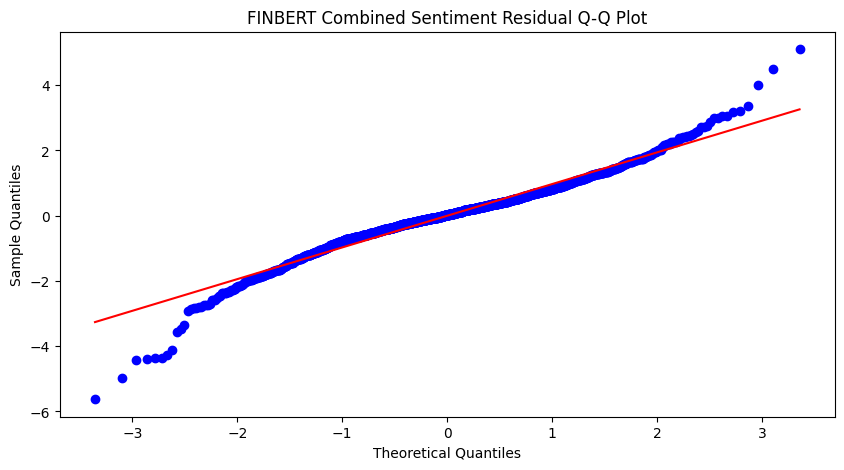

In [100]:
plt.figure(figsize=(10, 5))

stats.probplot(
    finbert_sentiment_residuals,
    dist="norm",
    plot=plt
)

plt.title(
    "FINBERT Combined Sentiment Residual Q-Q Plot"
)

plt.xlabel(
    "Theoretical Quantiles"
)

plt.ylabel(
    "Sample Quantiles"
)

plt.show()

#### FinBERT Divided

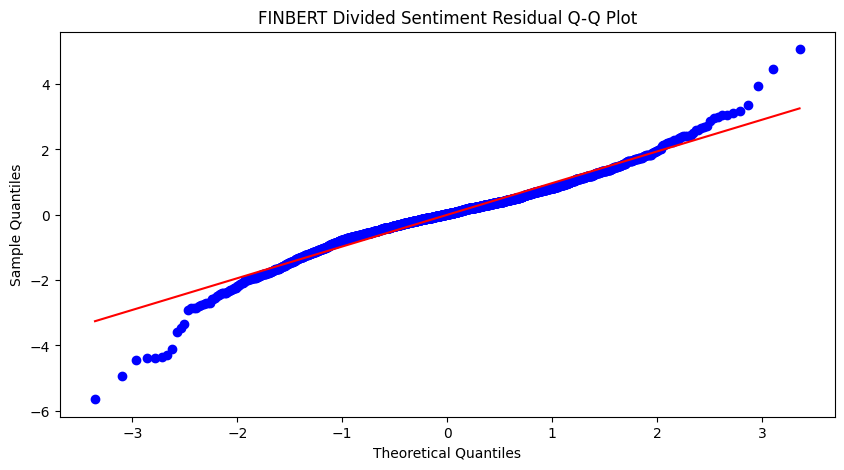

In [101]:
plt.figure(figsize=(10, 5))

stats.probplot(
    finbert_divided_sentiment_residuals,
    dist="norm",
    plot=plt
)

plt.title(
    "FINBERT Divided Sentiment Residual Q-Q Plot"
)

plt.xlabel(
    "Theoretical Quantiles"
)

plt.ylabel(
    "Sample Quantiles"
)

plt.show()

#### 8.4 Actual vs. Fitted Values

#### Combined

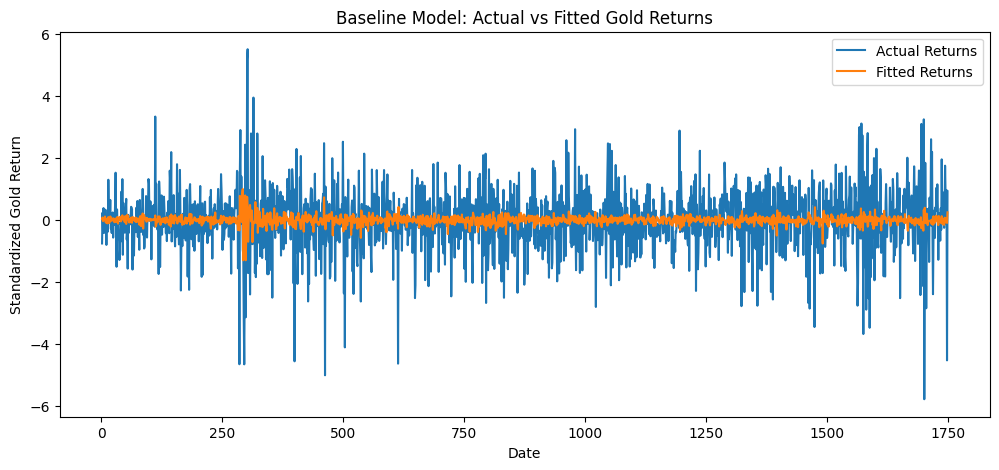

In [102]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_baseline_model.index,
    y_baseline_model,
    label="Actual Returns"
)

plt.plot(
    y_baseline_model.index,
    baseline_pred,
    label="Fitted Returns"
)

plt.title(
    "Baseline Model: Actual vs Fitted Gold Returns"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Standardized Gold Return"
)

plt.legend()

plt.show()

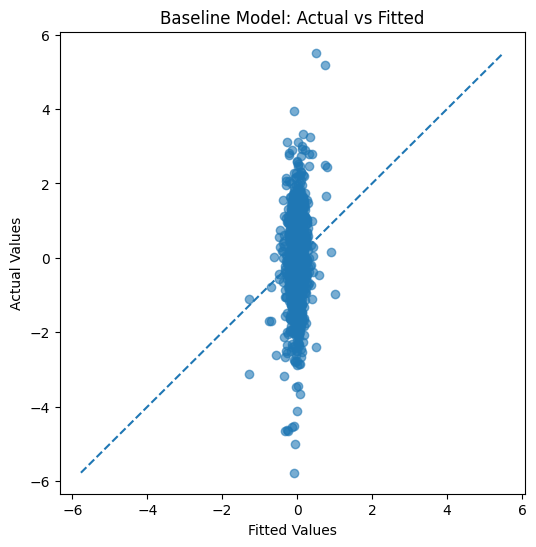

In [103]:
plt.figure(figsize=(6, 6))

plt.scatter(
    baseline_pred,
    y_baseline_model,
    alpha=0.6
)

plt.plot(
    [
        y_baseline_model.min(),
        y_baseline_model.max()
    ],
    [
        y_baseline_model.min(),
        y_baseline_model.max()
    ],
    linestyle="--"
)

plt.title(
    "Baseline Model: Actual vs Fitted"
)

plt.xlabel(
    "Fitted Values"
)

plt.ylabel(
    "Actual Values"
)

plt.show()

#### VADER

#### Combined

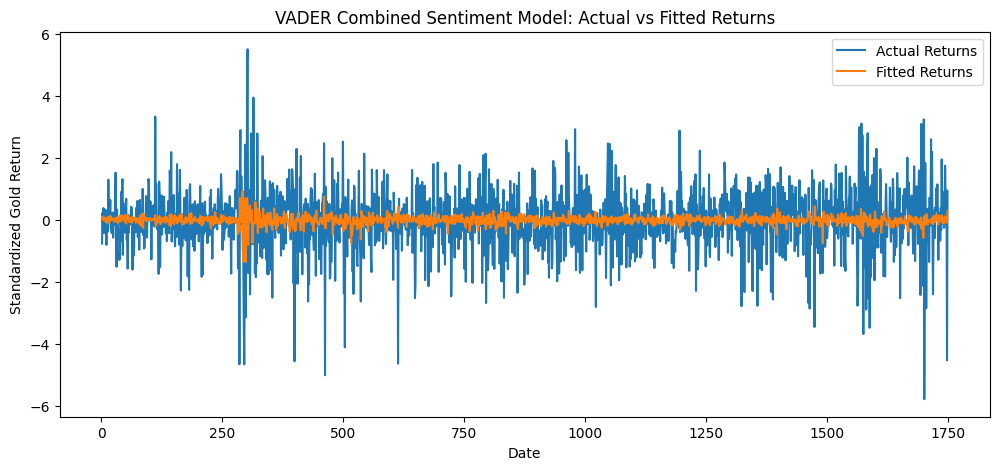

In [104]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_vader_sentiment_model.index,
    y_vader_sentiment_model,
    label="Actual Returns"
)

plt.plot(
    y_vader_sentiment_model.index,
    vader_sentiment_pred,
    label="Fitted Returns"
)

plt.title(
    "VADER Combined Sentiment Model: Actual vs Fitted Returns"
)

plt.xlabel(
   "Date"
)

plt.ylabel(
    "Standardized Gold Return"
)

plt.legend()

plt.show()

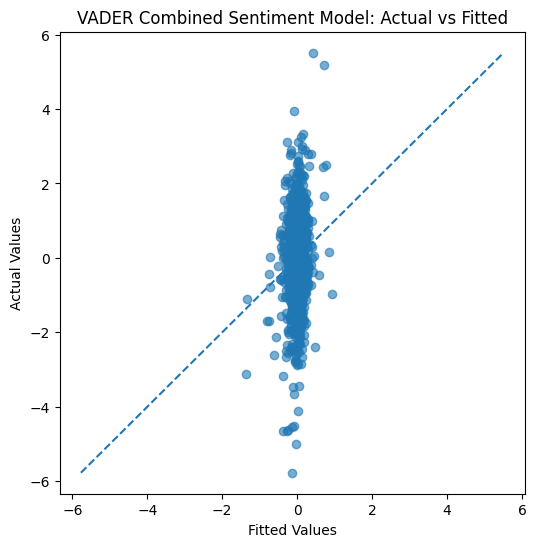

In [105]:
plt.figure(figsize=(6, 6))

plt.scatter(
    vader_sentiment_pred,
    y_vader_sentiment_model,
    alpha=0.6
)

plt.plot(
    [
        y_vader_sentiment_model.min(),
        y_vader_sentiment_model.max()
    ],
    [
        y_vader_sentiment_model.min(),
        y_vader_sentiment_model.max()
    ],
    linestyle="--"
)

plt.title(
    "VADER Combined Sentiment Model: Actual vs Fitted"
)

plt.xlabel(
    "Fitted Values"
)

plt.ylabel(
    "Actual Values"
)

plt.show()

#### Divided

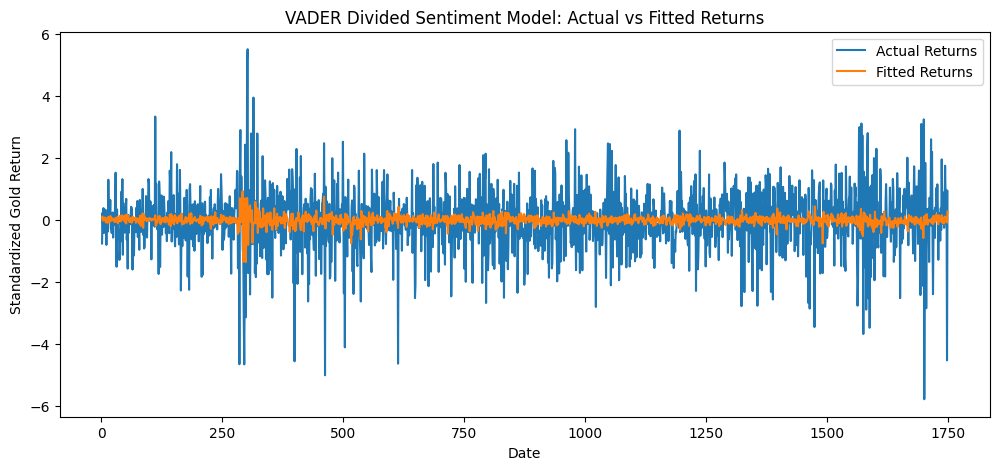

In [106]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_vader_divided_sentiment_model.index,
    y_vader_divided_sentiment_model,
    label="Actual Returns"
)

plt.plot(
    y_vader_divided_sentiment_model.index,
    vader_divided_sentiment_pred,
    label="Fitted Returns"
)

plt.title(
    "VADER Divided Sentiment Model: Actual vs Fitted Returns"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Standardized Gold Return"
)

plt.legend()

plt.show()

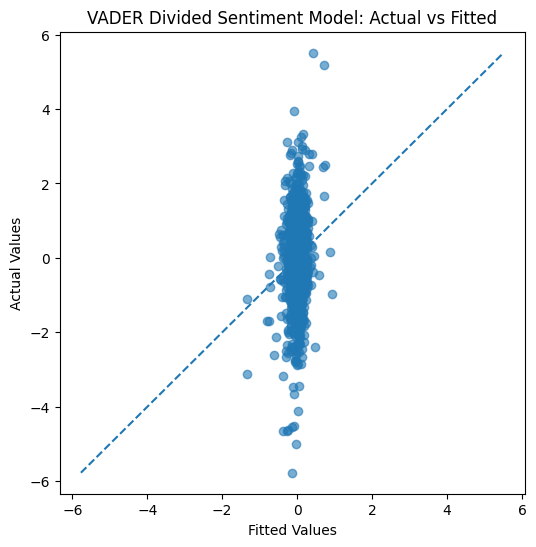

In [107]:
plt.figure(figsize=(6, 6))

plt.scatter(
    vader_divided_sentiment_pred,
    y_vader_divided_sentiment_model,
    alpha=0.6
)

plt.plot(
    [
        y_vader_divided_sentiment_model.min(),
        y_vader_divided_sentiment_model.max()
    ],
    [
        y_vader_divided_sentiment_model.min(),
        y_vader_divided_sentiment_model.max()
    ],
    linestyle="--"
)

plt.title(
    "VADER Divided Sentiment Model: Actual vs Fitted"
)

plt.xlabel(
    "Fitted Values"
)

plt.ylabel(
    "Actual Values"
)

plt.show()

#### FinBERT

#### Combined

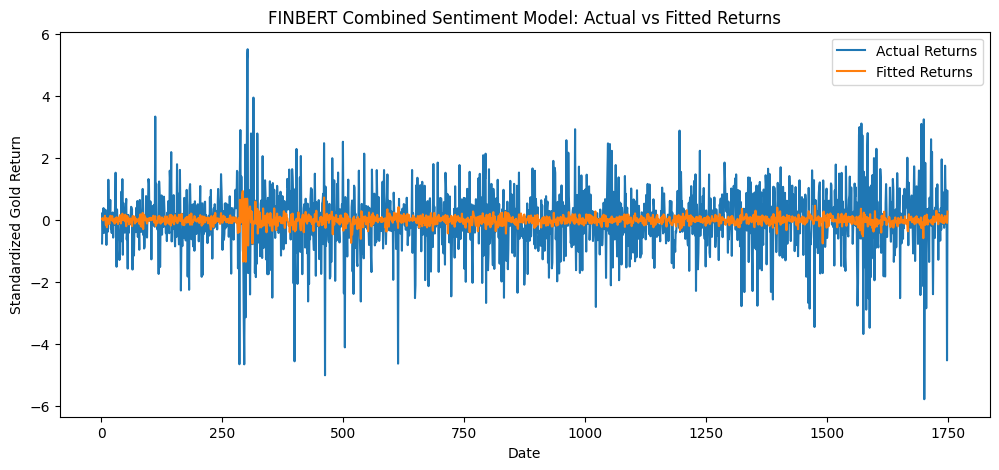

In [108]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_finbert_sentiment_model.index,
    y_finbert_sentiment_model,
    label="Actual Returns"
)

plt.plot(
    y_finbert_sentiment_model.index,
    finbert_sentiment_pred,
    label="Fitted Returns"
)

plt.title(
    "FINBERT Combined Sentiment Model: Actual vs Fitted Returns"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Standardized Gold Return"
)

plt.legend()

plt.show()

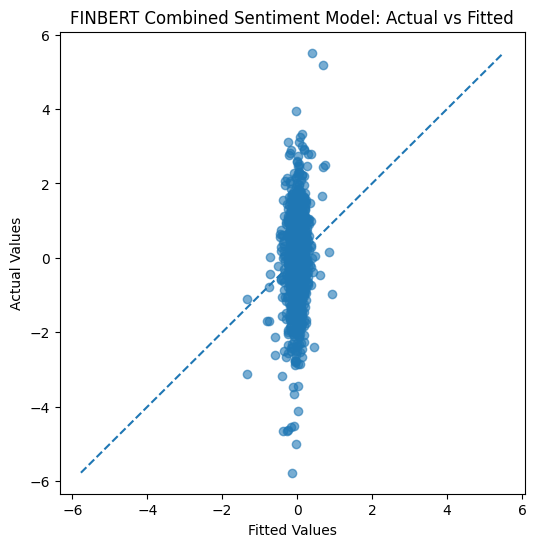

In [109]:
plt.figure(figsize=(6, 6))

plt.scatter(
    finbert_sentiment_pred,
    y_finbert_sentiment_model,
    alpha=0.6
)

plt.plot(
    [
        y_finbert_sentiment_model.min(),
        y_finbert_sentiment_model.max()
    ],
    [
        y_finbert_sentiment_model.min(),
        y_finbert_sentiment_model.max()
    ],
    linestyle="--"
)

plt.title(
    "FINBERT Combined Sentiment Model: Actual vs Fitted"
)

plt.xlabel(
    "Fitted Values"
)

plt.ylabel(
    "Actual Values"
)

plt.show()

#### Divided

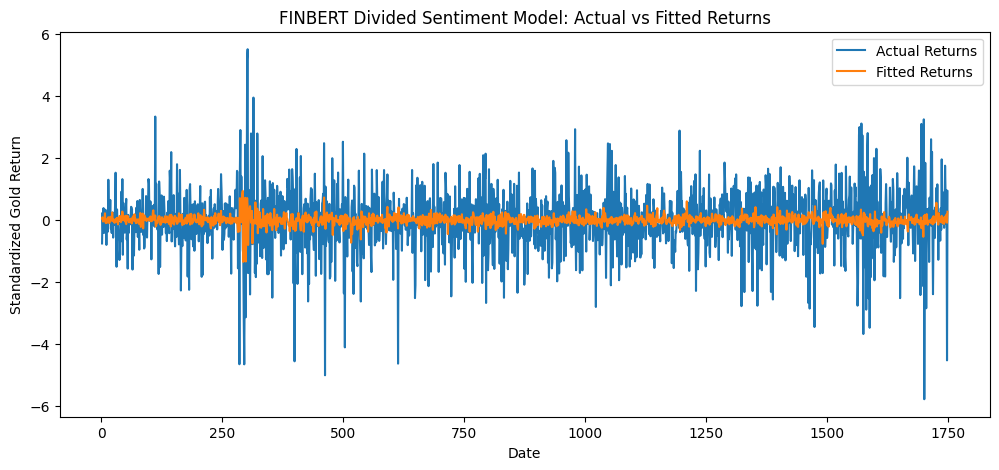

In [110]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_finbert_divided_sentiment_model.index,
    y_finbert_divided_sentiment_model,
    label="Actual Returns"
)

plt.plot(
    y_finbert_divided_sentiment_model.index,
    finbert_divided_sentiment_pred,
    label="Fitted Returns"
)

plt.title(
    "FINBERT Divided Sentiment Model: Actual vs Fitted Returns"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Standardized Gold Return"
)

plt.legend()

plt.show()

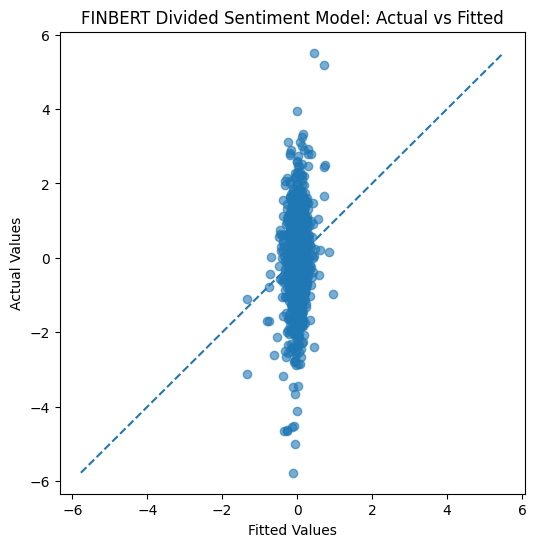

In [111]:
plt.figure(figsize=(6, 6))

plt.scatter(
    finbert_divided_sentiment_pred,
    y_finbert_divided_sentiment_model,
    alpha=0.6
)

plt.plot(
    [
        y_finbert_divided_sentiment_model.min(),
        y_finbert_divided_sentiment_model.max()
    ],
    [
        y_finbert_divided_sentiment_model.min(),
        y_finbert_divided_sentiment_model.max()
    ],
    linestyle="--"
)

plt.title(
    "FINBERT Divided Sentiment Model: Actual vs Fitted"
)

plt.xlabel(
    "Fitted Values"
)

plt.ylabel(
    "Actual Values"
)

plt.show()

## 9. Jarque-Berra Test

#### 9.1 Base Model

In [112]:
print("JARQUE-BERA TEST: BASELINE MODEL")
print("-" * 60)

jb_baseline = jarque_bera(
    baseline_residuals
)

print(f"JB Statistic: {jb_baseline[0]:.4f}")
print(f"P-value: {jb_baseline[1]:.4f}")
print(f"Skewness: {jb_baseline[2]:.4f}")
print(f"Kurtosis: {jb_baseline[3]:.4f}")

print("\nInterpretation:")
print("- Null hypothesis: residuals are normally distributed.")
print("- P-value > 0.05:")
print("  Fail to reject the null.")
print("  Residuals are consistent with normality.")
print("- P-value < 0.05:")
print("  Reject the null.")
print("  Residuals are not normally distributed.")

JARQUE-BERA TEST: BASELINE MODEL
------------------------------------------------------------
JB Statistic: 755.2277
P-value: 0.0000
Skewness: -0.3947
Kurtosis: 6.1247

Interpretation:
- Null hypothesis: residuals are normally distributed.
- P-value > 0.05:
  Fail to reject the null.
  Residuals are consistent with normality.
- P-value < 0.05:
  Reject the null.
  Residuals are not normally distributed.


#### 9.2 VADER

In [113]:
print("JARQUE-BERA TEST: VADER COMBINED SENTIMENT MODEL")
print("-" * 60)

jb_vader_sentiment = jarque_bera(
    vader_sentiment_residuals
)

print(f"JB Statistic: {jb_vader_sentiment[0]:.4f}")
print(f"P-value: {jb_vader_sentiment[1]:.4f}")
print(f"Skewness: {jb_vader_sentiment[2]:.4f}")
print(f"Kurtosis: {jb_vader_sentiment[3]:.4f}")

print("\nInterpretation:")
print("- Null hypothesis: residuals are normally distributed.")
print("- P-value > 0.05 indicates normal residuals.")
print("- P-value < 0.05 indicates non-normal residuals.")

print("=" * 60)

print("JARQUE-BERA TEST: VADER DIVIDED SENTIMENT MODEL")
print("-" * 60)

jb_vader_divided = jarque_bera(
    vader_divided_sentiment_residuals
)

print(f"JB Statistic: {jb_vader_divided[0]:.4f}")
print(f"P-value: {jb_vader_divided[1]:.4f}")
print(f"Skewness: {jb_vader_divided[2]:.4f}")
print(f"Kurtosis: {jb_vader_divided[3]:.4f}")

print("\nInterpretation:")
print("- Null hypothesis: residuals are normally distributed.")
print("- P-value > 0.05 indicates normal residuals.")
print("- P-value < 0.05 indicates non-normal residuals.")



JARQUE-BERA TEST: VADER COMBINED SENTIMENT MODEL
------------------------------------------------------------
JB Statistic: 747.4028
P-value: 0.0000
Skewness: -0.3706
Kurtosis: 6.1193

Interpretation:
- Null hypothesis: residuals are normally distributed.
- P-value > 0.05 indicates normal residuals.
- P-value < 0.05 indicates non-normal residuals.
JARQUE-BERA TEST: VADER DIVIDED SENTIMENT MODEL
------------------------------------------------------------
JB Statistic: 748.0160
P-value: 0.0000
Skewness: -0.3714
Kurtosis: 6.1203

Interpretation:
- Null hypothesis: residuals are normally distributed.
- P-value > 0.05 indicates normal residuals.
- P-value < 0.05 indicates non-normal residuals.


#### 9.3 FinBERT

In [114]:
print("JARQUE-BERA TEST: FINBERT COMBINED SENTIMENT MODEL")
print("-" * 60)

jb_finbert_sentiment = jarque_bera(
    finbert_sentiment_residuals
)

print(f"JB Statistic: {jb_finbert_sentiment[0]:.4f}")
print(f"P-value: {jb_finbert_sentiment[1]:.4f}")
print(f"Skewness: {jb_finbert_sentiment[2]:.4f}")
print(f"Kurtosis: {jb_finbert_sentiment[3]:.4f}")

print("\nInterpretation:")
print("- Null hypothesis: residuals are normally distributed.")
print("- P-value > 0.05 indicates normal residuals.")
print("- P-value < 0.05 indicates non-normal residuals.")

print("=" * 60)


print("JARQUE-BERA TEST: FINBERT DIVIDED SENTIMENT MODEL")
print("-" * 60)

jb_finbert_divided = jarque_bera(
    finbert_divided_sentiment_residuals
)

print(f"JB Statistic: {jb_finbert_divided[0]:.4f}")
print(f"P-value: {jb_finbert_divided[1]:.4f}")
print(f"Skewness: {jb_finbert_divided[2]:.4f}")
print(f"Kurtosis: {jb_finbert_divided[3]:.4f}")

print("\nInterpretation:")
print("- Null hypothesis: residuals are normally distributed.")
print("- P-value > 0.05 indicates normal residuals.")
print("- P-value < 0.05 indicates non-normal residuals.")

JARQUE-BERA TEST: FINBERT COMBINED SENTIMENT MODEL
------------------------------------------------------------
JB Statistic: 746.3606
P-value: 0.0000
Skewness: -0.3618
Kurtosis: 6.1211

Interpretation:
- Null hypothesis: residuals are normally distributed.
- P-value > 0.05 indicates normal residuals.
- P-value < 0.05 indicates non-normal residuals.
JARQUE-BERA TEST: FINBERT DIVIDED SENTIMENT MODEL
------------------------------------------------------------
JB Statistic: 743.4913
P-value: 0.0000
Skewness: -0.3706
Kurtosis: 6.1107

Interpretation:
- Null hypothesis: residuals are normally distributed.
- P-value > 0.05 indicates normal residuals.
- P-value < 0.05 indicates non-normal residuals.


## 10. Additional Robustness Checks

#### 10.1 VADER

In [115]:
df.head(5)

,date,average_daily_sentiment,gold_related_posts,log_gold_posts,logVolETF_t,Gold_Spot_Price,VIX,S&P_500,USD_Index,10Y_UST_Yield,...,return_lag5,return_lag6,return_lag7,return_lag8,return_lag9,return_lag10,positive_sentiment,negative_sentiment,positive_sentiment_lag1,negative_sentiment_lag1
0,2019-01-02,0.44315,4,1.386294,17.126246,1281.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.44315,0.0000,NaN,NaN
1,2019-01-03,0.31283,10,2.302585,17.300438,1291.800049,0.091702,-0.025068,-0.005281,-0.041041,...,NaN,NaN,NaN,NaN,NaN,NaN,0.31283,0.0000,1.864807,0.366763
2,2019-01-04,0.21075,4,1.386294,17.215232,1282.699951,-0.174260,0.033759,-0.001247,0.040289,...,NaN,NaN,NaN,NaN,NaN,NaN,0.21075,0.0000,1.028114,0.366763
3,2019-01-07,0.87360,1,0.000000,16.639853,1286.800049,0.000935,0.006986,-0.005003,0.008613,...,NaN,NaN,NaN,NaN,NaN,NaN,0.87360,0.0000,0.372731,0.366763
4,2019-01-08,-0.34120,3,1.098612,16.626597,1283.199951,-0.044431,0.009649,0.001983,0.012597,...,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,-0.3412,4.628423,0.366763


In [116]:
# splitting by dates
df["date"] = pd.to_datetime(df["date"])

df_vader_2019_2022 = df[
    (df["date"] >= "2019-01-01") &
    (df["date"] <= "2022-12-31")
]

df_vader_2023_2025 = df[
    (df["date"] >= "2023-01-01") &
    (df["date"] <= "2025-12-31")
]

#### 2019 - 2022

#### Combined Sentiment

In [117]:
vader_X_vars_2019_2022_combined = [
    "sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

for i in range(1, chosen_lag_vader + 1):
    vader_X_vars_2019_2022_combined.append(
        f"return_lag{i}"
    )

vader_scale_cols_2019_2022_combined = (
    ["gold_return"] +
    vader_X_vars_2019_2022_combined
)

vader_scaler_2019_2022_combined = (
    StandardScaler()
)

df_vader_2019_2022[
    vader_scale_cols_2019_2022_combined
] = vader_scaler_2019_2022_combined.fit_transform(
    df_vader_2019_2022[
        vader_scale_cols_2019_2022_combined
    ]
)

vader_y_2019_2022_combined = (
    df_vader_2019_2022["gold_return"]
)

vader_X_2019_2022_combined = (
    df_vader_2019_2022[
        vader_X_vars_2019_2022_combined
    ]
)

vader_X_2019_2022_combined = sm.add_constant(
    vader_X_2019_2022_combined
)

vader_reg_df_2019_2022_combined = pd.concat(
    [
        vader_y_2019_2022_combined,
        vader_X_2019_2022_combined
    ],
    axis=1
).dropna()

vader_y_model_2019_2022_combined = (
    vader_reg_df_2019_2022_combined[
        "gold_return"
    ]
)

vader_X_model_2019_2022_combined = (
    vader_reg_df_2019_2022_combined.drop(
        columns=["gold_return"]
    )
)

vader_model_2019_2022_combined = sm.OLS(
    vader_y_model_2019_2022_combined,
    vader_X_model_2019_2022_combined
)

vader_results_2019_2022_combined = (
    vader_model_2019_2022_combined.fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
)

vader_predictions_2019_2022_combined = (
    vader_results_2019_2022_combined.predict(
        vader_X_model_2019_2022_combined
    )
)

vader_residuals_2019_2022_combined = (
    vader_y_model_2019_2022_combined -
    vader_predictions_2019_2022_combined
)

print(
    vader_results_2019_2022_combined.summary()
)

                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     2.085
Date:                Mon, 25 May 2026   Prob (F-statistic):             0.0347
Time:                        16:19:25   Log-Likelihood:                -1400.8
No. Observations:                 999   AIC:                             2820.
Df Residuals:                     990   BIC:                             2864.
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0008      0

/var/folders/04/65nvv_ld27j0dndh3hxb04hc0000gn/T/ipykernel_49263/4271883754.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vader_2019_2022[


#### Separated Sentiment

In [118]:
vader_X_vars_2019_2022_separated = [
    "positive_sentiment_lag1",
    "negative_sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

for i in range(1, chosen_lag_vader + 1):
    vader_X_vars_2019_2022_separated.append(
        f"return_lag{i}"
    )

vader_scale_cols_2019_2022_separated = (
    ["gold_return"] +
    vader_X_vars_2019_2022_separated
)

vader_scaler_2019_2022_separated = (
    StandardScaler()
)

df_vader_2019_2022[
    vader_scale_cols_2019_2022_separated
] = vader_scaler_2019_2022_separated.fit_transform(
    df_vader_2019_2022[
        vader_scale_cols_2019_2022_separated
    ]
)

vader_y_2019_2022_separated = (
    df_vader_2019_2022["gold_return"]
)

vader_X_2019_2022_separated = (
    df_vader_2019_2022[
        vader_X_vars_2019_2022_separated
    ]
)

vader_X_2019_2022_separated = sm.add_constant(
    vader_X_2019_2022_separated
)

vader_reg_df_2019_2022_separated = pd.concat(
    [
        vader_y_2019_2022_separated,
        vader_X_2019_2022_separated
    ],
    axis=1
).dropna()

vader_y_model_2019_2022_separated = (
    vader_reg_df_2019_2022_separated[
        "gold_return"
    ]
)

vader_X_model_2019_2022_separated = (
    vader_reg_df_2019_2022_separated.drop(
        columns=["gold_return"]
    )
)

vader_model_2019_2022_separated = sm.OLS(
    vader_y_model_2019_2022_separated,
    vader_X_model_2019_2022_separated
)

vader_results_2019_2022_separated = (
    vader_model_2019_2022_separated.fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
)

vader_predictions_2019_2022_separated = (
    vader_results_2019_2022_separated.predict(
        vader_X_model_2019_2022_separated
    )
)

vader_residuals_2019_2022_separated = (
    vader_y_model_2019_2022_separated -
    vader_predictions_2019_2022_separated
)

print(
    vader_results_2019_2022_separated.summary()
)


                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     1.875
Date:                Mon, 25 May 2026   Prob (F-statistic):             0.0521
Time:                        16:19:25   Log-Likelihood:                -1400.7
No. Observations:                 999   AIC:                             2821.
Df Residuals:                     989   BIC:                             2871.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

/var/folders/04/65nvv_ld27j0dndh3hxb04hc0000gn/T/ipykernel_49263/2153738911.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vader_2019_2022[


#### 2023 - 2025

#### Combined Sentiment

In [119]:
vader_X_vars_2023_2025_combined = [
    "sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

for i in range(1, chosen_lag_vader + 1):
    vader_X_vars_2023_2025_combined.append(
        f"return_lag{i}"
    )

vader_scale_cols_2023_2025_combined = (
    ["gold_return"] +
    vader_X_vars_2023_2025_combined
)

vader_scaler_2023_2025_combined = (
    StandardScaler()
)

df_vader_2023_2025[
    vader_scale_cols_2023_2025_combined
] = vader_scaler_2023_2025_combined.fit_transform(
    df_vader_2023_2025[
        vader_scale_cols_2023_2025_combined
    ]
)

vader_y_2023_2025_combined = (
    df_vader_2023_2025["gold_return"]
)

vader_X_2023_2025_combined = (
    df_vader_2023_2025[
        vader_X_vars_2023_2025_combined
    ]
)

vader_X_2023_2025_combined = sm.add_constant(
    vader_X_2023_2025_combined
)

vader_reg_df_2023_2025_combined = pd.concat(
    [
        vader_y_2023_2025_combined,
        vader_X_2023_2025_combined
    ],
    axis=1
).dropna()

vader_y_model_2023_2025_combined = (
    vader_reg_df_2023_2025_combined[
        "gold_return"
    ]
)

vader_X_model_2023_2025_combined = (
    vader_reg_df_2023_2025_combined.drop(
        columns=["gold_return"]
    )
)

vader_model_2023_2025_combined = sm.OLS(
    vader_y_model_2023_2025_combined,
    vader_X_model_2023_2025_combined
)

vader_results_2023_2025_combined = (
    vader_model_2023_2025_combined.fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
)

vader_predictions_2023_2025_combined = (
    vader_results_2023_2025_combined.predict(
        vader_X_model_2023_2025_combined
    )
)

vader_residuals_2023_2025_combined = (
    vader_y_model_2023_2025_combined -
    vader_predictions_2023_2025_combined
)

print(
    vader_results_2023_2025_combined.summary()
)


                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.233
Date:                Mon, 25 May 2026   Prob (F-statistic):              0.276
Time:                        16:19:25   Log-Likelihood:                -1053.0
No. Observations:                 746   AIC:                             2124.
Df Residuals:                     737   BIC:                             2166.
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0018      0

/var/folders/04/65nvv_ld27j0dndh3hxb04hc0000gn/T/ipykernel_49263/3353833017.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vader_2023_2025[


#### Separated Sentiment

In [120]:
vader_X_vars_2023_2025_separated = [
    "positive_sentiment_lag1",
    "negative_sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

for i in range(1, chosen_lag_vader + 1):
    vader_X_vars_2023_2025_separated.append(
        f"return_lag{i}"
    )

vader_scale_cols_2023_2025_separated = (
    ["gold_return"] +
    vader_X_vars_2023_2025_separated
)

vader_scaler_2023_2025_separated = (
    StandardScaler()
)

df_vader_2023_2025[
    vader_scale_cols_2023_2025_separated
] = vader_scaler_2023_2025_separated.fit_transform(
    df_vader_2023_2025[
        vader_scale_cols_2023_2025_separated
    ]
)

vader_y_2023_2025_separated = (
    df_vader_2023_2025["gold_return"]
)

vader_X_2023_2025_separated = (
    df_vader_2023_2025[
        vader_X_vars_2023_2025_separated
    ]
)

vader_X_2023_2025_separated = sm.add_constant(
    vader_X_2023_2025_separated
)

vader_reg_df_2023_2025_separated = pd.concat(
    [
        vader_y_2023_2025_separated,
        vader_X_2023_2025_separated
    ],
    axis=1
).dropna()

vader_y_model_2023_2025_separated = (
    vader_reg_df_2023_2025_separated[
        "gold_return"
    ]
)

vader_X_model_2023_2025_separated = (
    vader_reg_df_2023_2025_separated.drop(
        columns=["gold_return"]
    )
)

vader_model_2023_2025_separated = sm.OLS(
    vader_y_model_2023_2025_separated,
    vader_X_model_2023_2025_separated
)

vader_results_2023_2025_separated = (
    vader_model_2023_2025_separated.fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
)

vader_predictions_2023_2025_separated = (
    vader_results_2023_2025_separated.predict(
        vader_X_model_2023_2025_separated
    )
)

vader_residuals_2023_2025_separated = (
    vader_y_model_2023_2025_separated -
    vader_predictions_2023_2025_separated
)

print(
    vader_results_2023_2025_separated.summary()
)


                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.228
Date:                Mon, 25 May 2026   Prob (F-statistic):              0.274
Time:                        16:19:25   Log-Likelihood:                -1052.8
No. Observations:                 746   AIC:                             2126.
Df Residuals:                     736   BIC:                             2172.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

/var/folders/04/65nvv_ld27j0dndh3hxb04hc0000gn/T/ipykernel_49263/1536612699.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vader_2023_2025[


#### 10.2 FinBERT

In [121]:
df2.head(5)

,date,average_daily_sentiment,gold_related_posts,log_gold_posts,logVolETF_t,Gold_Spot_Price,VIX,S&P_500,USD_Index,10Y_UST_Yield,...,return_lag5,return_lag6,return_lag7,return_lag8,return_lag9,return_lag10,positive_sentiment,negative_sentiment,positive_sentiment_lag1,negative_sentiment_lag1
0,2019-01-02,-0.160799,4,1.386294,17.126246,1281.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.160799,NaN,NaN
1,2019-01-03,-0.126003,10,2.302585,17.300438,1291.800049,0.091702,-0.025068,-0.005281,-0.041041,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.126003,-0.421993,-1.053400
2,2019-01-04,-0.209705,4,1.386294,17.215232,1282.699951,-0.174260,0.033759,-0.001247,0.040289,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.209705,-0.421993,-0.666420
3,2019-01-07,-0.009005,1,0.000000,16.639853,1286.800049,0.000935,0.006986,-0.005003,0.008613,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.009005,-0.421993,-1.597299
4,2019-01-08,-0.011035,3,1.098612,16.626597,1283.199951,-0.044431,0.009649,0.001983,0.012597,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.011035,-0.421993,0.634753


In [122]:
df2["date"] = pd.to_datetime(df2["date"])

# Split by years
df_finbert_2019_2022 = df2[
    (df2["date"] >= "2019-01-01") &
    (df2["date"] <= "2022-12-31")
]

df_finbert_2023_2025 = df2[
    (df2["date"] >= "2023-01-01") &
    (df2["date"] <= "2025-12-31")
]

#### 2019 - 2022

#### Combined Sentiment

In [123]:
finbert_X_vars_2019_2022_combined = [
    "sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

for i in range(1, chosen_lag_finbert + 1):
    finbert_X_vars_2019_2022_combined.append(
        f"return_lag{i}"
    )

finbert_scale_cols_2019_2022_combined = (
    ["gold_return"] +
    finbert_X_vars_2019_2022_combined
)

finbert_scaler_2019_2022_combined = (
    StandardScaler()
)

df_finbert_2019_2022[
    finbert_scale_cols_2019_2022_combined
] = finbert_scaler_2019_2022_combined.fit_transform(
    df_finbert_2019_2022[
        finbert_scale_cols_2019_2022_combined
    ]
)

finbert_y_2019_2022_combined = (
    df_finbert_2019_2022["gold_return"]
)

finbert_X_2019_2022_combined = (
    df_finbert_2019_2022[
        finbert_X_vars_2019_2022_combined
    ]
)

finbert_X_2019_2022_combined = sm.add_constant(
    finbert_X_2019_2022_combined
)

finbert_reg_df_2019_2022_combined = pd.concat(
    [
        finbert_y_2019_2022_combined,
        finbert_X_2019_2022_combined
    ],
    axis=1
).dropna()

finbert_y_model_2019_2022_combined = (
    finbert_reg_df_2019_2022_combined[
        "gold_return"
    ]
)

finbert_X_model_2019_2022_combined = (
    finbert_reg_df_2019_2022_combined.drop(
        columns=["gold_return"]
    )
)

finbert_model_2019_2022_combined = sm.OLS(
    finbert_y_model_2019_2022_combined,
    finbert_X_model_2019_2022_combined
)

finbert_results_2019_2022_combined = (
    finbert_model_2019_2022_combined.fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
)

finbert_predictions_2019_2022_combined = (
    finbert_results_2019_2022_combined.predict(
        finbert_X_model_2019_2022_combined
    )
)

finbert_residuals_2019_2022_combined = (
    finbert_y_model_2019_2022_combined -
    finbert_predictions_2019_2022_combined
)

print(
    finbert_results_2019_2022_combined.summary()
)

                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     2.062
Date:                Mon, 25 May 2026   Prob (F-statistic):             0.0369
Time:                        16:19:25   Log-Likelihood:                -1400.8
No. Observations:                 999   AIC:                             2820.
Df Residuals:                     990   BIC:                             2864.
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0008      0

/var/folders/04/65nvv_ld27j0dndh3hxb04hc0000gn/T/ipykernel_49263/1043356659.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_finbert_2019_2022[


#### Separated Sentiment

In [124]:
finbert_X_vars_2019_2022_separated = [
    "positive_sentiment_lag1",
    "negative_sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

for i in range(1, chosen_lag_finbert + 1):
    finbert_X_vars_2019_2022_separated.append(
        f"return_lag{i}"
    )

finbert_scale_cols_2019_2022_separated = (
    ["gold_return"] +
    finbert_X_vars_2019_2022_separated
)

finbert_scaler_2019_2022_separated = (
    StandardScaler()
)

df_finbert_2019_2022[
    finbert_scale_cols_2019_2022_separated
] = finbert_scaler_2019_2022_separated.fit_transform(
    df_finbert_2019_2022[
        finbert_scale_cols_2019_2022_separated
    ]
)

finbert_y_2019_2022_separated = (
    df_finbert_2019_2022["gold_return"]
)

finbert_X_2019_2022_separated = (
    df_finbert_2019_2022[
        finbert_X_vars_2019_2022_separated
    ]
)

finbert_X_2019_2022_separated = sm.add_constant(
    finbert_X_2019_2022_separated
)

finbert_reg_df_2019_2022_separated = pd.concat(
    [
        finbert_y_2019_2022_separated,
        finbert_X_2019_2022_separated
    ],
    axis=1
).dropna()

finbert_y_model_2019_2022_separated = (
    finbert_reg_df_2019_2022_separated[
        "gold_return"
    ]
)

finbert_X_model_2019_2022_separated = (
    finbert_reg_df_2019_2022_separated.drop(
        columns=["gold_return"]
    )
)

finbert_model_2019_2022_separated = sm.OLS(
    finbert_y_model_2019_2022_separated,
    finbert_X_model_2019_2022_separated
)

finbert_results_2019_2022_separated = (
    finbert_model_2019_2022_separated.fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
)

finbert_predictions_2019_2022_separated = (
    finbert_results_2019_2022_separated.predict(
        finbert_X_model_2019_2022_separated
    )
)

finbert_residuals_2019_2022_separated = (
    finbert_y_model_2019_2022_separated -
    finbert_predictions_2019_2022_separated
)

print(
    finbert_results_2019_2022_separated.summary()
)


                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     2.542
Date:                Mon, 25 May 2026   Prob (F-statistic):            0.00692
Time:                        16:19:25   Log-Likelihood:                -1397.8
No. Observations:                 999   AIC:                             2816.
Df Residuals:                     989   BIC:                             2865.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

/var/folders/04/65nvv_ld27j0dndh3hxb04hc0000gn/T/ipykernel_49263/2074267206.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_finbert_2019_2022[


#### 2023 - 2025

#### Combined Sentiment

In [125]:
finbert_X_vars_2023_2025_combined = [
    "sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

for i in range(1, chosen_lag_finbert + 1):
    finbert_X_vars_2023_2025_combined.append(
        f"return_lag{i}"
    )

finbert_scale_cols_2023_2025_combined = (
    ["gold_return"] +
    finbert_X_vars_2023_2025_combined
)

finbert_scaler_2023_2025_combined = (
    StandardScaler()
)

df_finbert_2023_2025[
    finbert_scale_cols_2023_2025_combined
] = finbert_scaler_2023_2025_combined.fit_transform(
    df_finbert_2023_2025[
        finbert_scale_cols_2023_2025_combined
    ]
)

finbert_y_2023_2025_combined = (
    df_finbert_2023_2025["gold_return"]
)

finbert_X_2023_2025_combined = (
    df_finbert_2023_2025[
        finbert_X_vars_2023_2025_combined
    ]
)

finbert_X_2023_2025_combined = sm.add_constant(
    finbert_X_2023_2025_combined
)

finbert_reg_df_2023_2025_combined = pd.concat(
    [
        finbert_y_2023_2025_combined,
        finbert_X_2023_2025_combined
    ],
    axis=1
).dropna()

finbert_y_model_2023_2025_combined = (
    finbert_reg_df_2023_2025_combined[
        "gold_return"
    ]
)

finbert_X_model_2023_2025_combined = (
    finbert_reg_df_2023_2025_combined.drop(
        columns=["gold_return"]
    )
)

finbert_model_2023_2025_combined = sm.OLS(
    finbert_y_model_2023_2025_combined,
    finbert_X_model_2023_2025_combined
)

finbert_results_2023_2025_combined = (
    finbert_model_2023_2025_combined.fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
)

finbert_predictions_2023_2025_combined = (
    finbert_results_2023_2025_combined.predict(
        finbert_X_model_2023_2025_combined
    )
)

finbert_residuals_2023_2025_combined = (
    finbert_y_model_2023_2025_combined -
    finbert_predictions_2023_2025_combined
)

print(
    finbert_results_2023_2025_combined.summary()
)


                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     2.036
Date:                Mon, 25 May 2026   Prob (F-statistic):             0.0399
Time:                        16:19:25   Log-Likelihood:                -1050.9
No. Observations:                 746   AIC:                             2120.
Df Residuals:                     737   BIC:                             2161.
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0021      0

/var/folders/04/65nvv_ld27j0dndh3hxb04hc0000gn/T/ipykernel_49263/3769220260.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_finbert_2023_2025[


#### Separated Sentiment

In [126]:
finbert_X_vars_2023_2025_separated = [
    "positive_sentiment_lag1",
    "negative_sentiment_lag1",
    "volsent_lag1",
    "logVolETF_lag1",
    "VIX_lag1",
    "S&P_500_lag1",
    "USD_Index_lag1",
    "10Y_UST_Yield_lag1"
]

for i in range(1, chosen_lag_finbert + 1):
    finbert_X_vars_2023_2025_separated.append(
        f"return_lag{i}"
    )

finbert_scale_cols_2023_2025_separated = (
    ["gold_return"] +
    finbert_X_vars_2023_2025_separated
)

finbert_scaler_2023_2025_separated = (
    StandardScaler()
)

df_finbert_2023_2025[
    finbert_scale_cols_2023_2025_separated
] = finbert_scaler_2023_2025_separated.fit_transform(
    df_finbert_2023_2025[
        finbert_scale_cols_2023_2025_separated
    ]
)

finbert_y_2023_2025_separated = (
    df_finbert_2023_2025["gold_return"]
)

finbert_X_2023_2025_separated = (
    df_finbert_2023_2025[
        finbert_X_vars_2023_2025_separated
    ]
)

finbert_X_2023_2025_separated = sm.add_constant(
    finbert_X_2023_2025_separated
)

finbert_reg_df_2023_2025_separated = pd.concat(
    [
        finbert_y_2023_2025_separated,
        finbert_X_2023_2025_separated
    ],
    axis=1
).dropna()

finbert_y_model_2023_2025_separated = (
    finbert_reg_df_2023_2025_separated[
        "gold_return"
    ]
)

finbert_X_model_2023_2025_separated = (
    finbert_reg_df_2023_2025_separated.drop(
        columns=["gold_return"]
    )
)

finbert_model_2023_2025_separated = sm.OLS(
    finbert_y_model_2023_2025_separated,
    finbert_X_model_2023_2025_separated
)

finbert_results_2023_2025_separated = (
    finbert_model_2023_2025_separated.fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
)

finbert_predictions_2023_2025_separated = (
    finbert_results_2023_2025_separated.predict(
        finbert_X_model_2023_2025_separated
    )
)

finbert_residuals_2023_2025_separated = (
    finbert_y_model_2023_2025_separated -
    finbert_predictions_2023_2025_separated
)

print(
    finbert_results_2023_2025_separated.summary()
)

                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     1.834
Date:                Mon, 25 May 2026   Prob (F-statistic):             0.0589
Time:                        16:19:25   Log-Likelihood:                -1050.8
No. Observations:                 746   AIC:                             2122.
Df Residuals:                     736   BIC:                             2168.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

/var/folders/04/65nvv_ld27j0dndh3hxb04hc0000gn/T/ipykernel_49263/3595971738.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_finbert_2023_2025[


## Visualization

In [127]:
combined_stargazer = Stargazer([
    vader_results_2019_2022_combined,
    vader_results_2023_2025_combined,
    finbert_results_2019_2022_combined,
    finbert_results_2023_2025_combined
])

# title
combined_stargazer.title(
    "Regression Results: Combined Reddit Sentiment and Gold Returns"
)

# column names
combined_stargazer.custom_columns(
    [
        "VADER\n2019-2022",
        "VADER\n2023-2025",
        "FinBERT\n2019-2022",
        "FinBERT\n2023-2025"
    ],
    [1, 1, 1, 1]
)

# defining significance levels
combined_stargazer.significance_levels(
    [.10, .05, .01]
)

# renaming variables
combined_stargazer.rename_covariates({
    "const": "Constant",
    "sentiment_lag1": "Sentiment (t-1)",
    "volsent_lag1": "Sentiment Volume (t-1)",
    "logVolETF_lag1": "ETF Volume (t-1)",
    "VIX_lag1": "VIX (t-1)",
    "S&P_500_lag1": "S&P 500 (t-1)",
    "USD_Index_lag1": "USD Index (t-1)",
    "10Y_UST_Yield_lag1": "10Y Treasury Yield (t-1)"
})

# cleaner appearance
combined_stargazer.show_degrees_of_freedom(False)
combined_stargazer.show_f_statistic = False
combined_stargazer.show_residual_std_err = False

# displaying combined table
print("Combined Sentiment Table:")
display(
    HTML(
        combined_stargazer.render_html()
    )
)

# exporting latex
with open(
    "combined_sentiment_table.tex",
    "w"
) as f:
    f.write(
        combined_stargazer.render_latex()
    )


# separated sentiment models
separated_stargazer = Stargazer([
    vader_results_2019_2022_separated,
    vader_results_2023_2025_separated,
    finbert_results_2019_2022_separated,
    finbert_results_2023_2025_separated
])

# title
separated_stargazer.title(
    "Regression Results: Positive and Negative Reddit Sentiment and Gold Returns"
)

# column names
separated_stargazer.custom_columns(
    [
        "VADER\n2019-2022",
        "VADER\n2023-2025",
        "FinBERT\n2019-2022",
        "FinBERT\n2023-2025"
    ],
    [1, 1, 1, 1]
)

# defining significance levels
separated_stargazer.significance_levels(
    [.10, .05, .01]
)

# renaming variables
separated_stargazer.rename_covariates({
    "const": "Constant",
    "positive_sentiment_lag1": "Positive Sentiment (t-1)",
    "negative_sentiment_lag1": "Negative Sentiment (t-1)",
    "volsent_lag1": "Sentiment Volume (t-1)",
    "logVolETF_lag1": "ETF Volume (t-1)",
    "VIX_lag1": "VIX (t-1)",
    "S&P_500_lag1": "S&P 500 (t-1)",
    "USD_Index_lag1": "USD Index (t-1)",
    "10Y_UST_Yield_lag1": "10Y Treasury Yield (t-1)"
})

# cleaner appearance
separated_stargazer.show_degrees_of_freedom(False)
separated_stargazer.show_f_statistic = False
separated_stargazer.show_residual_std_err = False

# displaying separated table
print("\nSeparated Sentiment Table:")
display(
    HTML(
        separated_stargazer.render_html()
    )
)

# exporting latex
with open(
    "separated_sentiment_table.tex",
    "w"
) as f:
    f.write(
        separated_stargazer.render_latex()
    )


# saving HTML files
with open(
    "combined_sentiment_table.html",
    "w",
    encoding="utf-8"
) as f:
    f.write(
        combined_stargazer.render_html()
    )

with open(
    "separated_sentiment_table.html",
    "w",
    encoding="utf-8"
) as f:
    f.write(
        separated_stargazer.render_html()
    )

print("\nTables exported successfully:")
print("- combined_sentiment_table.tex")
print("- separated_sentiment_table.tex")
print("- combined_sentiment_table.html")
print("- separated_sentiment_table.html")

Combined Sentiment Table:



Separated Sentiment Table:



Tables exported successfully:
- combined_sentiment_table.tex
- separated_sentiment_table.tex
- combined_sentiment_table.html
- separated_sentiment_table.html
